In [1]:
!python -m pip install pandas numpy seaborn matplotlib shap geopy scikit-learn pycaret ipykernel tensorflow

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import re
import shap
import json
import joblib
import subprocess
import sys
from pathlib import Path
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from pycaret.classification import *
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    RocCurveDisplay,
    brier_score_loss)
from docker.preprocessing import crear_preprocesador

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
df = pd.read_csv("weatherAUS_2026C1.csv")
df

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145407,145454,2017-06-20,Uluru,2.6,22.0,0.0,NaN,NaN,E,29.0,...,26.5,1024.8,1021.2,NaN,NaN,10.1,21.6,No,No,0.0
145408,145455,2017-06-21,Uluru,3.1,23.2,0.0,NaN,NaN,E,31.0,...,24.7,1024.3,1020.5,NaN,NaN,11.1,21.5,No,No,0.0
145409,145456,2017-06-22,Uluru,3.6,26.0,0.0,NaN,NaN,NNW,21.0,...,21.4,1023.3,1018.4,NaN,NaN,11.8,24.5,No,No,0.0
145410,145457,2017-06-23,Uluru,4.8,27.4,0.0,NaN,NaN,N,39.0,...,23.7,1021.0,1016.0,NaN,NaN,12.0,26.9,No,No,0.0


In [4]:
df = df.drop(columns="Unnamed: 0")

In [5]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='object')

In [6]:
df.describe(include='all')

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
count,145412,145412,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135096,135159.000000,134850,...,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142152,142153,142153.000000
unique,3435,49,NaN,NaN,NaN,NaN,NaN,16,NaN,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN
top,2013-11-11,Canberra,NaN,NaN,NaN,NaN,NaN,W,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,NaN
freq,49,3435,NaN,NaN,NaN,NaN,NaN,9910,NaN,11754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110276,110281,NaN
mean,NaN,NaN,12.196528,23.223064,2.361516,5.468616,7.611241,NaN,40.036668,NaN,...,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,NaN,NaN,2.361242
std,NaN,NaN,6.417956,7.135927,8.479338,4.193871,3.785612,NaN,13.648259,NaN,...,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,NaN,NaN,8.479084
min,NaN,NaN,-9.700000,-5.100000,0.000000,0.000000,0.000000,NaN,6.000000,NaN,...,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,NaN,NaN,0.000000
25%,NaN,NaN,7.600000,17.900000,0.000000,2.600000,4.800000,NaN,31.000000,NaN,...,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,NaN,NaN,0.000000
50%,NaN,NaN,12.000000,22.600000,0.000000,4.800000,8.400000,NaN,38.000000,NaN,...,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,NaN,NaN,0.000000
75%,NaN,NaN,16.900000,28.200000,0.800000,7.400000,10.600000,NaN,48.000000,NaN,...,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,NaN,NaN,0.800000


De las columnas presentes se puede entender que representan lo siguiente:  
|Variable| Significado|
|-----|-----|
|unnamed | Esta columna debe ser el index original de la misma|
|Date | Fecha  |
|Location | Ubicación  |
|MinTemp | Temperatura Minima en ºC  |
|MaxTemp | Temperatura Máxima en ºC  |
|Rainfall | cantidad de lluvia en el periodo de 24hs en mm  |
|Evaporation | Evaporación de liquido en un recipiente abierto en un periodo de 24hs en mm  |
|Sunshine | cantidad de horas de sol en el día  |
|WindGustDir | Dirección de ráfagas de viento, expresada en dirección cardinal, se entiende que habla de ráfaga máxima   |
|WindGustSpeed | Velocidad del viento en esa ráfaga, expresada en km/h  |
|WindDir9am/3pm | Dirección del viento, expresada en dirección cardinal, en esos respectivos horarios  |
|WindSpeed9am/3pm | Velocidad del viento en esos respectivos horarios en km/h  |
|Humidity9am/3pm | Humedad en ese horario, en %  |
|Pressure9am/3pm | Presión atmosferica en ese horario, en hPa  |
|cloud9am/3pm | Variable Categorica que expresa tipo de Nube en ese momento  |
|Temp9am/3pm | Temperatura en ese horario, en ºC  |
|RainToday | si ha llovido hoy  |
|RainTomorrow | si va a llover mañana  |
|RainfallTomorrow | cuanta cantidad se espera de lluvia mañana?  |

Se ha usado información del Australian National Bureau of Meteorology para poder entender correctamente el significado de cada variable

In [7]:
df.isnull().sum()

Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64

Se observan demasiados datos NaN, por lo que se descarta la posibilidad de poder eliminarlo.

In [8]:
df.nunique()

Date                3435
Location              49
MinTemp              395
MaxTemp              506
Rainfall             681
Evaporation          358
Sunshine             145
WindGustDir           16
WindGustSpeed        120
WindDir9am            16
WindDir3pm            16
WindSpeed9am          76
WindSpeed3pm          75
Humidity9am          983
Humidity3pm          995
Pressure9am          547
Pressure3pm          542
Cloud9am              10
Cloud3pm              10
Temp9am              446
Temp3pm              503
RainToday              2
RainTomorrow           2
RainfallTomorrow     681
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              145412 non-null  object 
 1   Location          145412 non-null  object 
 2   MinTemp           143928 non-null  float64
 3   MaxTemp           144159 non-null  float64
 4   Rainfall          142152 non-null  float64
 5   Evaporation       82658 non-null   float64
 6   Sunshine          75616 non-null   float64
 7   WindGustDir       135096 non-null  object 
 8   WindGustSpeed     135159 non-null  float64
 9   WindDir9am        134850 non-null  object 
 10  WindDir3pm        141186 non-null  object 
 11  WindSpeed9am      143645 non-null  float64
 12  WindSpeed3pm      142351 non-null  float64
 13  Humidity9am       142759 non-null  float64
 14  Humidity3pm       140907 non-null  float64
 15  Pressure9am       130351 non-null  float64
 16  Pressure3pm       13

In [10]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df = df.drop(columns=["Date"])


# Tipo de variables en el dataset:
|Tipo|Variables|
|----|-----|
|Numéricas|MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed WindSpeed9am. WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Temp9am, Temp3pm|
|Categóricas|Location, WindGustDir, WindDir9am, WindDirs3pm, Cloud9am, Cloud3pm, RainToday, RainfallTomorrow|
|Temporales|Year, Month, Day|
|Target|RainTomorrow|


In [11]:
df["RainTomorrow"].value_counts(normalize=True)

RainTomorrow
No     0.775791
Yes    0.224209
Name: proportion, dtype: float64

<Axes: xlabel='RainTomorrow', ylabel='count'>

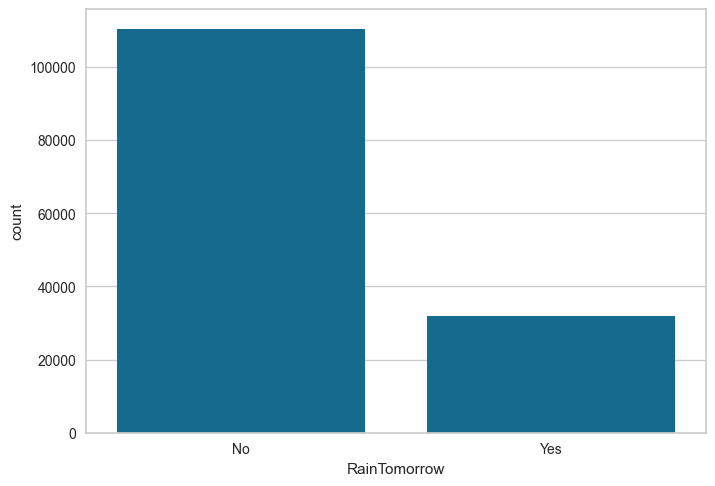

In [12]:
sns.countplot(x="RainTomorrow", data=df)

Existe desbalanceo moderado entre clases, Se pregunta por ello para que tengamos en cuenta que métricas utilizar a la hora de calificar el modelo. Por ejemplo, si nuestro modelo fuera simplemente "RainTomorrow = 0", este en cada ejecucíon indicaría que no llueve, y así tendría una Accuracy del 77.57% a pesar de no ser una resolución funciona, al saber que la variable target está desbalanceada debemos aplicar otras métricas evaluar el rendimiento.

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
def faltantes(data: pd.DataFrame) -> pd.DataFrame:
    faltantes = data.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    return porcentaje
faltantes(df)

Location             0.000000
MinTemp              1.020549
MaxTemp              0.861690
Rainfall             2.241906
Evaporation         43.155998
Sunshine            47.998790
WindGustDir          7.094325
WindGustSpeed        7.051000
WindDir9am           7.263500
WindDir3pm           2.906225
WindSpeed9am         1.215168
WindSpeed3pm         2.105053
Humidity9am          1.824471
Humidity3pm          3.098094
Pressure9am         10.357467
Pressure3pm         10.332022
Cloud9am            38.421863
Cloud3pm            40.805436
Temp9am              1.214480
Temp3pm              2.480538
RainToday            2.241906
RainTomorrow         2.241218
RainfallTomorrow     2.241218
Year                 0.000000
Month                0.000000
Day                  0.000000
dtype: float64

se observa una perdida de casi la mitad de los datos en las variables Cloud, Sunshine y Evaporación. Se procede a borrar el 2% de entries de RainTomorrow, ya que imputarlos introduciría error al modelo.

In [15]:
df = df.dropna(subset=["RainTomorrow"])
faltantes(df)

Location             0.000000
MinTemp              0.448109
MaxTemp              0.226516
Rainfall             0.989075
Evaporation         42.779259
Sunshine            47.684537
WindGustDir          6.561944
WindGustSpeed        6.519736
WindDir9am           7.041005
WindDir3pm           2.656293
WindSpeed9am         0.948274
WindSpeed3pm         1.849416
Humidity9am          1.247951
Humidity3pm          2.538814
Pressure9am          9.855578
Pressure3pm          9.832364
Cloud9am            37.734694
Cloud3pm            40.151105
Temp9am              0.635935
Temp3pm              1.916949
RainToday            0.989075
RainTomorrow         0.000000
RainfallTomorrow     0.000000
Year                 0.000000
Month                0.000000
Day                  0.000000
dtype: float64

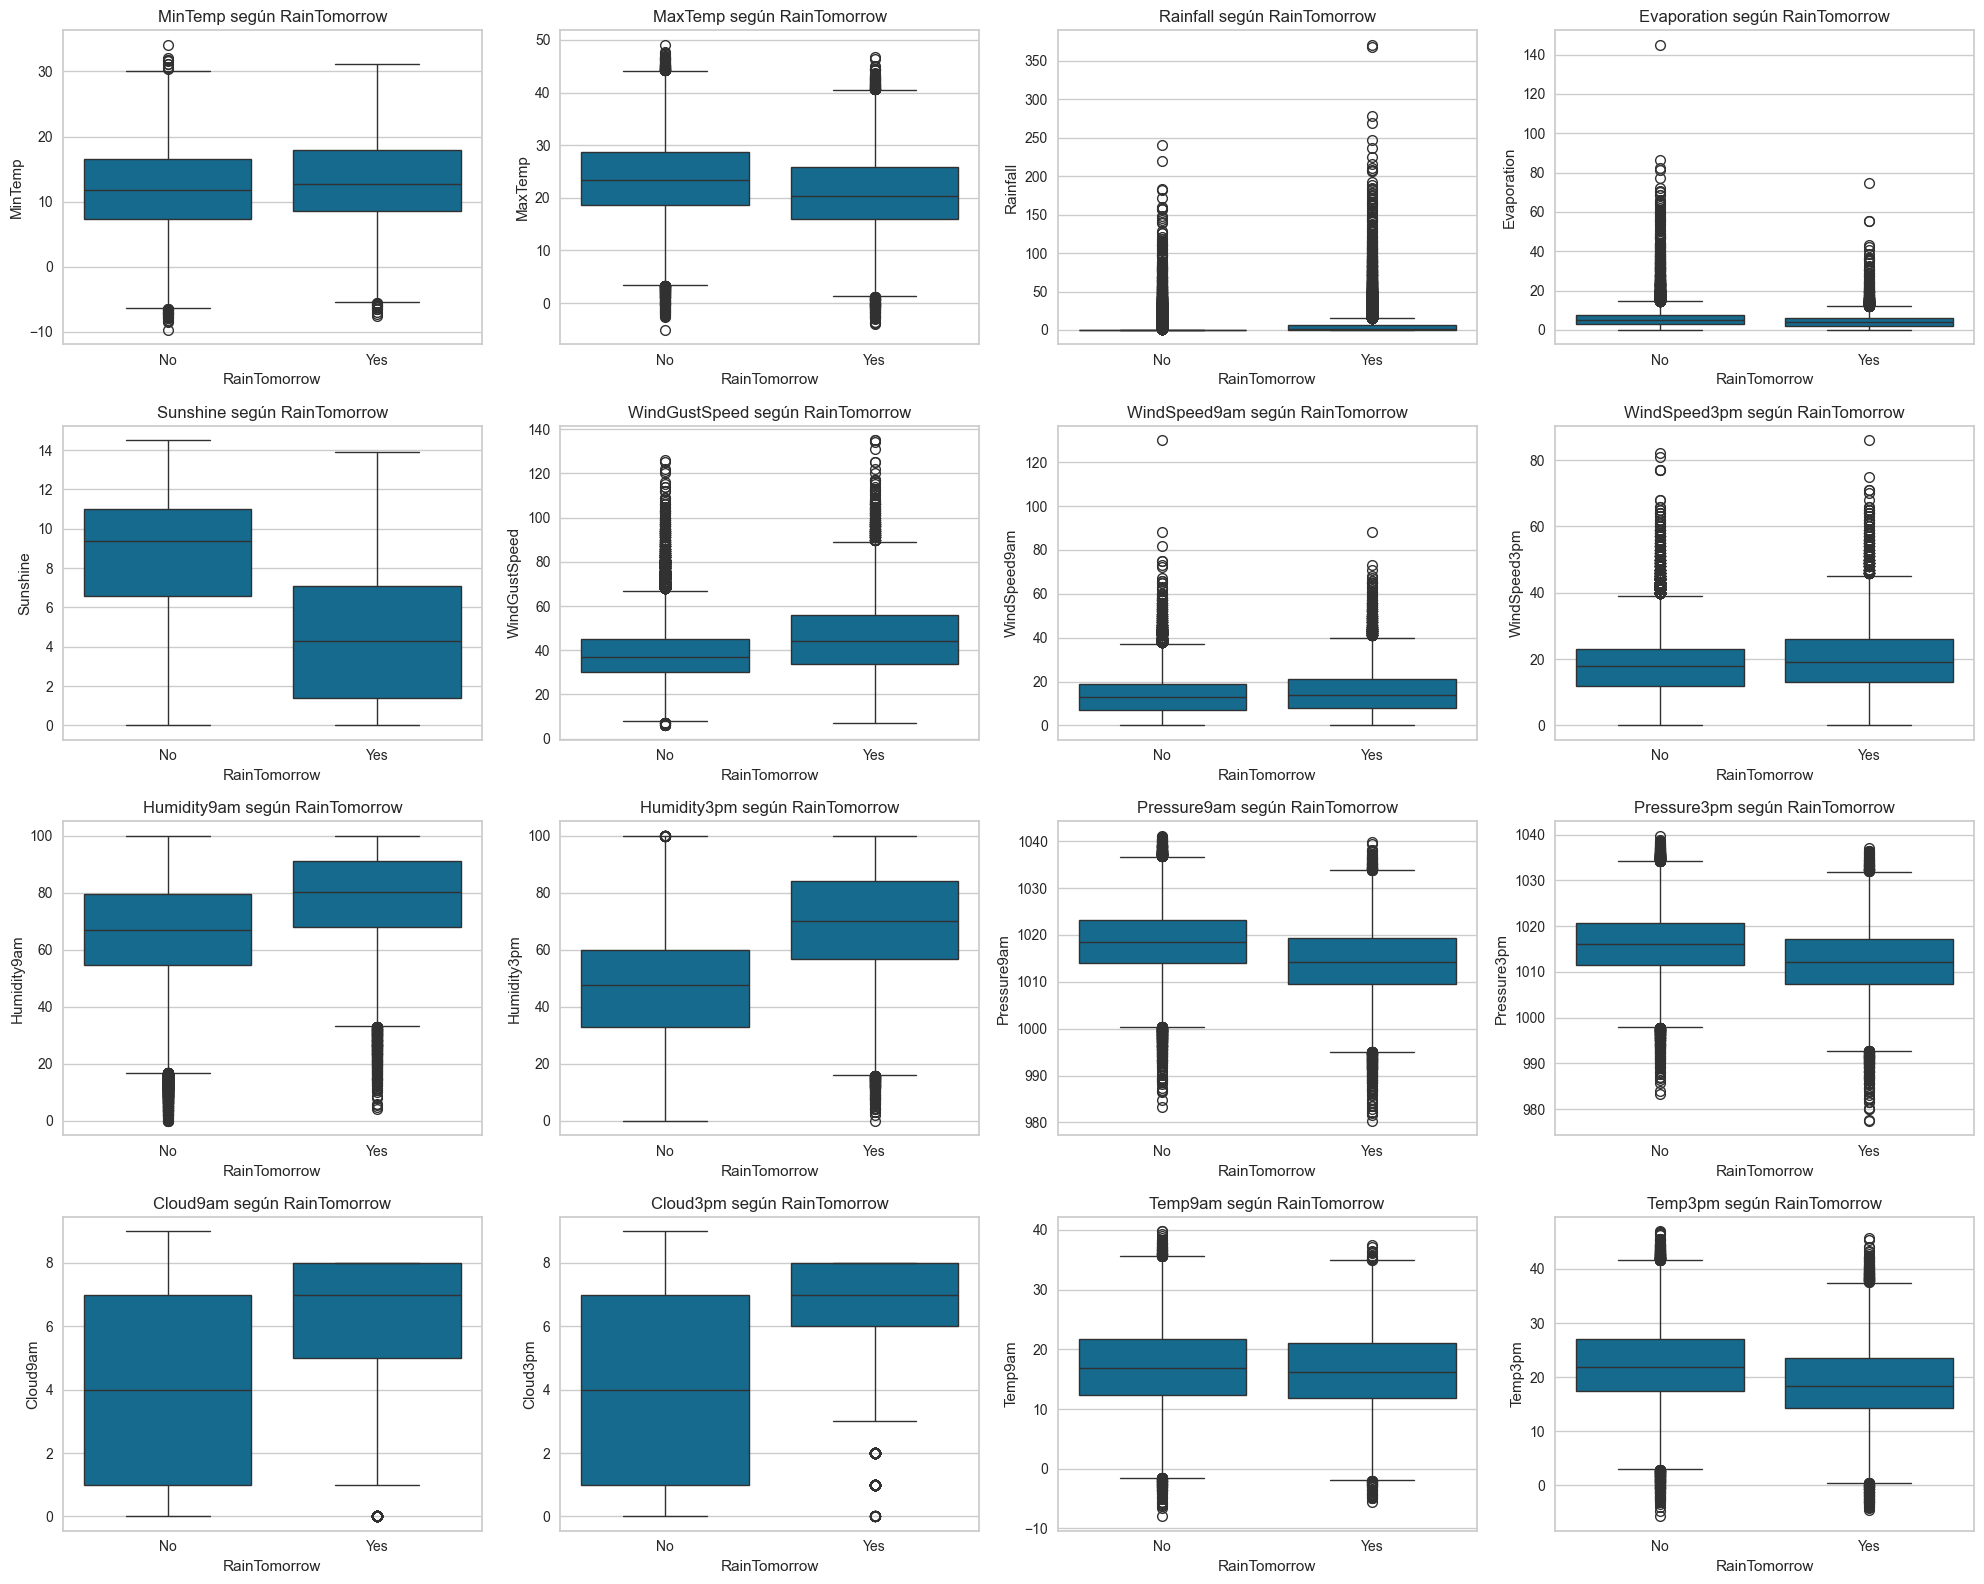

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Variables numéricas a comparar contra RainTomorrow
num_cols = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Evaporation",
    "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Cloud9am",
    "Cloud3pm",
    "Temp9am",
    "Temp3pm"]

num_cols = [col for col in num_cols if col in df.columns]

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        data=df,
        x="RainTomorrow",
        y=col
    )
    plt.title(f"{col} según RainTomorrow")
    plt.xlabel("RainTomorrow")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Los boxplots muestran diferencias claras entre los días en los que llueve al día siguiente (`RainTomorrow = Yes`) y aquellos en los que no. Los días previos a lluvia presentan mayor `Humidity3pm`, `Humidity9am`, `Cloud9am`, `Cloud3pm`, `WindGustSpeed` y `Rainfall`, mientras que muestran menor `Sunshine`, `Pressure9am`, `Pressure3pm`, `MaxTemp` y `Temp3pm`.

In [17]:
cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
        'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
        'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am',
        'Temp3pm']

def resumen_distribuciones(df):

    resumen = {}

    for col in cols:

        serie = df[col].dropna()

        Q1 = serie.quantile(0.25)
        Q3 = serie.quantile(0.75)

        resumen[col] = {
            "mean": serie.mean(),
            "median": serie.median(),
            "std": serie.std(),
            "var": serie.var(),
            "min": serie.min(),
            "max": serie.max(),
            "IQR": Q3 - Q1,
            "skew": serie.skew(),
            "kurtosis": serie.kurtosis(),
            "missing_pct": df[col].isnull().mean() * 100
        }

    resumen_df = pd.DataFrame(resumen).T

    return resumen_df   

In [18]:
distribuciones_previo = resumen_distribuciones(df)
distribuciones_previo


,mean,median,std,var,min,max,IQR,skew,kurtosis,missing_pct
MinTemp,12.188866,12.0,6.422856,41.253084,-9.7,34.1,9.2,0.022221,-0.481609,0.448109
MaxTemp,23.228596,22.6,7.134436,50.900172,-5.1,49.1,10.3,0.222679,-0.235140,0.226516
Rainfall,2.350461,0.0,8.466267,71.677678,0.0,371.0,0.8,9.886866,179.957216,0.989075
Evaporation,5.470149,4.8,4.188649,17.544780,0.0,145.0,4.8,3.746758,45.066745,42.779259
Sunshine,7.624919,8.5,3.781656,14.300920,0.0,14.5,5.7,-0.502936,-0.820411,47.684537
WindGustSpeed,39.985807,38.0,13.630314,185.785461,6.0,135.0,17.0,0.866666,1.401362,6.519736
WindSpeed9am,14.025219,13.0,8.914326,79.465210,0.0,130.0,12.0,0.785296,1.220041,0.948274
WindSpeed3pm,18.636901,18.0,8.858849,78.479205,0.0,86.0,12.0,0.619921,0.741008,1.849416
Humidity9am,68.824619,69.9,19.085026,364.238205,0.0,100.0,26.2,-0.484886,-0.044226,1.247951
Humidity3pm,51.475886,51.9,20.846540,434.578228,0.0,100.0,29.1,0.032263,-0.509691,2.538814


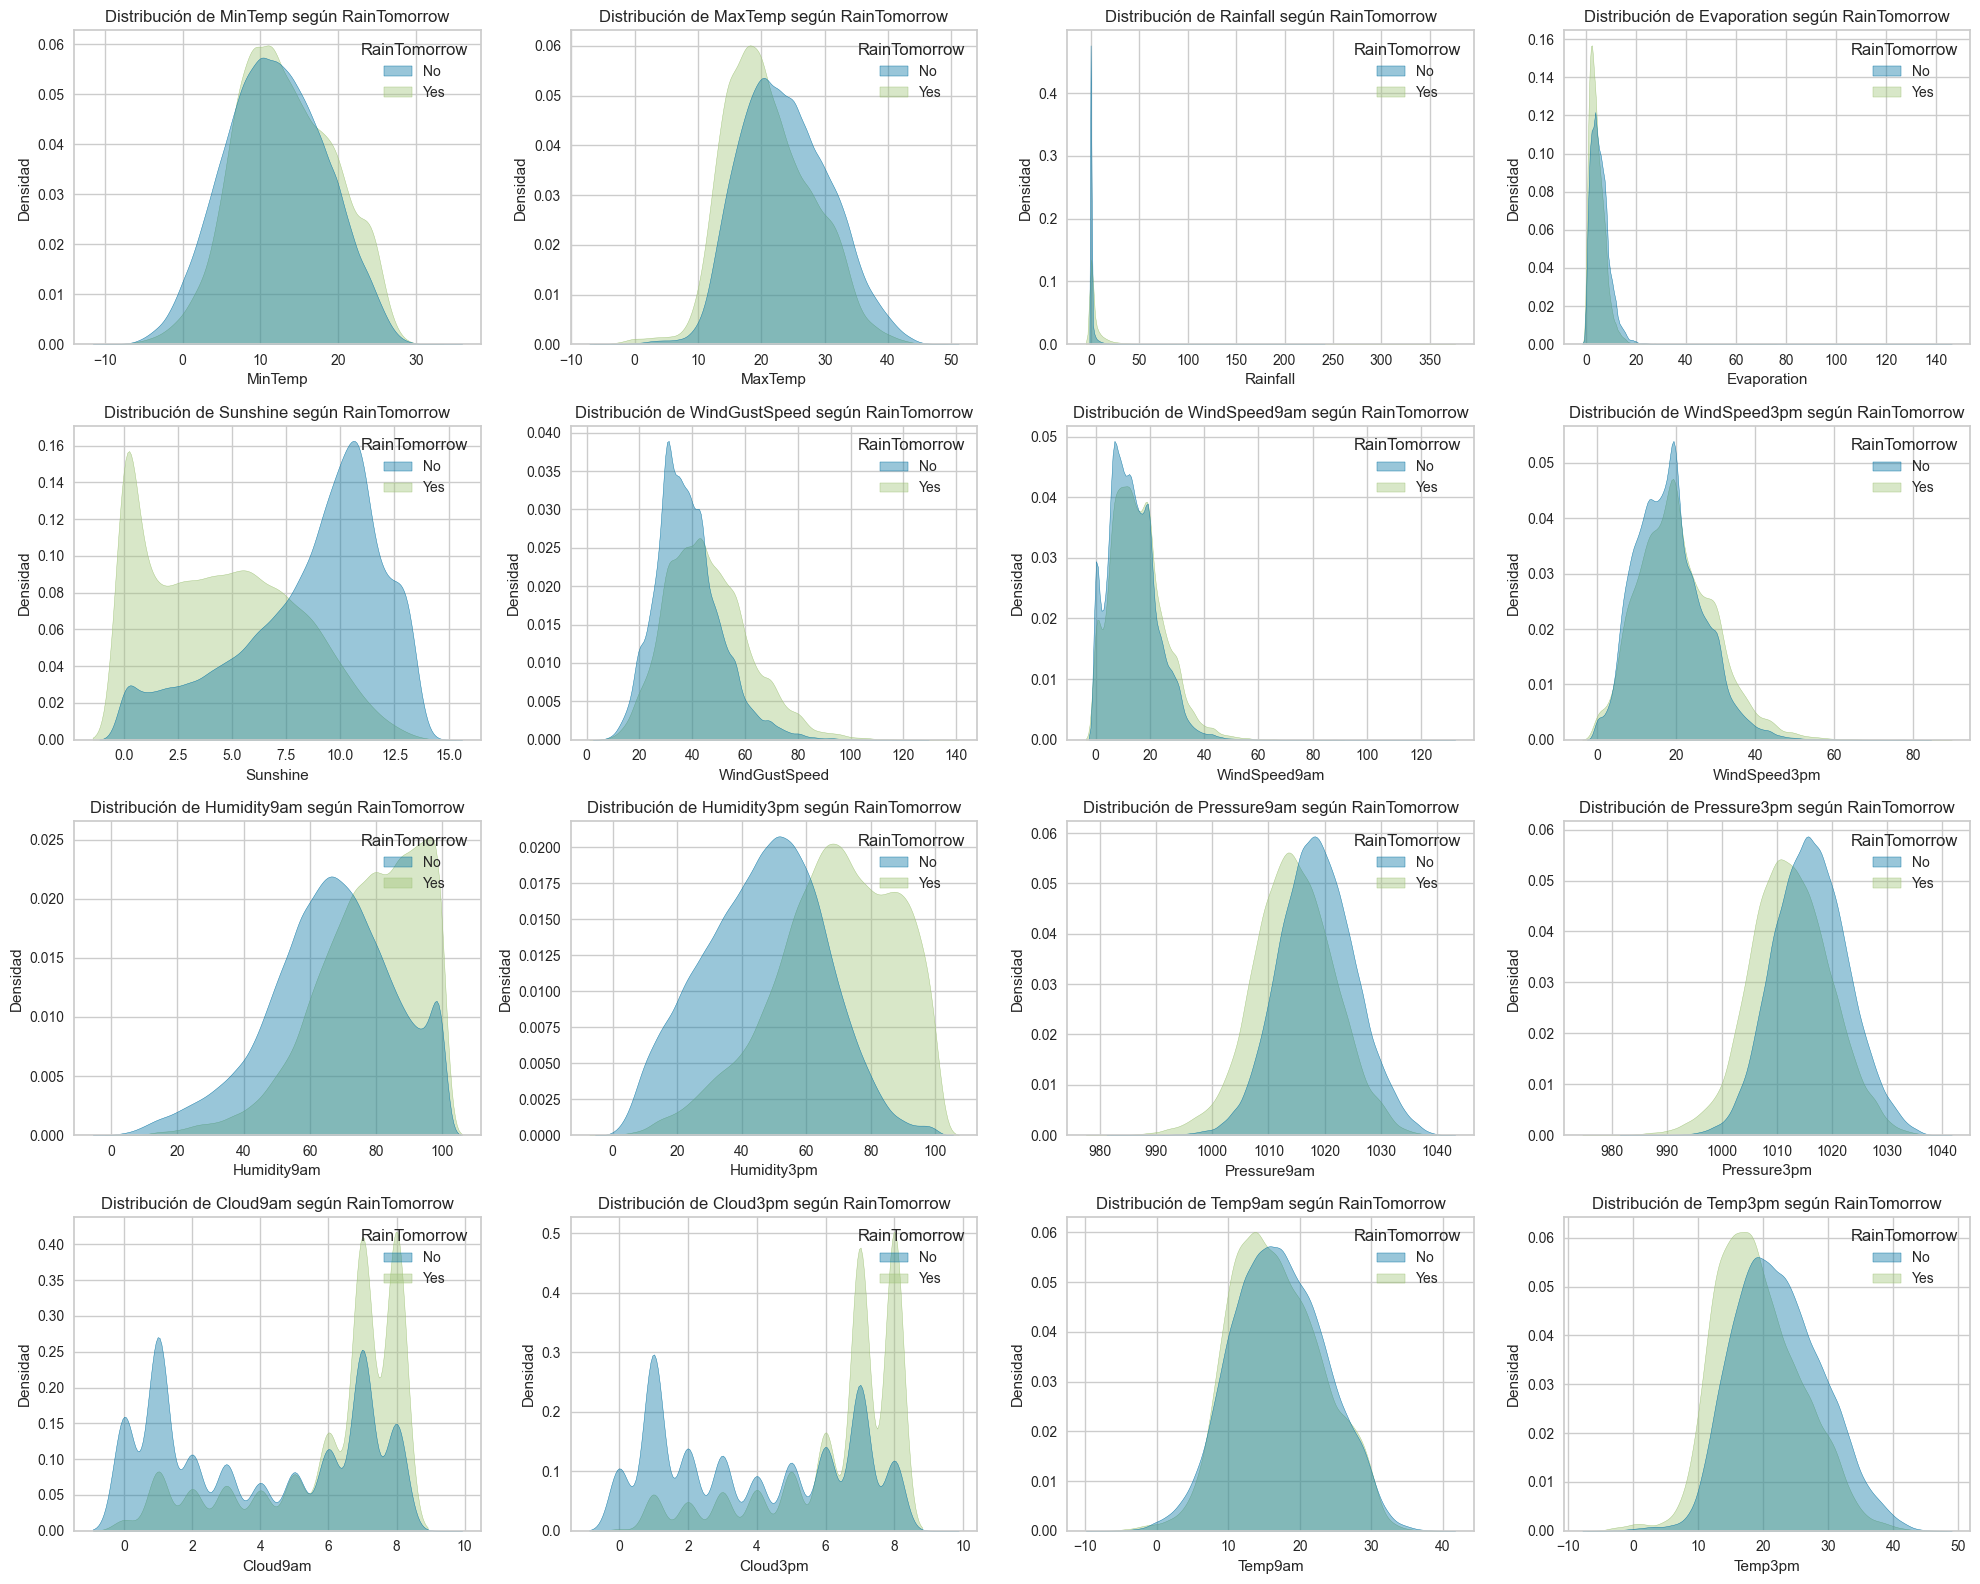

In [19]:
plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(
        data=df,
        x=col,
        hue="RainTomorrow",
        fill=True,
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Distribución de {col} según RainTomorrow")
    plt.xlabel(col)
    plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

Las distribuciones por clase refuerzan lo observado en los boxplots: los días con `RainTomorrow = Yes` tienden a concentrarse en condiciones de mayor humedad, mayor nubosidad y mayor intensidad de viento. Las diferencias más marcadas aparecen en `Humidity3pm`, `Humidity9am`, `Cloud9am`, `Cloud3pm`, `Sunshine`, `Pressure9am` y `Pressure3pm`. En particular, los días previos a lluvia muestran valores más altos de humedad y nubosidad, menor cantidad de horas de sol y presiones atmosféricas más bajas. También se observa que `WindGustSpeed` presenta una distribución desplazada hacia valores mayores cuando al día siguiente llueve, lo que sugiere que ráfagas más intensas pueden estar asociadas a cambios meteorológicos previos a precipitaciones. En cambio, variables como `MinTemp`, `Temp9am` y `Evaporation` presentan mayor superposición entre clases, por lo que individualmente parecen tener menor poder discriminante.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

#Armamos una función que analice los nan de una columna

def Analizar_Var(df: pd.DataFrame ,col: str):

    print(f"ANÁLISIS DE NaN -> {col}")

    nan_pct = df[col].isnull().mean() * 100

    print(f"\n% faltantes total: {nan_pct:.2f}%")

    #Cálculo de los faltantes por ubicación y mes

    nan_flag = f"{col}_nan"

    df[nan_flag] = df[col].isnull()

    print("\n% NaN por Lugar:")

    display(
        (
            df.groupby("Location")[col]
            .apply(lambda x: x.isnull().mean() * 100)
            .sort_values(ascending=False)
            .to_frame("% NaN")
        )
    )


    print("\n% NaN por mes:")

    display(
        (
            df.groupby("Month")[col]
            .apply(lambda x: x.isnull().mean() * 100)
            .sort_values(ascending=False)
            .to_frame("% NaN")
        )
    )


    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x="RainTomorrow",
        hue=nan_flag
    )

    plt.title(f"NaN de {col} según RainTomorrow")

    plt.show()

ANÁLISIS DE NaN -> Evaporation

% faltantes total: 42.78%

% NaN por Lugar:


,% NaN
Location,
Newcastle,100.000000
MountGinini,100.000000
NorahHead,100.000000
PearceRAAF,100.000000
GoldCoast,100.000000
Penrith,100.000000
SalmonGums,100.000000
Tuggeranong,100.000000
Uluru,100.000000



% NaN por mes:


,% NaN
Month,
6,44.311280
5,44.113367
4,43.499027
1,43.402213
12,43.395005
2,43.087886
3,42.712488
10,42.316164
11,42.273798


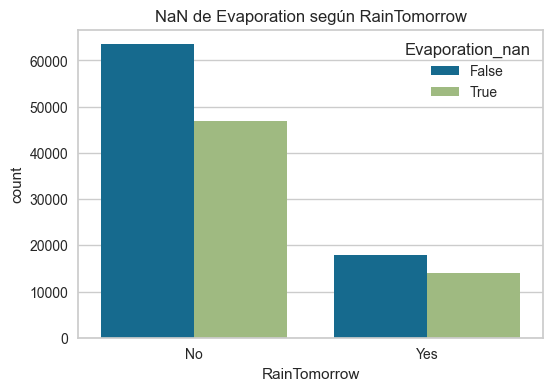

In [21]:
Analizar_Var(df,"Evaporation")

ANÁLISIS DE NaN -> Cloud9am

% faltantes total: 37.73%

% NaN por Lugar:


,% NaN
Location,
Adelaide,100.000000
Dartmoor,100.000000
NorahHead,100.000000
Nhil,100.000000
MountGinini,100.000000
SalmonGums,100.000000
Tuggeranong,100.000000
Walpole,100.000000
GoldCoast,100.000000



% NaN por mes:


,% NaN
Month,
12,39.232192
1,39.029487
10,38.622501
5,38.284182
4,38.209800
3,38.071494
11,38.024605
2,38.014252
9,37.091230


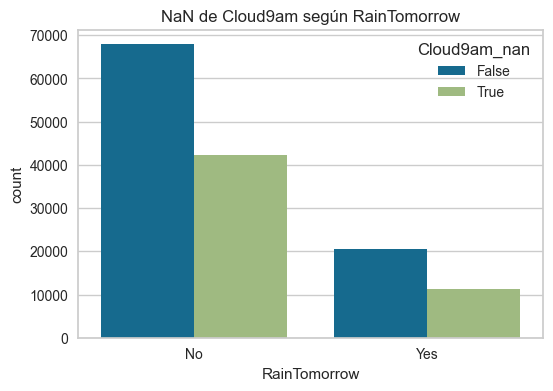

In [22]:
Analizar_Var(df,"Cloud9am")

ANÁLISIS DE NaN -> Cloud3pm

% faltantes total: 40.15%

% NaN por Lugar:


,% NaN
Location,
Adelaide,100.000000
Tuggeranong,100.000000
NorahHead,100.000000
Penrith,100.000000
GoldCoast,100.000000
Dartmoor,100.000000
MountGinini,100.000000
SalmonGums,100.000000
Walpole,100.000000



% NaN por mes:


,% NaN
Month,
1,42.179398
12,42.118409
2,41.292162
11,41.270395
10,41.070823
5,40.773650
3,40.349801
4,40.084911
6,39.233946


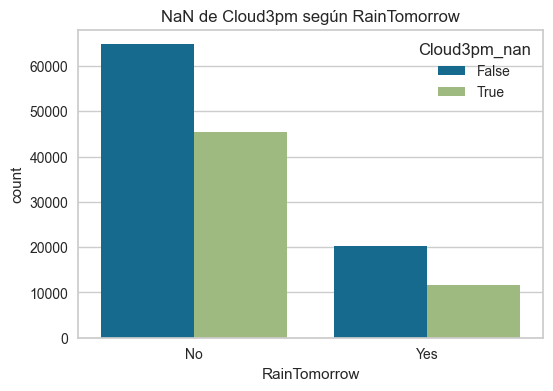

In [23]:
Analizar_Var(df,"Cloud3pm")

ANÁLISIS DE NaN -> Sunshine

% faltantes total: 47.68%

% NaN por Lugar:


,% NaN
Location,
Newcastle,100.000000
Walpole,100.000000
NorahHead,100.000000
Penrith,100.000000
Richmond,100.000000
SalmonGums,100.000000
Launceston,100.000000
Katherine,100.000000
Tuggeranong,100.000000



% NaN por mes:


,% NaN
Month,
5,50.072769
6,49.283343
12,48.390379
4,48.337166
8,47.287876
10,47.280583
1,47.117096
11,47.011605
2,47.002375


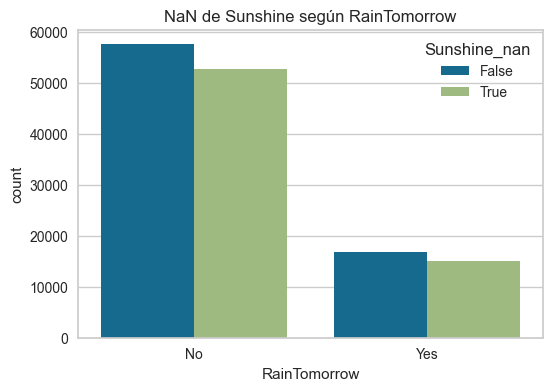

In [24]:
Analizar_Var(df,"Sunshine")

Se observa que algunas ciudades presentan una gran cantidad de valores faltantes en determinadas variables. Esto podría deberse a que ciertos observatorios no cuentan con los sensores necesarios para registrar esas mediciones. Por este motivo, se decidió imputar teniendo en cuenta que cuando los valores faltantes son esporádicos se imputen utilizando como referencia los datos disponibles del mismo lugar y del mismo mes, en cambio, cuando una variable no fue registrada de forma sistemática en una ciudad, se estima su valor a partir del promedio de observatorios cercanos. De esta manera, se busca conservar la mayor cantidad posible de información sin ignorar el contexto geográfico y estacional de los datos.

In [25]:
geolocator = Nominatim(user_agent="weatherAUS_imputation")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

coords = []

lugares = df["Location"].unique().tolist()

for loc in lugares:
    query = loc
    query = query.replace("Airport", " Airport")
    query = re.sub(r'(?<!^)(?=[A-Z])', ' ', loc)
    query = query.replace(" R A A F", " RAAF")
    

    place = geocode(f"{query}, Australia")

    coords.append({
        "Location": loc,
        "Latitude": place.latitude if place else np.nan,
        "Longitude": place.longitude if place else np.nan
    })

lugares_coords = pd.DataFrame(coords)

lugares_coords

,Location,Latitude,Longitude
0,Albury,-36.073773,146.913526
1,BadgerysCreek,-33.883145,150.742466
2,Cobar,-31.966663,145.304505
3,CoffsHarbour,-30.298600,153.109412
4,Moree,-29.461720,149.840715
5,Newcastle,-32.919295,151.779535
6,NorahHead,-33.281667,151.567778
7,NorfolkIsland,-29.032804,167.948314
8,Penrith,-33.751195,150.694171
9,Richmond,-37.807450,144.990721


In [26]:
coords_rad = np.radians(
    lugares_coords[["Latitude", "Longitude"]]
)

nn = NearestNeighbors(
    n_neighbors=6,
    metric="haversine"
)

nn.fit(coords_rad)

distances, indices = nn.kneighbors(coords_rad)

vecinos_dict = {}

for i, loc in enumerate(lugares_coords["Location"]):
    vecinos = lugares_coords.iloc[indices[i]]["Location"].tolist()
    vecinos = [v for v in vecinos if v != loc]
    vecinos_dict[loc] = vecinos

vecinos_dict

{'Albury': ['WaggaWagga', 'MountGinini', 'Tuggeranong', 'Canberra', 'Sale'],
 'BadgerysCreek': ['Penrith',
  'SydneyAirport',
  'Sydney',
  'Wollongong',
  'NorahHead'],
 'Cobar': ['Mildura', 'WaggaWagga', 'Albury', 'MountGinini', 'Canberra'],
 'CoffsHarbour': ['GoldCoast',
  'Williamtown',
  'Brisbane',
  'Newcastle',
  'Moree'],
 'Moree': ['CoffsHarbour',
  'Brisbane',
  'GoldCoast',
  'Williamtown',
  'Newcastle'],
 'Newcastle': ['Williamtown',
  'NorahHead',
  'Sydney',
  'SydneyAirport',
  'Penrith'],
 'NorahHead': ['Newcastle',
  'Williamtown',
  'Sydney',
  'SydneyAirport',
  'Penrith'],
 'NorfolkIsland': ['GoldCoast',
  'CoffsHarbour',
  'Brisbane',
  'Williamtown',
  'Newcastle'],
 'Penrith': ['BadgerysCreek',
  'Sydney',
  'SydneyAirport',
  'Wollongong',
  'NorahHead'],
 'Richmond': ['Melbourne',
  'Watsonia',
  'MelbourneAirport',
  'Ballarat',
  'Bendigo'],
 'Sydney': ['SydneyAirport',
  'BadgerysCreek',
  'Penrith',
  'Wollongong',
  'NorahHead'],
 'SydneyAirport': ['Sydn

In [27]:
def imputar_por_vecinos_geograficos(df, col, neighbors_dict):
    df = df.copy()

    # Promedio por mes y mismo lugar
    df[col] = df[col].fillna(
        df.groupby(["Location", "Month"])[col].transform("median")
    )

    # Promedio por mes y vecinos
    for loc, vecinos in neighbors_dict.items():

        for month in df.loc[
            (df["Location"] == loc) & (df[col].isnull()),
            "Month"
        ].unique():

            mask = (
                (df["Location"] == loc) &
                (df["Month"] == month) &
                (df[col].isnull())
            )

            valores_vecinos = df[
                (df["Location"].isin(vecinos)) &
                (df["Month"] == month)
            ][col].dropna()

            if len(valores_vecinos) > 0:
                df.loc[mask, col] = valores_vecinos.median()

    return df

In [28]:
def imputar_categoricas_por_vecinos_geograficos(
    df,
    col,
    neighbors_dict
):
    df = df.copy()

    def obtener_moda(serie):

        serie = serie.dropna()

        if len(serie) == 0:
            return np.nan

        moda = serie.mode()

        if len(moda) == 0:
            return np.nan

        return moda.iloc[0]

    #Promedio por mes y mismo lugar

    valores_grupo = (
        df.groupby(["Location", "Month"])[col]
        .transform(obtener_moda)
    )

    df[col] = df[col].fillna(valores_grupo)

    # Promedio por mes y vecinos

    for loc, vecinos in neighbors_dict.items():

        meses_faltantes = df.loc[
            (df["Location"] == loc) &
            (df[col].isnull()),
            "Month"
        ].unique()

        for month in meses_faltantes:

            mask = (
                (df["Location"] == loc) &
                (df["Month"] == month) &
                (df[col].isnull())
            )

            valores_vecinos = df[
                (df["Location"].isin(vecinos)) &
                (df["Month"] == month)
            ][col]

            moda_vecinos = obtener_moda(valores_vecinos)

            if not pd.isna(moda_vecinos):
                df.loc[mask, col] = moda_vecinos

    return df

Funciones auxiliares para imputar vecinos de variables tanto categóricas y numéricas con criterio de comparar datos en el mismo mes

In [29]:
cols_numericas = [
        'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
        'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
        'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
        'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

for col in cols_numericas:
    df = imputar_por_vecinos_geograficos(
        df,
        col,
        vecinos_dict
    )
    
cols_categoricas = [
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "RainToday"
]

for col in cols_categoricas:

    df = imputar_categoricas_por_vecinos_geograficos(
        df,
        col,
        vecinos_dict
    )

faltantes(df)

Location            0.0
MinTemp             0.0
MaxTemp             0.0
Rainfall            0.0
Evaporation         0.0
Sunshine            0.0
WindGustDir         0.0
WindGustSpeed       0.0
WindDir9am          0.0
WindDir3pm          0.0
WindSpeed9am        0.0
WindSpeed3pm        0.0
Humidity9am         0.0
Humidity3pm         0.0
Pressure9am         0.0
Pressure3pm         0.0
Cloud9am            0.0
Cloud3pm            0.0
Temp9am             0.0
Temp3pm             0.0
RainToday           0.0
RainTomorrow        0.0
RainfallTomorrow    0.0
Year                0.0
Month               0.0
Day                 0.0
Evaporation_nan     0.0
Cloud9am_nan        0.0
Cloud3pm_nan        0.0
Sunshine_nan        0.0
dtype: float64

In [30]:
distribuciones_post = resumen_distribuciones(df)
distribuciones_post

,mean,median,std,var,min,max,IQR,skew,kurtosis,missing_pct
MinTemp,12.191591,12.0,6.420897,41.227919,-9.7,34.1,9.2,0.021019,-0.480639,0.0
MaxTemp,23.229223,22.6,7.131740,50.861715,-5.1,49.1,10.3,0.222769,-0.233954,0.0
Rainfall,2.327810,0.0,8.427368,71.020525,0.0,371.0,0.6,9.933117,181.622180,0.0
Evaporation,5.161116,4.6,3.540328,12.533922,0.0,145.0,4.4,3.750076,52.388743,0.0
Sunshine,7.956474,8.4,3.065199,9.395448,0.0,14.5,3.9,-0.703797,0.126794,0.0
WindGustSpeed,39.923790,38.0,13.215843,174.658500,6.0,135.0,16.0,0.901432,1.673499,0.0
WindSpeed9am,14.001745,13.0,8.891199,79.053412,0.0,130.0,12.0,0.788128,1.236964,0.0
WindSpeed3pm,18.563565,18.0,8.838095,78.111930,0.0,86.0,12.0,0.621971,0.750676,0.0
Humidity9am,68.935447,70.0,19.065762,363.503266,0.0,100.0,26.2,-0.490890,-0.040904,0.0
Humidity3pm,51.545627,52.1,20.746585,430.420791,0.0,100.0,28.9,0.020088,-0.500871,0.0


In [31]:
diferencia = distribuciones_post - distribuciones_previo

diferencia

,mean,median,std,var,min,max,IQR,skew,kurtosis,missing_pct
MinTemp,0.002725,0.0,-0.001959,-0.025165,0.0,0.0,0.000000e+00,-0.001201,0.000970,-0.448109
MaxTemp,0.000627,0.0,-0.002696,-0.038457,0.0,0.0,0.000000e+00,0.000090,0.001186,-0.226516
Rainfall,-0.022651,0.0,-0.038899,-0.657153,0.0,0.0,-2.000000e-01,0.046252,1.664963,-0.989075
Evaporation,-0.309033,-0.2,-0.648321,-5.010858,0.0,0.0,-4.000000e-01,0.003318,7.321999,-42.779259
Sunshine,0.331555,-0.1,-0.716456,-4.905472,0.0,0.0,-1.800000e+00,-0.200861,0.947205,-47.684537
WindGustSpeed,-0.062017,0.0,-0.414471,-11.126961,0.0,0.0,-1.000000e+00,0.034766,0.272138,-6.519736
WindSpeed9am,-0.023475,0.0,-0.023128,-0.411799,0.0,0.0,0.000000e+00,0.002832,0.016923,-0.948274
WindSpeed3pm,-0.073336,0.0,-0.020754,-0.367274,0.0,0.0,0.000000e+00,0.002050,0.009668,-1.849416
Humidity9am,0.110828,0.1,-0.019264,-0.734939,0.0,0.0,7.105427e-15,-0.006005,0.003321,-1.247951
Humidity3pm,0.069741,0.2,-0.099955,-4.157438,0.0,0.0,-2.000000e-01,-0.012176,0.008820,-2.538814


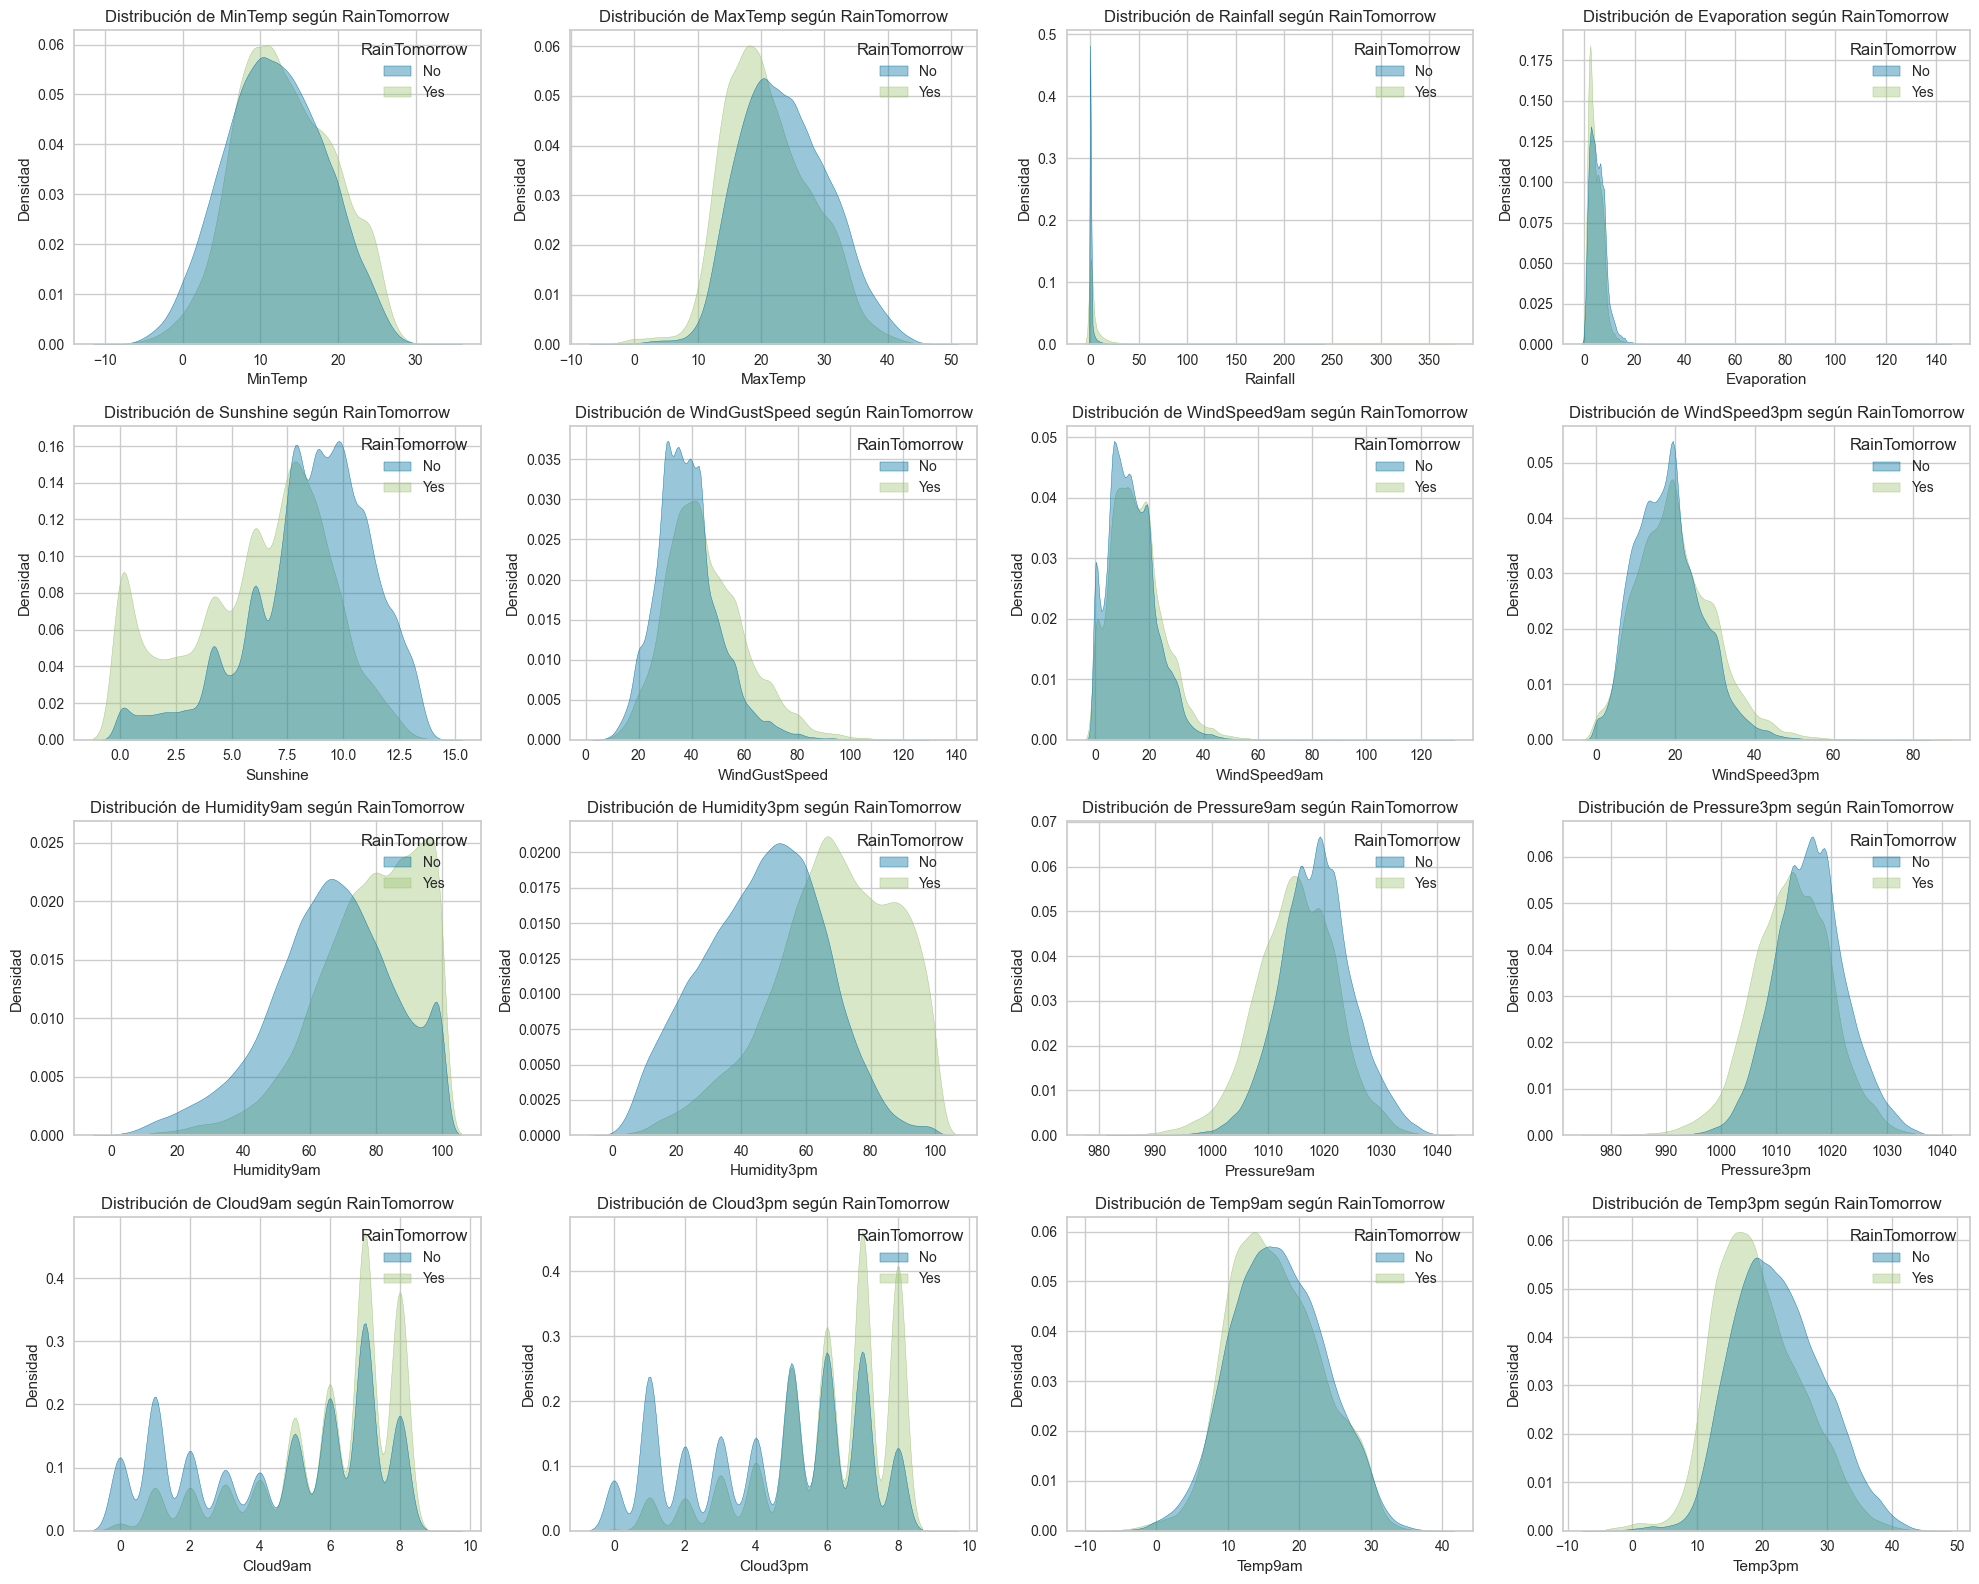

In [32]:
plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(
        data=df,
        x=col,
        hue="RainTomorrow",
        fill=True,
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Distribución de {col} según RainTomorrow")
    plt.xlabel(col)
    plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

Al mirar las gráficas de distribución de datos de las variables, podemos notar que estas no cambiaron mucho luego de la imputación de datos, así que se considera que no se introdujo ruido en los datos, excepto por Evaporation, dónde varió mucho la Kurtosis (explicación de la métrica). 
En primer lugar, al mirar los boxplots se logra apreciar que no es muy explicativa de la variable Target, sumado a eso que sólo se tenían un 67% de los datos y que al imputarlos, el método elegido añadió bastante ruido se toma la decisión de eliminar la variable por miedo a introducir ruido innecesario al modelo.

In [33]:
# Se asigna un valor binario a las variables "yes/no"
df["RainToday"] = (
    df["RainToday"]
    .map({"No": 0, "Yes": 1})
)

df["RainTomorrow"] = (
    df["RainTomorrow"]
    .map({"No": 0, "Yes": 1})
)

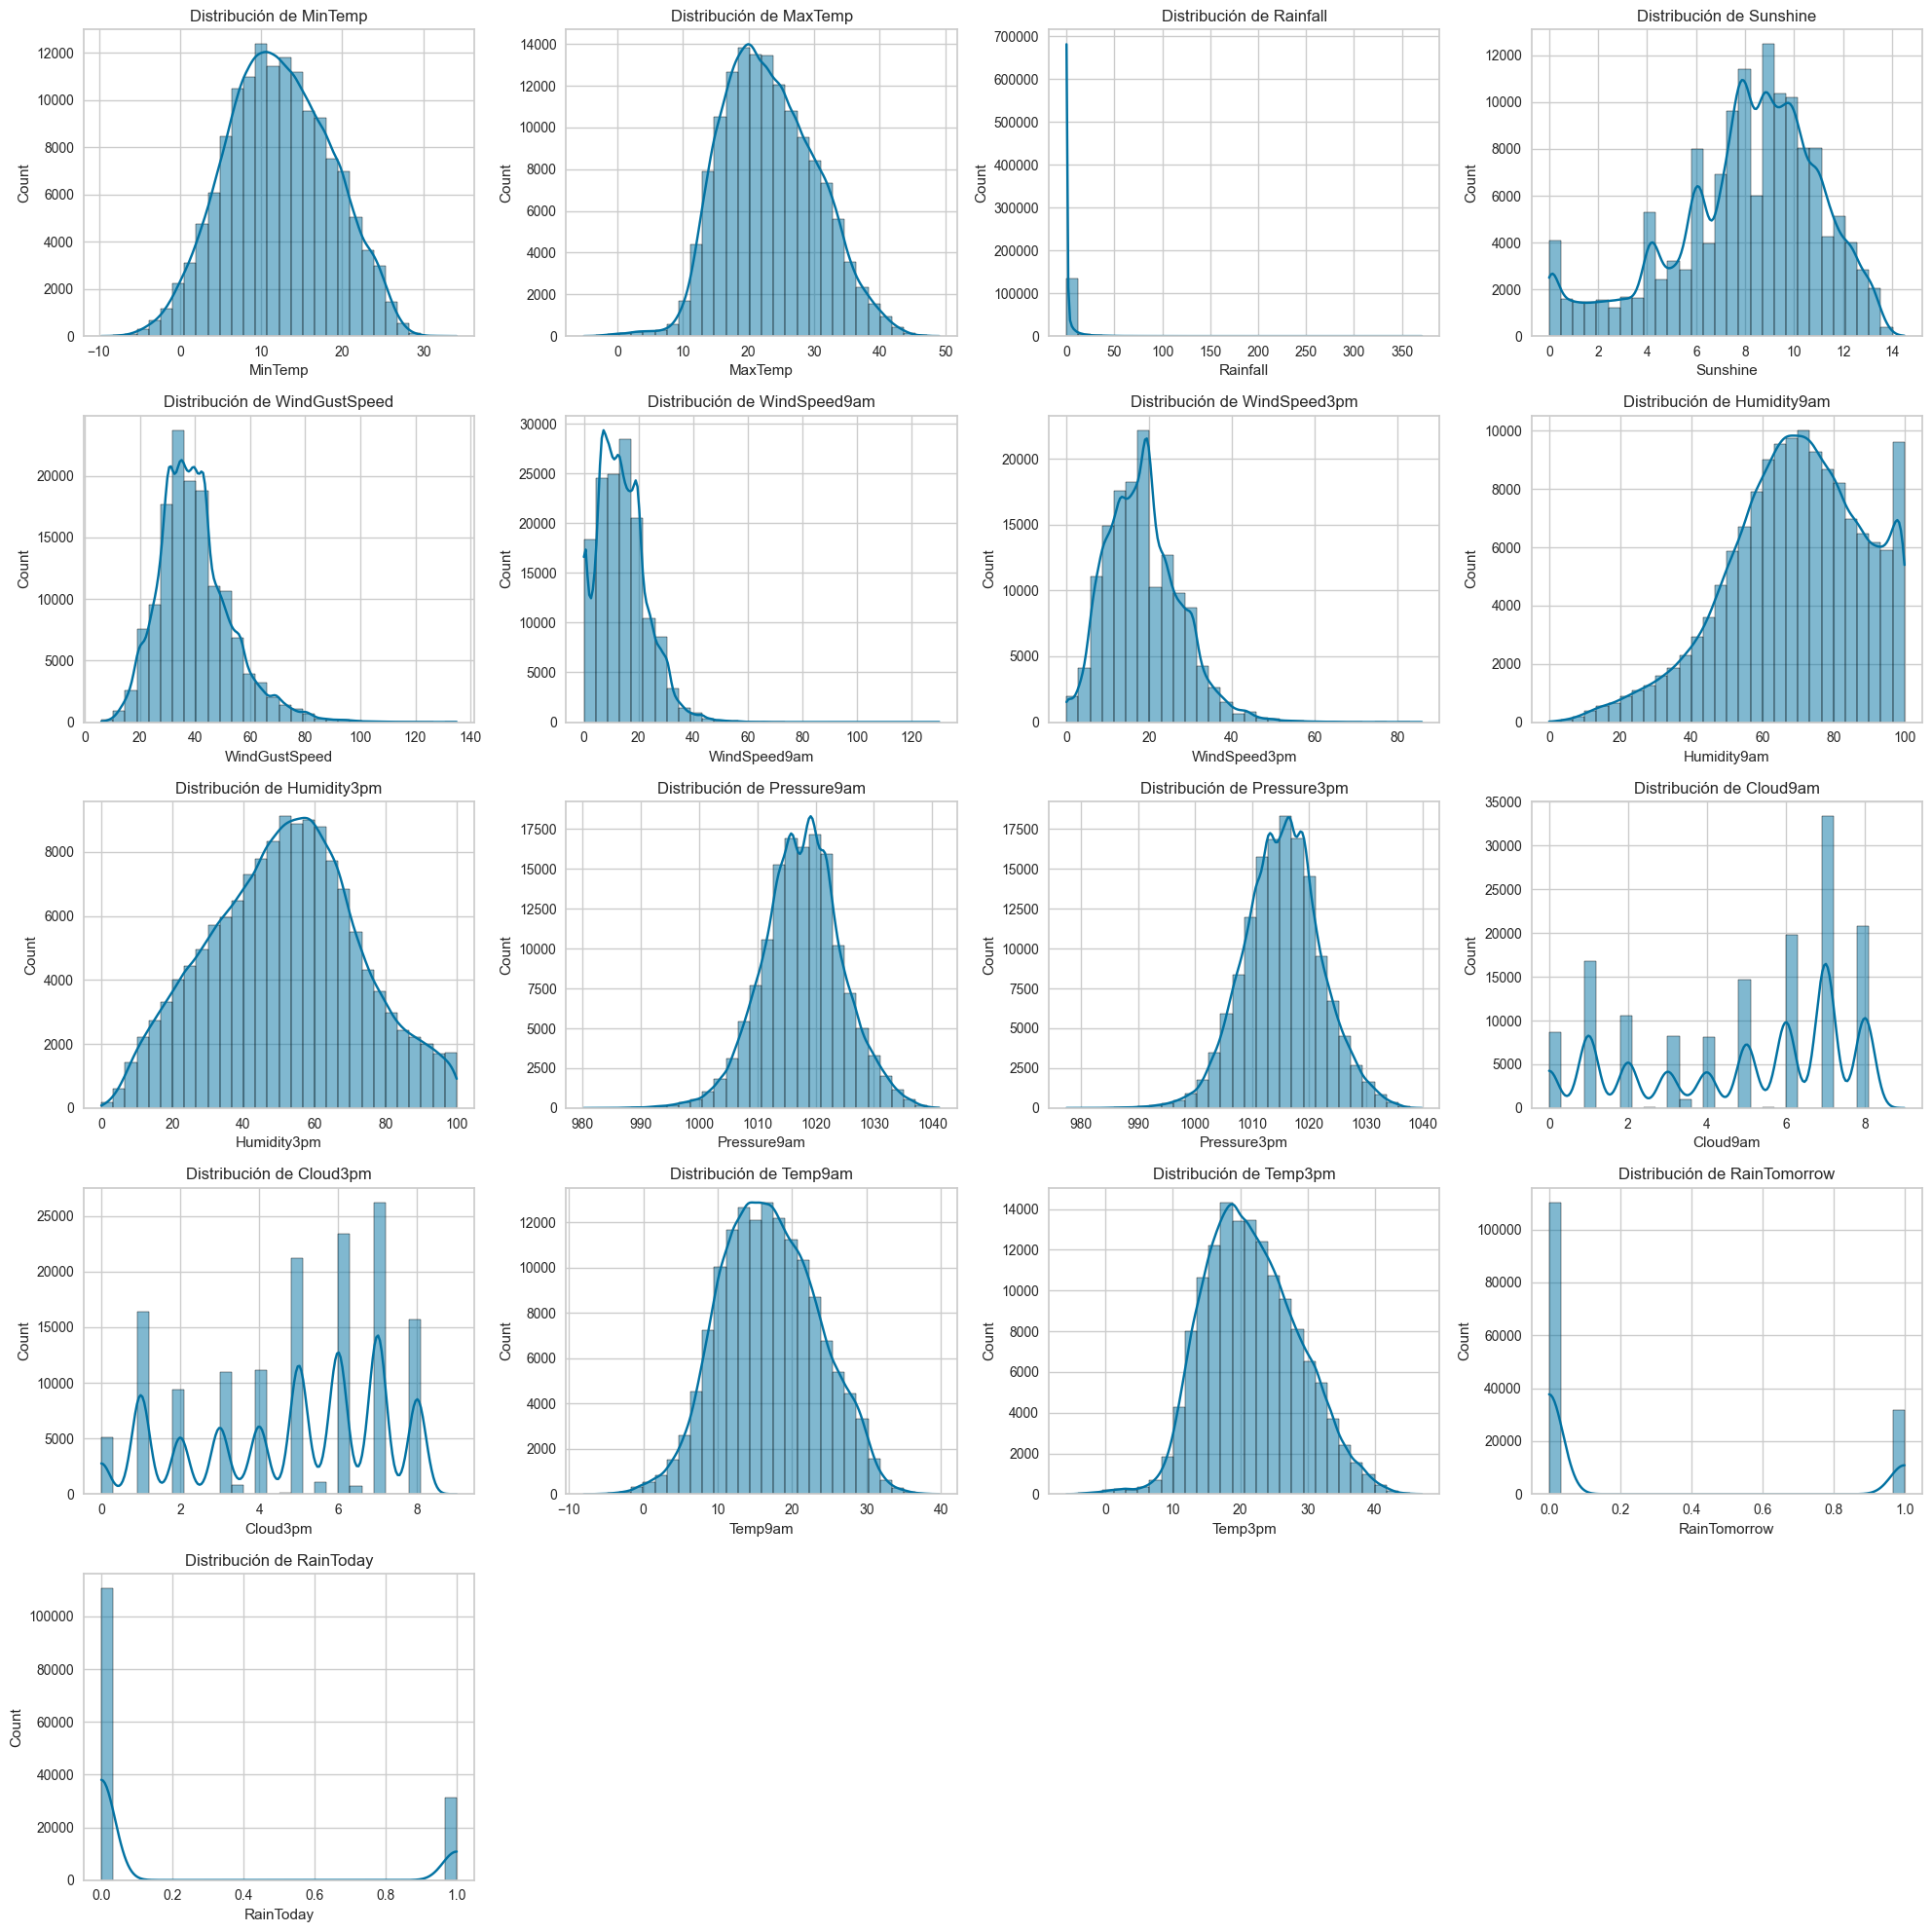

In [34]:
cols_plot = [
    'MinTemp',
    'MaxTemp',
    'Rainfall',
    'Sunshine',
    'WindGustSpeed',
    'WindSpeed9am',
    'WindSpeed3pm',
    'Humidity9am',
    'Humidity3pm',
    'Pressure9am',
    'Pressure3pm',
    'Cloud9am',
    'Cloud3pm',
    'Temp9am',
    'Temp3pm',
    "RainTomorrow",
    "RainToday"
]

n_cols = 4
n_rows = math.ceil(len(cols_plot) / n_cols)

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(cols_plot, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

Las distribuciones muestran que varias variables climáticas presentan comportamientos esperables y útiles para el análisis predictivo. Las temperaturas (`MinTemp`, `MaxTemp`, `Temp9am`, `Temp3pm`) y las presiones (`Pressure9am`, `Pressure3pm`) tienen distribuciones relativamente concentradas y con forma aproximadamente campanular, aunque con cierta asimetría. En cambio, variables como `Rainfall`, `Evaporation`, `WindGustSpeed` y velocidades de viento presentan sesgo hacia la derecha, con muchos valores bajos y pocos valores extremos, lo que sugiere la presencia de eventos climáticos intensos pero poco frecuentes. Las variables de nubosidad (`Cloud9am`, `Cloud3pm`) muestran valores discretos, ya que representan niveles de cobertura nubosa, mientras que `RainToday` y `RainTomorrow` evidencian claramente el desbalance de clases: predominan ampliamente los días sin lluvia. Este desbalance debe tenerse en cuenta al evaluar modelos, ya que métricas como accuracy pueden resultar engañosas si no se complementan con recall, precision, F1-score y balanced accuracy.

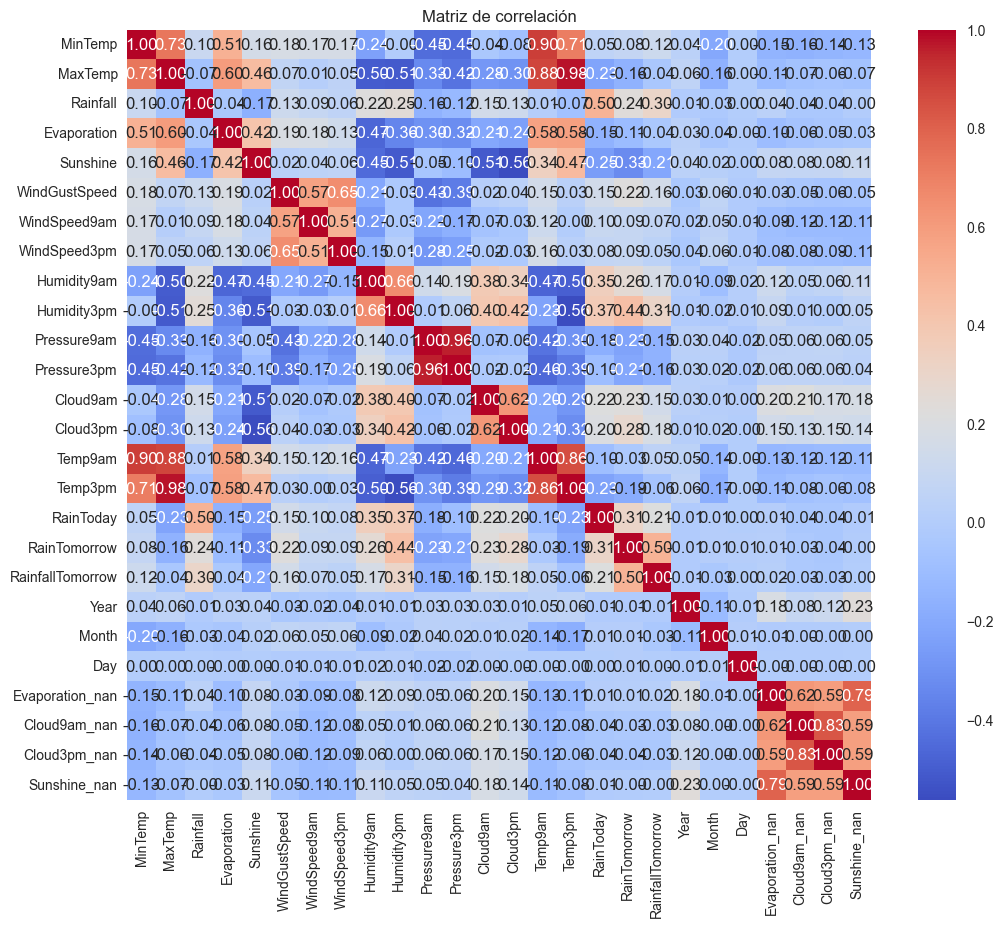

In [35]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

La matriz de correlación permitió identificar relaciones lineales fuertes entre variables medidas en distintos horarios del día, especialmente en temperatura y presión atmosférica, indicando posibles problemas de multicolinealidad y redundancia de información, sin embargo, dichas relaciones resultan físicamente coherentes. Se observaron asociaciones relevantes entre humedad, nubosidad y horas de sol, consistentes con el comportamiento esperado de fenómenos atmosféricos relacionados con precipitaciones.

In [36]:
cols_numericas = df.select_dtypes(include="number").columns

cols_predictores = cols_numericas.drop("RainTomorrow", errors="ignore")

corr = df[cols_predictores].corr()

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

tabla_corr = (
    corr.where(mask)
    .stack()
    .reset_index()
)

tabla_corr.columns = ["Variable 1", "Variable 2", "Correlación"]

tabla_corr["Correlación absoluta"] = tabla_corr["Correlación"].abs()

tabla_corr = tabla_corr.sort_values(
    "Correlación absoluta",
    ascending=False
)

tabla_corr.head(15)

,Variable 1,Variable 2,Correlación,Correlación absoluta
33,MaxTemp,Temp3pm,0.977979,0.977979
155,Pressure9am,Pressure3pm,0.958949,0.958949
13,MinTemp,Temp9am,0.896753,0.896753
32,MaxTemp,Temp9am,0.882539,0.882539
189,Temp9am,Temp3pm,0.857427,0.857427
0,MinTemp,MaxTemp,0.732723,0.732723
14,MinTemp,Temp3pm,0.708449,0.708449
132,Humidity9am,Humidity3pm,0.662649,0.662649
91,WindGustSpeed,WindSpeed3pm,0.652404,0.652404
174,Cloud9am,Cloud3pm,0.618718,0.618718


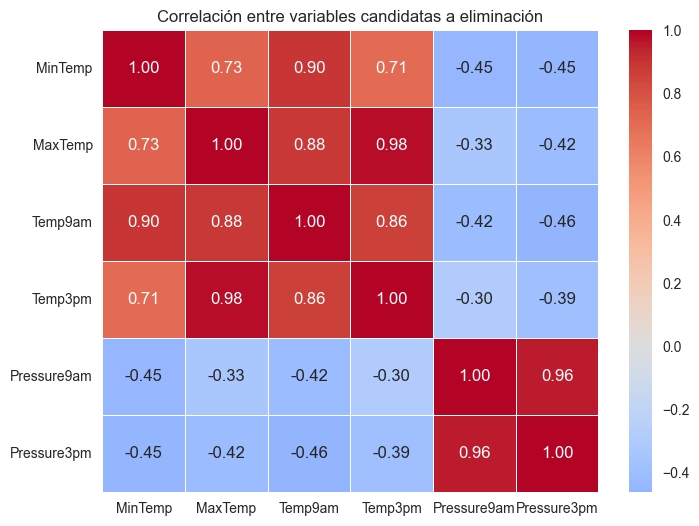

In [37]:
cols_redundancia = [
    "MinTemp",
    "MaxTemp",
    "Temp9am",
    "Temp3pm",
    "Pressure9am",
    "Pressure3pm"
]

cols_redundancia = [
    col for col in cols_redundancia
    if col in df.columns
]

corr_redundancia = df[cols_redundancia].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_redundancia,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlación entre variables candidatas a eliminación")
plt.show()

A partir de la matriz de correlación general se identificaron pares de variables numéricas con alta asociación lineal. Para complementar la visualización, se construyó una tabla ordenada por correlación absoluta, lo que permite observar de forma directa los pares de predictores con mayor redundancia.

En particular, `Pressure9am` y `Pressure3pm` presentan una correlación de aproximadamente 0.96, por lo que se decidió conservar `Pressure3pm` y eliminar `Pressure9am`, reduciendo información repetida dentro del conjunto de entrada. De forma similar, `MinTemp`, `MaxTemp` y `Temp3pm`  presentan una alta correlación con otras variables de temperatura, por lo que se decidió dejar sólo una para simplificar el modelo y reducir redundancia entre predictores.

Esta decisión no implica que `Temp9am` o `Pressure9am` no estén relacionadas con la lluvia al día siguiente, sino que parte de su información ya está representada por otras variables conservadas. El objetivo es obtener un conjunto de variables más simple e interpretable, evitando incluir múltiples predictores que describen fenómenos muy similares.

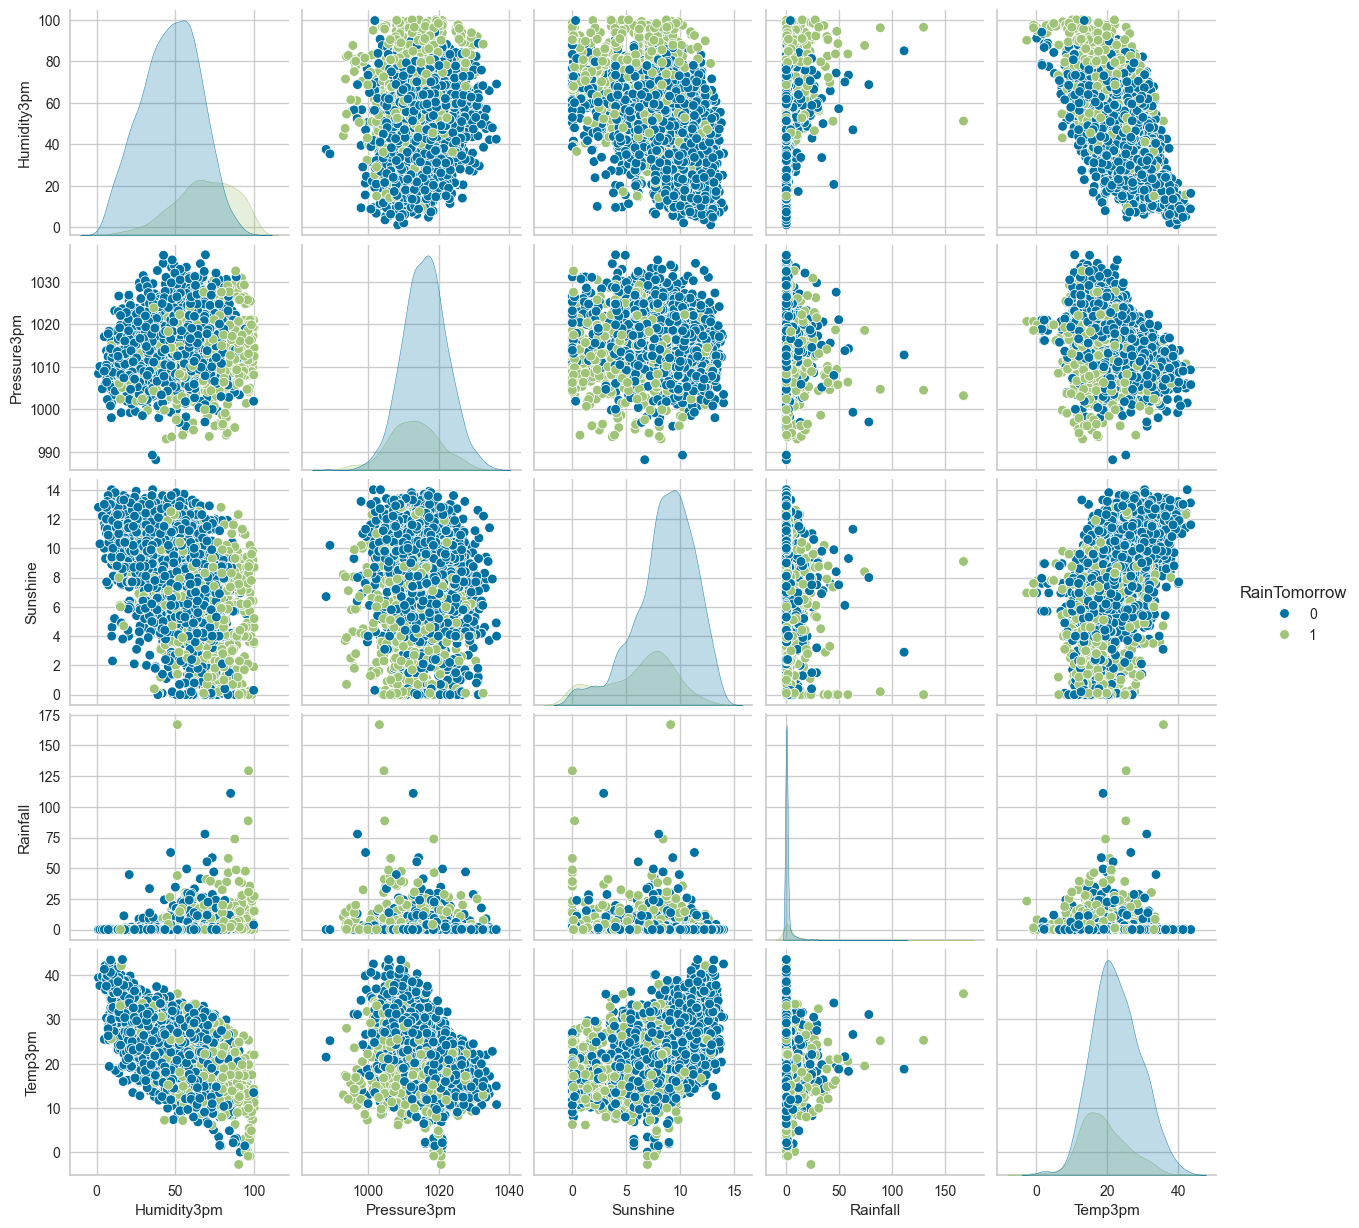

In [38]:
pair_cols = [
    "Humidity3pm",
    "Pressure3pm",
    "Sunshine",
    "Rainfall",
    "Temp3pm",
    "RainTomorrow"
]

sns.pairplot(
    df[pair_cols].sample(3000),
    hue="RainTomorrow"
)

El análisis del pairplot permitió identificar relaciones relevantes entre las variables meteorológicas y la variable objetivo (`RainTomorrow`). Variables como `Humidity3pm`, `Pressure3pm` y `Sunshine` muestran una separación visual clara entre clases, indicando un alto potencial predictivo. En particular, los casos asociados a lluvia futura presentan mayores niveles de humedad, menores niveles de presión atmosférica y menor cantidad de horas de sol. Además, se observaron relaciones coherentes entre variables, como la relación inversa entre humedad y sunshine, y distribuciones altamente asimétricas en variables como `Rainfall`, comportamiento esperable en fenómenos climáticos reales.

Se considera importante no eliminar los Outliers en este dataset ya que si bien algunos datos pueden alejarse del comportamiento normal de los datos, siguen siendo casos reales de condiciones climaticas y es necesario que el modela sepa que hacer en caso de que ellos se repitan.

In [39]:
df["Rainfall_log"] = np.log1p(df["Rainfall"])

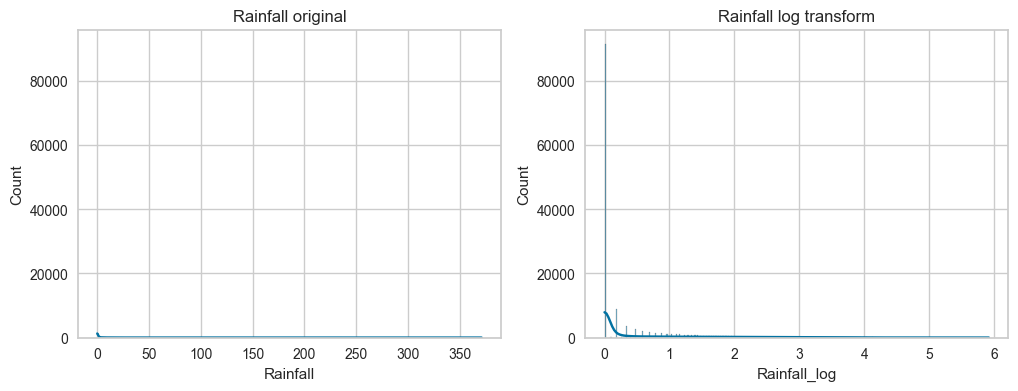

In [40]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df["Rainfall"], kde=True, ax=ax[0])
ax[0].set_title("Rainfall original")

sns.histplot(df["Rainfall_log"], kde=True, ax=ax[1])
ax[1].set_title("Rainfall log transform")

plt.show()

Se aplica una transformación Logaritmica a la variable para reducir el rango de trabajo.

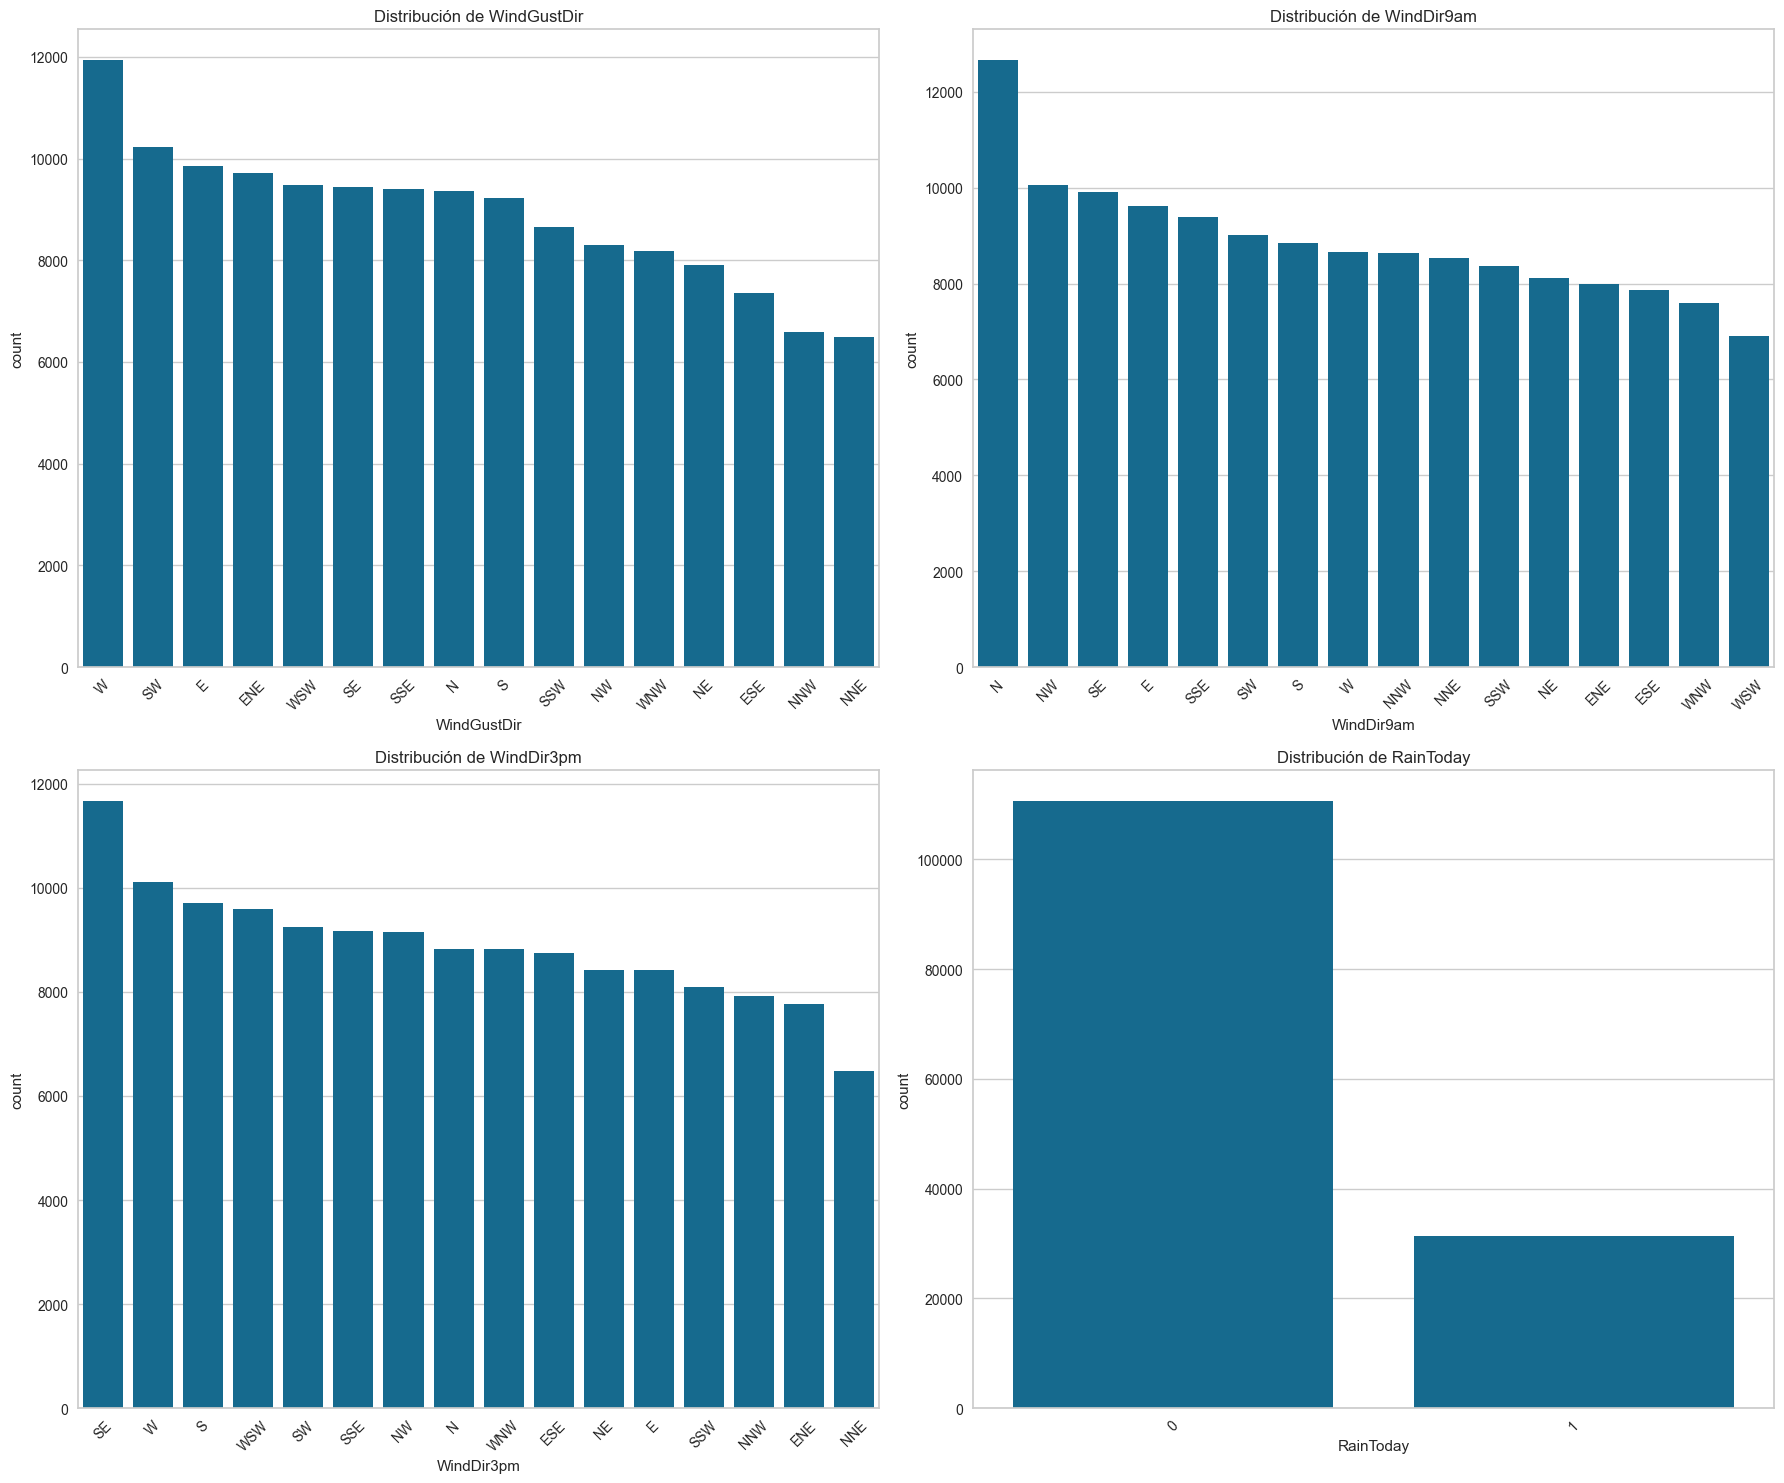

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(18,15))

axes = axes.flatten()

for ax, col in zip(axes, cols_categoricas):

    sns.countplot(
        data=df,
        x=col,
        ax=ax,
        order=df[col].value_counts().index
    )

    ax.set_title(f"Distribución de {col}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

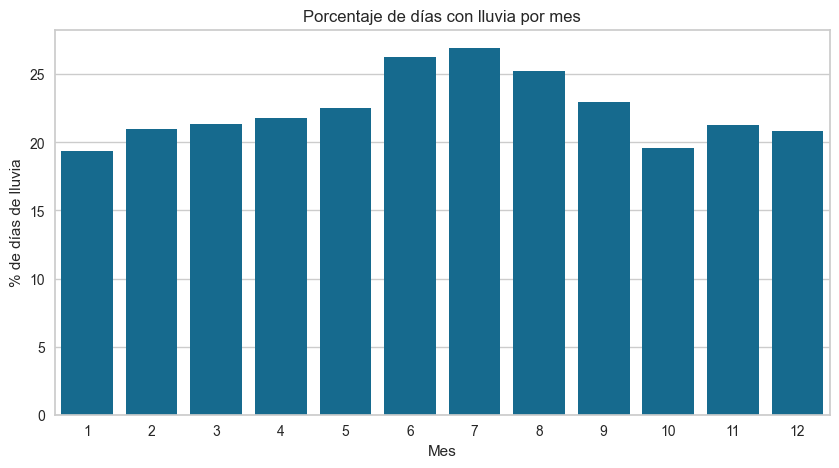

In [42]:
rain_month = (
    df.groupby("Month")["RainTomorrow"]
    .mean()
    .mul(100)
    .reset_index(name="% RainTomorrow = 1")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=rain_month,
    x="Month",
    y="% RainTomorrow = 1"
)

plt.title("Porcentaje de días con lluvia por mes")
plt.xlabel("Mes")
plt.ylabel("% de días de lluvia")
plt.show()

Cómo era de esperarse, hay una relación marcada entre lluvia y estación del año.

Con esto se finalizó el EDA. Lo primero que se hizo fué observar superficialmente los datos para tratar de encontrar problemas en el Dataset, se terminó observando que había una gran cantidad de NaN, al investigar un poco se llegó a la conclusión de que el motivo de los faltantes está directamente relacionado a la tecnología disponible por cada observatorio. Para poder imputar los datos faltantes se implementó un criterio de Imputación por lugar o vecinos, que refiere a, en los casos dónde hay pocos faltantes, usar la media de la variable en ese lugar y ese mes para poder usar de referencia una media que entienda las diferencias geograficas y de tiempo para cada valor, ya que no sería justo comparar la media de temperatura máxima en Junio al sur que la media en Agosto al norte. El segundo criterio que se empleó, para los casos dónde no se tiene ningún dato en todo el mes, ya que el observatorio no es capaz de medir esa variable, es un criterio de "vecinos cercanos", que usando de referencia la ubicación geografica de cada observatorio arma un calendario de vecinos y usa una media entre los valores de la media en ese mes del nan de los alrededores para estimar un valor posible para el faltante.  Con estos métodos se pudieron imputar todos los ausentes sin alterar demasiado las métricas del dataset.

In [43]:
col_drop = [
    "Evaporation",
    "RainfallTomorrow",
    "Rainfall",
    "MaxTemp",
    "Temp9am",
    "Pressure9am",
    "Evaporation_nan",
    "Cloud9am_nan",
    "Cloud3pm_nan",
    "Sunshine_nan",
    "Day",
    "Year"]

df_model = df.drop(columns=col_drop)
df_model

,Location,MinTemp,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure3pm,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,Rainfall_log
0,Albury,13.6,9.8,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1007.2,8.0,5.0,20.8,0,0,12,0.470004
1,Albury,7.3,9.8,WNW,44.0,NNW,WSW,4.0,23.0,40.1,22.1,1007.5,7.0,5.0,24.6,0,0,12,0.000000
2,Albury,13.2,9.8,WSW,46.0,W,WSW,20.0,27.0,36.2,31.5,1009.4,7.0,2.0,23.4,0,0,12,0.000000
3,Albury,10.0,9.8,NE,23.0,SE,E,10.0,10.0,45.8,18.5,1012.4,7.0,5.0,26.3,0,0,12,0.000000
4,Albury,17.4,9.8,W,41.0,ENE,NW,6.0,17.0,83.5,34.6,1005.9,7.0,8.0,29.1,0,0,12,0.693147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145407,Uluru,2.6,7.5,E,29.0,ESE,E,14.0,11.0,58.6,26.5,1021.2,6.0,3.0,21.6,0,0,6,0.000000
145408,Uluru,3.1,7.5,E,31.0,SE,ENE,14.0,10.0,51.9,24.7,1020.5,6.0,3.0,21.5,0,0,6,0.000000
145409,Uluru,3.6,7.5,NNW,21.0,SE,N,13.0,6.0,56.5,21.4,1018.4,6.0,3.0,24.5,0,0,6,0.000000
145410,Uluru,4.8,7.5,N,39.0,SE,WNW,10.0,8.0,52.5,23.7,1016.0,6.0,3.0,26.9,0,0,6,0.000000


Basandose en la matriz de correlación se considera que estas vars pueden meter ruido al modelo por la gran correlación entre las var a las 9am y las 3pm, nos quedaremos directamente con las últimas.  
Ademá se opta por eliminar evaporation, por lo mencionado antes, Rainfall, porque ya se ha hecho una nueva versión transformada y los indicadores de nan.  
Tambien se elimina RainfallTomorrow porque si intentamos predecir si va a llover o no mañana, no tendría sentido usar la información sobre cantidad de lluvia de mañana, ya que se supone que no lo sabemos.  
Y por último, se eliminan Day y Year ya que no hay relación directa entre día del mes y año con el clima, y mantener esssa información podría llevar a que el modelo encuentre relaciones ficticias entre esos datos. Month se deja ya que el mes del año si hace alución a la estación del año y tiene relación con tendencias climaticas.

In [44]:
X = df_model.drop(columns=["RainTomorrow"])
y = df_model["RainTomorrow"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

se hace el split de datos en train, test y validation

In [45]:
cat_cols = [
    "Location",
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "Month"
]

ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

# Se ajusta SOLO con train
X_train_encoded = ohe.fit_transform(X_train[cat_cols])

# Se transforma validation y test con el encoder ya ajustado
X_val_encoded = ohe.transform(X_val[cat_cols])
X_test_encoded = ohe.transform(X_test[cat_cols])

encoded_cols = ohe.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_cols,
    index=X_val.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

X_train = pd.concat(
    [
        X_train.drop(columns=cat_cols),
        X_train_encoded
    ],
    axis=1
)

X_val = pd.concat(
    [
        X_val.drop(columns=cat_cols),
        X_val_encoded
    ],
    axis=1
)

X_test = pd.concat(
    [
        X_test.drop(columns=cat_cols),
        X_test_encoded
    ],
    axis=1
)

Las variables categóricas nominales (`Location`, `WindGustDir`, `WindDir9am` y `WindDir3pm`) fueron transformadas mediante One Hot Encoding utilizando `OneHotEncoder` de Scikit-Learn. Este método genera una columna binaria para cada categoría presente en la variable, permitiendo representar información categórica en modelos matemáticos sin introducir relaciones ordinales artificiales entre categorías. Se utilizó `drop='first'` para evitar redundancia y reducir posibles problemas de multicolinealidad.

In [46]:
# se separan las columnas entre Standard y Robust
standard_cols = [
    "MinTemp",
    "Temp3pm",
    "Pressure3pm",
    "Humidity9am",
    "Humidity3pm",
    "Sunshine"
]

robust_cols = [
    "Rainfall_log",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm"
]

standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_train[standard_cols] = standard_scaler.fit_transform(
    X_train[standard_cols]
)

X_val[standard_cols] = standard_scaler.transform(
    X_val[standard_cols]
)

X_test[standard_cols] = standard_scaler.transform(
    X_test[standard_cols]
)

X_train[robust_cols] = robust_scaler.fit_transform(
    X_train[robust_cols]
)

X_val[robust_cols] = robust_scaler.transform(
    X_val[robust_cols]
)

X_test[robust_cols] = robust_scaler.transform(
    X_test[robust_cols]
)

X_train.head()

,MinTemp,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure3pm,Cloud9am,Cloud3pm,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
57764,-1.175968,-1.288890,1.5625,2.583333,0.500000,1.605852,2.332890,-1.268989,8.0,7.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
31606,1.048240,0.015415,0.4375,0.250000,0.666667,0.118026,0.487057,-0.410278,6.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42226,-1.331507,0.602353,-0.0625,1.500000,-0.583333,-0.924500,-1.069611,0.344796,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
38451,-0.538258,-0.571522,-0.5000,-0.500000,0.083333,1.385822,0.684653,-0.173392,8.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
33683,-0.304950,0.504530,-1.0000,-0.166667,-0.666667,0.207086,0.284642,0.152326,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Las variables numéricas fueron escaladas utilizando distintos métodos según su distribución. Para variables con comportamiento aproximadamente normal se utilizó `StandardScaler`, que centra los datos en media 0 y desviación estándar 1. En variables con fuerte asimetría y presencia de outliers, como precipitaciones y velocidades de viento, se utilizó `RobustScaler`, basado en mediana e IQR, reduciendo la sensibilidad a valores extremos. Los escaladores fueron ajustados únicamente sobre el conjunto de entrenamiento para evitar data leakage.

In [47]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [48]:
y_pred_train = log_reg.predict(X_train)
y_pred_val = log_reg.predict(X_val)
y_pred_test = log_reg.predict(X_test)

y_proba_train = log_reg.predict_proba(X_train)[:, 1]
y_proba_val = log_reg.predict_proba(X_val)[:, 1]
y_proba_test = log_reg.predict_proba(X_test)[:, 1]

In [49]:
def resumen_metricas_clasificacion(nombre, y_true, y_pred, y_proba):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return pd.DataFrame({
        "Modelo": [nombre],

        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Balanced Accuracy": [balanced_accuracy_score(y_true, y_pred)],

        "Precision": [precision_score(y_true, y_pred, zero_division=0)],
        "Recall": [recall_score(y_true, y_pred, zero_division=0)],
        "Specificity": [specificity],
        "F1 Score": [f1_score(y_true, y_pred, zero_division=0)],

        "ROC AUC": [roc_auc_score(y_true, y_proba)],
        "PR AUC / Avg Precision": [average_precision_score(y_true, y_proba)],
        "Brier Score": [brier_score_loss(y_true, y_proba)],

        "MCC": [matthews_corrcoef(y_true, y_pred)],
        "Cohen Kappa": [cohen_kappa_score(y_true, y_pred)],

        "TN": [tn],
        "FP": [fp],
        "FN": [fn],
        "TP": [tp]
    })

In [50]:
print("Reporte de clasificación - Test")
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["No llueve", "Llueve"],
        zero_division=0
    )
)

Reporte de clasificación - Test
              precision    recall  f1-score   support

   No llueve       0.92      0.80      0.86     22057
      Llueve       0.52      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



In [51]:
metricas_train = resumen_metricas_clasificacion(
    "Regresión Logística - Train",
    y_train,
    y_pred_train,
    y_proba_train
)

metricas_test = resumen_metricas_clasificacion(
    "Regresión Logística - Test",
    y_test,
    y_pred_test,
    y_proba_test
)

tabla_metricas_logreg = pd.concat(
    [metricas_train, metricas_test],
    ignore_index=True
)

tabla_metricas_logreg

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Regresión Logística - Train,0.793838,0.787151,0.527389,0.775027,0.799275,0.627665,0.871862,0.702719,0.144048,0.509584,0.492150,56412,14167,4589,15809
1,Regresión Logística - Test,0.791601,0.784146,0.523947,0.770631,0.797661,0.623786,0.871421,0.703195,0.144216,0.504137,0.486809,17594,4463,1462,4912


Se calculan métricas clásicas de clasificación y métricas adicionales. Debido al desbalance de clases, no se utiliza únicamente accuracy, sino también balanced accuracy, precision, recall, F1, ROC-AUC y Average Precision. Además, se incorporan MCC y Cohen's Kappa como métricas complementarias para evaluar la calidad global de la clasificación.

In [52]:
fpr_val, tpr_val, thresholds_roc_val = roc_curve(y_val, y_proba_val)

youden_index = tpr_val - fpr_val
best_idx_youden = np.argmax(youden_index)
best_threshold_youden = thresholds_roc_val[best_idx_youden]

precision_val, recall_val, thresholds_pr_val = precision_recall_curve(
    y_val,
    y_proba_val
)

f1_scores = 2 * (precision_val * recall_val) / (precision_val + recall_val)

best_idx_f1 = np.nanargmax(f1_scores[:-1])
best_threshold_f1 = thresholds_pr_val[best_idx_f1]

print(f"Mejor umbral según Youden en validación: {best_threshold_youden:.4f}")
print(f"Mejor umbral según F1 en validación: {best_threshold_f1:.4f}")
print(f"F1 en validación: {f1_scores[best_idx_f1]:.4f}")

Mejor umbral según Youden en validación: 0.5219
Mejor umbral según F1 en validación: 0.6066
F1 en validación: 0.6403


In [53]:
threshold_elegido = best_threshold_f1

y_pred_train_logreg_final = (y_proba_train >= threshold_elegido).astype(int)
y_pred_val_logreg_final = (y_proba_val >= threshold_elegido).astype(int)
y_pred_test_logreg_final = (y_proba_test >= threshold_elegido).astype(int)

print(f"Umbral elegido para Regresión Logística: {threshold_elegido:.4f}")

Umbral elegido para Regresión Logística: 0.6066


In [54]:
metricas_logreg_final_train = resumen_metricas_clasificacion(
    "Regresión Logística - Train - Umbral F1",
    y_train,
    y_pred_train_logreg_final,
    y_proba_train
)

metricas_logreg_final_test = resumen_metricas_clasificacion(
    "Regresión Logística - Test - Umbral F1",
    y_test,
    y_pred_test_logreg_final,
    y_proba_test
)

tabla_metricas_logreg_final = pd.concat(
    [metricas_logreg_final_train, metricas_logreg_final_test],
    ignore_index=True
)

tabla_metricas_logreg_final

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Regresión Logística - Train - Umbral F1,0.826638,0.778279,0.598225,0.690607,0.865952,0.641105,0.871862,0.702719,0.144048,0.529959,0.527595,61118,9461,6311,14087
1,Regresión Logística - Test - Umbral F1,0.823291,0.774507,0.591266,0.686068,0.862946,0.635149,0.871421,0.703195,0.144216,0.521907,0.519407,19034,3023,2001,4373


In [55]:
umbrales = {
    "Regresión Logística - Umbral 0.5": 0.5,
    "Regresión Logística - Umbral Youden": best_threshold_youden,
    "Regresión Logística - Umbral F1": best_threshold_f1
}

resultados_umbrales = []

for nombre, threshold in umbrales.items():
    y_pred_umbral = (y_proba_test >= threshold).astype(int)

    resultados_umbrales.append(
        resumen_metricas_clasificacion(
            nombre,
            y_test,
            y_pred_umbral,
            y_proba_test
        )
    )

tabla_umbrales = pd.concat(resultados_umbrales, ignore_index=True)

tabla_umbrales

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Regresión Logística - Umbral 0.5,0.791601,0.784146,0.523947,0.770631,0.797661,0.623786,0.871421,0.703195,0.144216,0.504137,0.486809,17594,4463,1462,4912
1,Regresión Logística - Umbral Youden,0.799796,0.783515,0.538186,0.754001,0.813030,0.628071,0.871421,0.703195,0.144216,0.509485,0.496280,17933,4124,1568,4806
2,Regresión Logística - Umbral F1,0.823291,0.774507,0.591266,0.686068,0.862946,0.635149,0.871421,0.703195,0.144216,0.521907,0.519407,19034,3023,2001,4373


Se evaluaron distintos umbrales de decisión porque el valor 0.5 no necesariamente es el más adecuado. Al bajar el umbral, el modelo clasifica más observaciones como `Llueve`, lo que suele aumentar el recall, pero también puede aumentar los falsos positivos y reducir la precisión.

El criterio de Youden busca maximizar la diferencia entre la tasa de verdaderos positivos y la tasa de falsos positivos. Por otro lado, el umbral F1 busca el mejor equilibrio entre precision y recall para la clase positiva.

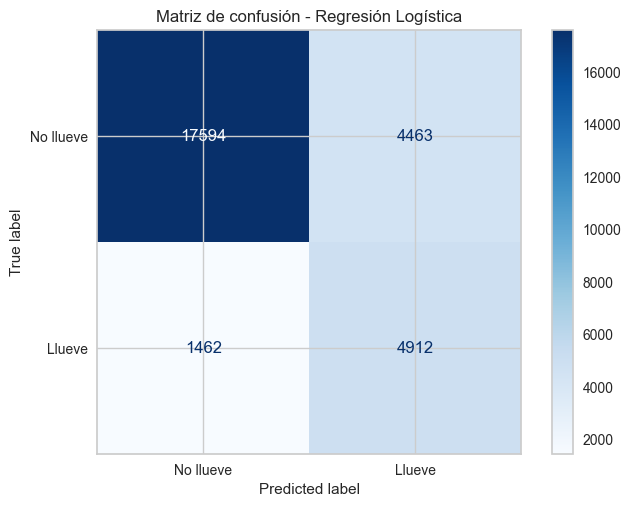

In [56]:
cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No llueve", "Llueve"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

La matriz de confusión permite analizar los aciertos y errores del modelo. Los verdaderos negativos corresponden a días en los que el modelo predijo `No llueve` y efectivamente no llovió. Los verdaderos positivos corresponden a días en los que el modelo predijo `Llueve` y efectivamente llovió.

Un falso positivo ocurre cuando el modelo predice lluvia, pero finalmente no llueve. En cambio, un falso negativo ocurre cuando el modelo predice que no lloverá, pero sí llueve. En este problema, los falsos negativos son especialmente relevantes porque implican no anticipar un evento de lluvia.

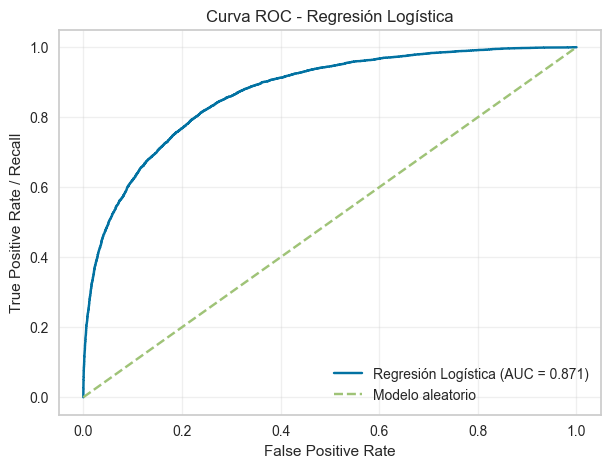

In [57]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modelo aleatorio")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

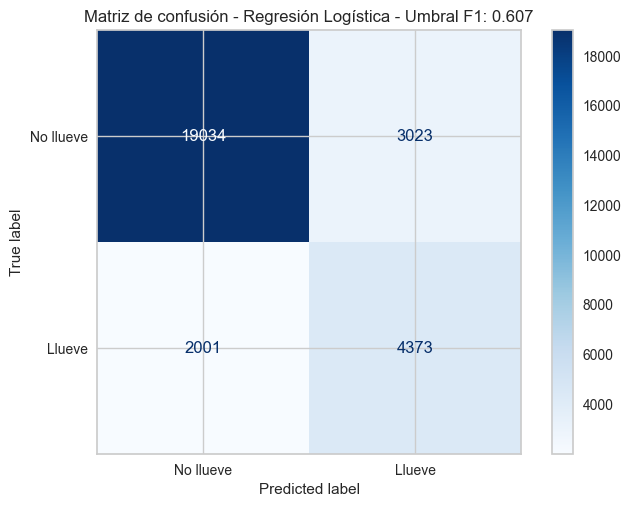

In [58]:
threshold_elegido = best_threshold_f1

y_pred_test_f1 = (y_proba_test >= threshold_elegido).astype(int)

cm_f1 = confusion_matrix(y_test, y_pred_test_f1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_f1,
    display_labels=["No llueve", "Llueve"]
)

disp.plot(cmap="Blues")
plt.title(f"Matriz de confusión - Regresión Logística - Umbral F1: {threshold_elegido:.3f}")
plt.show()

In [59]:
print("Reporte de clasificación - Test - Umbral mejor F1")
print(
    classification_report(
        y_test,
        y_pred_test_f1,
        target_names=["No llueve", "Llueve"],
        zero_division=0
    )
)

Reporte de clasificación - Test - Umbral mejor F1
              precision    recall  f1-score   support

   No llueve       0.90      0.86      0.88     22057
      Llueve       0.59      0.69      0.64      6374

    accuracy                           0.82     28431
   macro avg       0.75      0.77      0.76     28431
weighted avg       0.83      0.82      0.83     28431



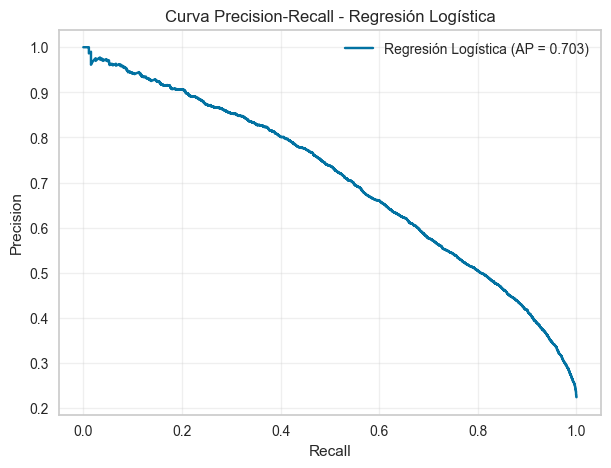

In [60]:
precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_test)
ap_log = average_precision_score(y_test, y_proba_test)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_log,
    precision_log,
    label=f"Regresión Logística (AP = {ap_log:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Regresión Logística")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Se incorpora la curva Precision-Recall porque el dataset presenta desbalance entre clases. Esta curva permite analizar la relación entre precision y recall para la clase positiva (`Llueve`). A diferencia de la curva ROC, se enfoca directamente en el desempeño sobre la clase minoritaria, por lo que resulta especialmente útil para este problema.

La Regresión Logística obtuvo un desempeño estable entre entrenamiento y prueba, por lo que no se observan señales fuertes de sobreajuste. El accuracy en test fue cercano a 0.85, aunque esta métrica debe interpretarse con cuidado debido al desbalance de clases observado previamente.

Al analizar la clase positiva (`Llueve`), el modelo con umbral 0.5 obtuvo una precisión de 0.73 y un recall de 0.51. Esto indica que, cuando el modelo predice lluvia, suele acertar en una proporción considerable de casos, pero también deja sin detectar una parte importante de los días en los que efectivamente llueve.

En la matriz de confusión se observan 1200 falsos positivos y 3109 falsos negativos. En este problema, un falso positivo significa predecir lluvia cuando finalmente no llueve, mientras que un falso negativo significa predecir que no lloverá cuando sí llueve. Este último error puede ser especialmente relevante, ya que implica no anticipar un evento de lluvia.

La curva ROC obtuvo un AUC de 0.871, lo cual indica una buena capacidad del modelo para separar las clases. Sin embargo, el umbral 0.5 no necesariamente es el más adecuado. Al comparar distintos umbrales, el criterio de Youden aumenta considerablemente el recall, aunque reduce la precisión y genera más falsos positivos. El umbral que maximiza F1 ofrece un equilibrio más conveniente entre precisión y recall, por lo que se considera una alternativa más adecuada para este modelo.

In [61]:
modelo_base = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

modelo_base.fit(X_train, y_train)

y_pred_base_train = modelo_base.predict(X_train)
y_pred_base_test = modelo_base.predict(X_test)

y_proba_base_train = modelo_base.predict_proba(X_train)[:, 1]
y_proba_base_test = modelo_base.predict_proba(X_test)[:, 1]

Se implementó un modelo base utilizando `DummyClassifier` con la estrategia `most_frequent`. Este modelo no aprende relaciones entre las variables predictoras y la variable objetivo, sino que predice siempre la clase más frecuente del conjunto de entrenamiento. Su objetivo es servir como referencia mínima para evaluar si los modelos entrenados posteriormente logran superar una regla simple.

In [62]:
metricas_base_train = resumen_metricas_clasificacion(
    "Modelo Base - Train",
    y_train,
    y_pred_base_train,
    y_proba_base_train
)

metricas_base_test = resumen_metricas_clasificacion(
    "Modelo Base - Test",
    y_test,
    y_pred_base_test,
    y_proba_base_test
)

tabla_metricas_base = pd.concat(
    [metricas_base_train, metricas_base_test],
    ignore_index=True
)

tabla_metricas_base

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Modelo Base - Train,0.775789,0.5,0.0,0.0,1.0,0.0,0.5,0.224211,0.224211,0.0,0.0,70579,0,20398,0
1,Modelo Base - Test,0.775808,0.5,0.0,0.0,1.0,0.0,0.5,0.224192,0.224192,0.0,0.0,22057,0,6374,0


In [63]:
print("Reporte de clasificación - Modelo Base - Test")
print(
    classification_report(
        y_test,
        y_pred_base_test,
        target_names=["No llueve", "Llueve"],
        zero_division=0
    )
)

Reporte de clasificación - Modelo Base - Test
              precision    recall  f1-score   support

   No llueve       0.78      1.00      0.87     22057
      Llueve       0.00      0.00      0.00      6374

    accuracy                           0.78     28431
   macro avg       0.39      0.50      0.44     28431
weighted avg       0.60      0.78      0.68     28431



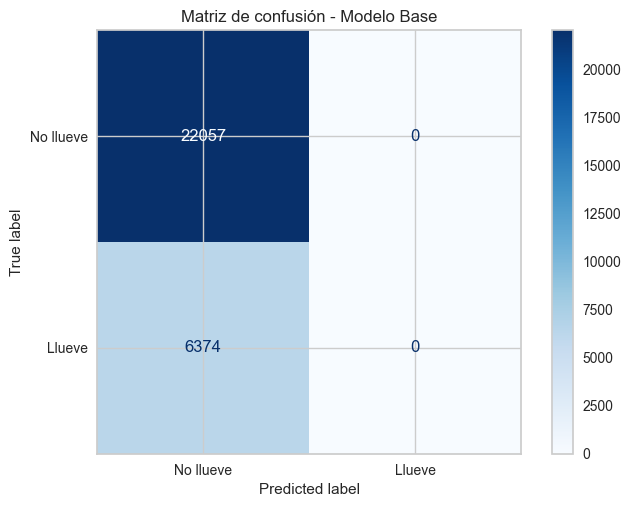

In [64]:
cm_base = confusion_matrix(y_test, y_pred_base_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=["No llueve", "Llueve"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Modelo Base")
plt.show()

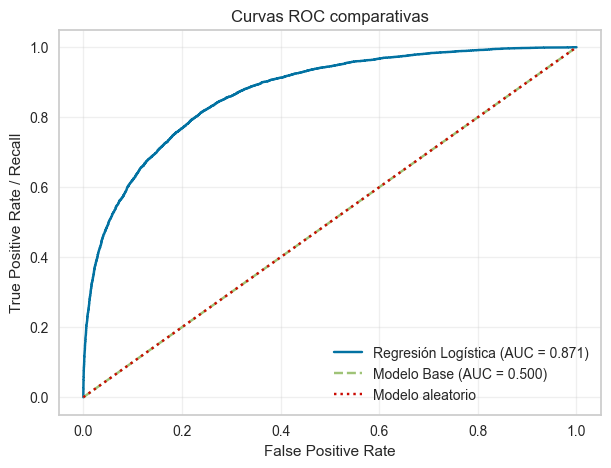

In [65]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_test)
auc_log = roc_auc_score(y_test, y_proba_test)

fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base_test)
auc_base = roc_auc_score(y_test, y_proba_base_test)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Regresión Logística (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_base,
    tpr_base,
    linestyle="--",
    label=f"Modelo Base (AUC = {auc_base:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    label="Modelo aleatorio"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Curvas ROC comparativas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La curva ROC comparativa muestra que el modelo base no tiene capacidad discriminativa, ya que su AUC es 0.5. En cambio, la Regresión Logística alcanza un AUC cercano a 0.871, lo que indica una capacidad considerablemente mayor para separar los casos de lluvia y no lluvia.

In [66]:
comparacion_base = pd.concat(
    [
        tabla_metricas_base[tabla_metricas_base["Modelo"] == "Modelo Base - Test"],
        tabla_metricas_logreg[tabla_metricas_logreg["Modelo"] == "Regresión Logística - Test"],
        tabla_umbrales[tabla_umbrales["Modelo"] == "Regresión Logística - Umbral F1"]
    ],
    ignore_index=True
)

comparacion_base

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Modelo Base - Test,0.775808,0.500000,0.000000,0.000000,1.000000,0.000000,0.500000,0.224192,0.224192,0.000000,0.000000,22057,0,6374,0
1,Regresión Logística - Test,0.791601,0.784146,0.523947,0.770631,0.797661,0.623786,0.871421,0.703195,0.144216,0.504137,0.486809,17594,4463,1462,4912
2,Regresión Logística - Umbral F1,0.823291,0.774507,0.591266,0.686068,0.862946,0.635149,0.871421,0.703195,0.144216,0.521907,0.519407,19034,3023,2001,4373


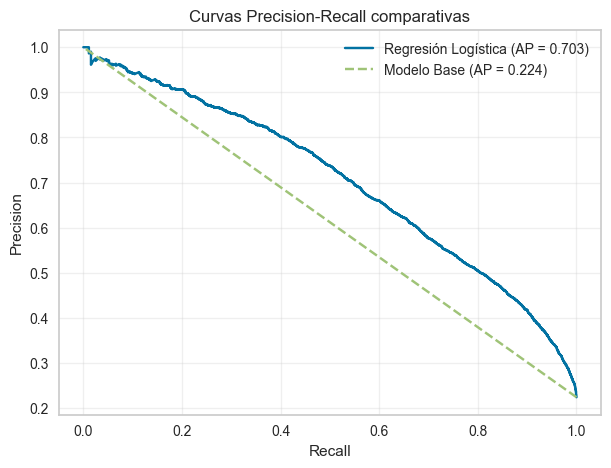

In [67]:
precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_test)
ap_log = average_precision_score(y_test, y_proba_test)

precision_base, recall_base, _ = precision_recall_curve(y_test, y_proba_base_test)
ap_base = average_precision_score(y_test, y_proba_base_test)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_log,
    precision_log,
    label=f"Regresión Logística (AP = {ap_log:.3f})"
)

plt.plot(
    recall_base,
    precision_base,
    linestyle="--",
    label=f"Modelo Base (AP = {ap_base:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall comparativas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El modelo base obtuvo una accuracy relativamente alta debido al desbalance del dataset, ya que la clase mayoritaria es `No llueve`. Sin embargo, este resultado no implica un buen desempeño predictivo: al predecir siempre la clase mayoritaria, el modelo no logra identificar correctamente los casos de lluvia.

Esto se observa especialmente en el recall y el F1-score de la clase positiva (`Llueve`), que resultan nulos o muy bajos. La matriz de confusión muestra que todos o casi todos los días con lluvia son clasificados como `No llueve`, generando una gran cantidad de falsos negativos.

Por este motivo, el modelo base permite confirmar que la accuracy no es suficiente para evaluar este problema. Dado que el dataset está desbalanceado, es necesario considerar métricas como balanced accuracy, recall, precision, F1-score y ROC-AUC. En comparación, la Regresión Logística mejora claramente el desempeño del modelo base, ya que logra detectar una proporción significativa de días con lluvia y obtiene un AUC superior.

In [68]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid_logreg = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    }
]

grid_logreg = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    param_grid=param_grid_logreg,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_logreg.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=5000, random_state=42),
             n_jobs=-1,
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'],
                          'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
                         {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'], 'penalty': ['l2'],
                          'solver': ['lbfgs']},
                         {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'],
                          'penalty': ['l1', 'l2'], 'solver': ['saga']}],
             scoring='f1', verbose=1)

Luego de aplicar GridSearchCV con validación cruzada estratificada de 5 folds, la mejor combinación de hiperparámetros para la Regresión Logística fue `C=1`, `penalty="l2"`, `solver="lbfgs"` y `class_weight="balanced"`.

Esto indica que el modelo obtuvo mejor desempeño utilizando regularización L2 y compensando el desbalance de clases mediante pesos automáticos. La elección de `class_weight="balanced"` resulta coherente con el problema, ya que la clase positiva, correspondiente a los días con lluvia, se encuentra menos representada en el dataset.

La búsqueda evaluó 60 combinaciones de hiperparámetros, cada una mediante 5 particiones de validación cruzada. De esta forma, la selección del modelo no dependió de una única partición de validación, sino del desempeño promedio obtenido en distintos folds.

In [69]:
resultados_grid_logreg = pd.DataFrame(grid_logreg.cv_results_)

columnas_resultados = [
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "param_C",
    "param_penalty",
    "param_solver",
    "param_class_weight"
]

resultados_grid_logreg[columnas_resultados] \
    .sort_values("rank_test_score") \
    .head(10)

,mean_test_score,std_test_score,rank_test_score,param_C,param_penalty,param_solver,param_class_weight
50,0.626654,0.002736,1,1,l1,saga,balanced
14,0.626652,0.002603,2,1,l1,liblinear,balanced
15,0.626590,0.002679,3,1,l2,liblinear,balanced
18,0.626585,0.002809,4,10,l1,liblinear,balanced
33,0.626532,0.002910,5,10,l2,lbfgs,balanced
51,0.626525,0.002669,6,1,l2,saga,balanced
54,0.626522,0.002826,7,10,l1,saga,balanced
55,0.626508,0.002889,8,10,l2,saga,balanced
19,0.626508,0.002889,8,10,l2,liblinear,balanced
31,0.626500,0.002630,10,1,l2,lbfgs,balanced


In [70]:
resultados_grid_logreg = pd.DataFrame(grid_logreg.cv_results_)

columnas_resultados = [
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "param_C",
    "param_penalty",
    "param_solver",
    "param_class_weight"
]

resultados_grid_logreg[columnas_resultados] \
    .sort_values("rank_test_score") \
    .head(10)

,mean_test_score,std_test_score,rank_test_score,param_C,param_penalty,param_solver,param_class_weight
50,0.626654,0.002736,1,1,l1,saga,balanced
14,0.626652,0.002603,2,1,l1,liblinear,balanced
15,0.626590,0.002679,3,1,l2,liblinear,balanced
18,0.626585,0.002809,4,10,l1,liblinear,balanced
33,0.626532,0.002910,5,10,l2,lbfgs,balanced
51,0.626525,0.002669,6,1,l2,saga,balanced
54,0.626522,0.002826,7,10,l1,saga,balanced
55,0.626508,0.002889,8,10,l2,saga,balanced
19,0.626508,0.002889,8,10,l2,liblinear,balanced
31,0.626500,0.002630,10,1,l2,lbfgs,balanced


In [71]:
best_logreg = grid_logreg.best_estimator_

y_pred_train_logreg_opt = best_logreg.predict(X_train)
y_pred_test_logreg_opt = best_logreg.predict(X_test)

y_proba_train_logreg_opt = best_logreg.predict_proba(X_train)[:, 1]
y_proba_test_logreg_opt = best_logreg.predict_proba(X_test)[:, 1]

metricas_logreg_opt = pd.DataFrame({
    "Modelo": ["Regresión Logística optimizada"],
    "Accuracy Train": [accuracy_score(y_train, y_pred_train_logreg_opt)],
    "Accuracy Test": [accuracy_score(y_test, y_pred_test_logreg_opt)],
    "Precision Test": [precision_score(y_test, y_pred_test_logreg_opt, zero_division=0)],
    "Recall Test": [recall_score(y_test, y_pred_test_logreg_opt, zero_division=0)],
    "F1 Test": [f1_score(y_test, y_pred_test_logreg_opt, zero_division=0)],
    "ROC-AUC Test": [roc_auc_score(y_test, y_proba_test_logreg_opt)]
})

metricas_logreg_opt

,Modelo,Accuracy Train,Accuracy Test,Precision Test,Recall Test,F1 Test,ROC-AUC Test
0,Regresión Logística optimizada,0.793926,0.791706,0.524114,0.770631,0.623904,0.871427


In [72]:
print("Reporte de clasificación - Regresión Logística optimizada")
print(classification_report(y_test, y_pred_test_logreg_opt, zero_division=0))

Reporte de clasificación - Regresión Logística optimizada
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     22057
           1       0.52      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



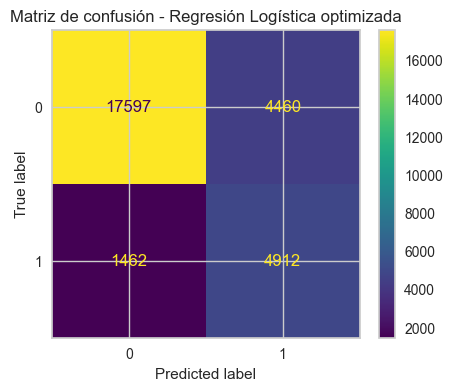

In [73]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_logreg_opt,
    ax=ax
)

ax.set_title("Matriz de confusión - Regresión Logística optimizada")
plt.show()

La matriz de confusión de la Regresión Logística optimizada muestra que el modelo identifica correctamente una proporción importante de los días con lluvia. En particular, se observan 4914 verdaderos positivos y 1460 falsos negativos, lo que indica que el modelo logra recuperar una parte considerable de la clase positiva.

Sin embargo, también se observan 4459 falsos positivos, es decir, días en los que el modelo predijo lluvia pero finalmente no llovió. Esto puede estar asociado al uso de `class_weight="balanced"`, que incrementa la sensibilidad del modelo hacia la clase minoritaria. En este problema, este comportamiento puede ser aceptable si se prioriza reducir los falsos negativos, ya que no anticipar un día de lluvia puede ser más relevante que emitir una alerta de lluvia que luego no ocurre.

En conjunto, el modelo presenta un buen recall para la clase lluvia, aunque con una precisión más moderada debido al aumento de falsos positivos.

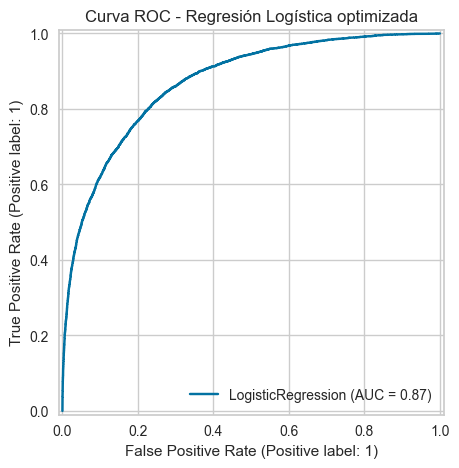

In [74]:
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_estimator(
    best_logreg,
    X_test,
    y_test,
    ax=ax
)

ax.set_title("Curva ROC - Regresión Logística optimizada")
plt.show()

La curva ROC de la Regresión Logística optimizada muestra la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos para distintos umbrales de decisión. El área bajo la curva obtenida fue aproximadamente `AUC = 0.87`, lo que indica una buena capacidad del modelo para distinguir entre días con lluvia y días sin lluvia.

Un valor de AUC cercano a 1 representa una mejor capacidad de separación entre clases, mientras que un valor cercano a 0.5 indicaría un comportamiento similar al azar. En este caso, el resultado sugiere que el modelo asigna, en general, probabilidades más altas a los casos donde efectivamente llueve que a los casos donde no llueve.


In [75]:
y_proba_train_oof = cross_val_predict(
    best_logreg,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_train,
    y_proba_train_oof
)

f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-9)

best_idx = np.argmax(f1_scores[:-1])
best_threshold_f1_logreg = thresholds[best_idx]

print(f"Mejor umbral según F1 en validación cruzada: {best_threshold_f1_logreg:.4f}")
print(f"F1 asociado en validación cruzada: {f1_scores[best_idx]:.4f}")

Mejor umbral según F1 en validación cruzada: 0.6182
F1 asociado en validación cruzada: 0.6403


In [76]:
y_pred_test_logreg_opt_thr = (y_proba_test_logreg_opt >= best_threshold_f1_logreg).astype(int)
y_pred_train_logreg_opt_thr = (y_proba_train_logreg_opt >= best_threshold_f1_logreg).astype(int)

metricas_logreg_opt_thr = pd.DataFrame({
    "Modelo": ["Regresión Logística optimizada + umbral ajustado"],
    "Threshold": [best_threshold_f1_logreg],
    "Accuracy Train": [accuracy_score(y_train, y_pred_train_logreg_opt_thr)],
    "Accuracy Test": [accuracy_score(y_test, y_pred_test_logreg_opt_thr)],
    "Precision Test": [precision_score(y_test, y_pred_test_logreg_opt_thr, zero_division=0)],
    "Recall Test": [recall_score(y_test, y_pred_test_logreg_opt_thr, zero_division=0)],
    "F1 Test": [f1_score(y_test, y_pred_test_logreg_opt_thr, zero_division=0)],
    "ROC-AUC Test": [roc_auc_score(y_test, y_proba_test_logreg_opt)]
})

metricas_logreg_opt_thr


,Modelo,Threshold,Accuracy Train,Accuracy Test,Precision Test,Recall Test,F1 Test,ROC-AUC Test
0,Regresión Logística optimizada + umbral ajustado,0.618212,0.829341,0.826703,0.600808,0.676498,0.636411,0.871427


Se realizó una búsqueda de hiperparámetros mediante GridSearchCV, utilizando validación cruzada estratificada de 5 particiones. Se optimizaron los parámetros `C`, `penalty`, `solver` y `class_weight`.

El parámetro `C` controla la intensidad de la regularización: valores pequeños implican una regularización más fuerte, mientras que valores grandes permiten un ajuste más flexible. También se evaluaron distintas penalizaciones (`l1` y `l2`) y la opción `class_weight="balanced"`, debido al desbalance existente entre los días con lluvia y sin lluvia.

Luego de seleccionar la mejor combinación de hiperparámetros, se evaluó el modelo sobre el conjunto de test. Además, se ajustó el umbral de decisión a partir de probabilidades obtenidas mediante validación cruzada sobre el conjunto de entrenamiento, evitando utilizar el conjunto de test para tomar decisiones de ajuste.

Comparando el modelo optimizado con el modelo inicial, se observa si la optimización mejora principalmente el F1-score y el recall de la clase positiva, que en este problema representa los días en los que efectivamente llueve al día siguiente.

In [77]:
print("Reporte de clasificación - Regresión Logística optimizada con umbral ajustado")
print(classification_report(y_test, y_pred_test_logreg_opt_thr, zero_division=0))

Reporte de clasificación - Regresión Logística optimizada con umbral ajustado
              precision    recall  f1-score   support

           0       0.90      0.87      0.89     22057
           1       0.60      0.68      0.64      6374

    accuracy                           0.83     28431
   macro avg       0.75      0.77      0.76     28431
weighted avg       0.84      0.83      0.83     28431



In [78]:
def calcular_metricas_clasificacion(nombre_modelo, y_true, y_pred, y_proba=None, threshold=None):
    metricas = {
        "Modelo": nombre_modelo,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }
    
    if y_proba is not None:
        metricas["ROC-AUC"] = roc_auc_score(y_true, y_proba)
    
    return pd.DataFrame([metricas])

In [79]:
comparacion_logreg_opt = pd.concat([
    calcular_metricas_clasificacion(
        "Regresión Logística optimizada - threshold 0.5",
        y_test,
        y_pred_test_logreg_opt,
        y_proba_test_logreg_opt,
        threshold=0.5
    ),
    calcular_metricas_clasificacion(
        "Regresión Logística optimizada - threshold ajustado",
        y_test,
        y_pred_test_logreg_opt_thr,
        y_proba_test_logreg_opt,
        threshold=best_threshold_f1_logreg
    )
])

comparacion_logreg_opt

,Modelo,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística optimizada - threshold 0.5,0.500000,0.791706,0.524114,0.770631,0.623904,0.871427
0,Regresión Logística optimizada - threshold aju...,0.618212,0.826703,0.600808,0.676498,0.636411,0.871427


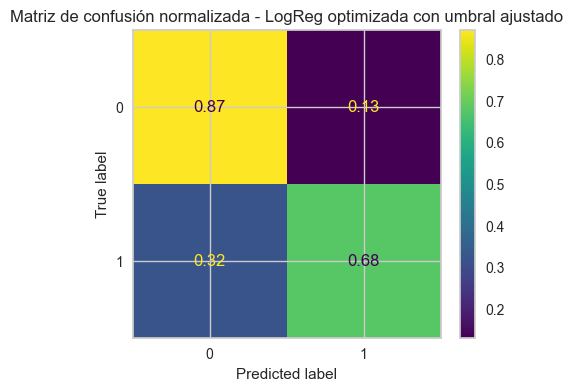

In [80]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_logreg_opt_thr,
    normalize="true",
    ax=ax
)

ax.set_title("Matriz de confusión normalizada - LogReg optimizada con umbral ajustado")
plt.show()

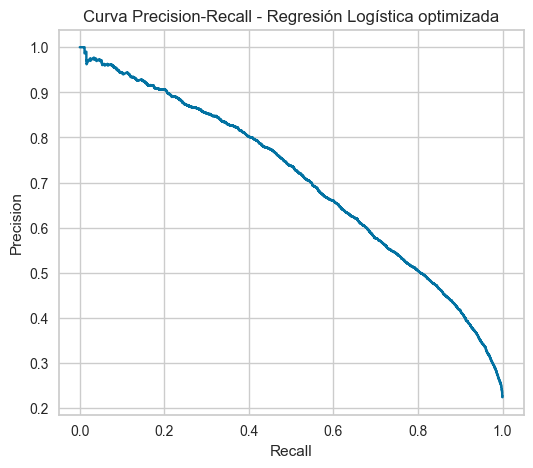

In [81]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(
    y_test,
    y_proba_test_logreg_opt
)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Regresión Logística optimizada")
plt.grid(True)
plt.show()

La curva Precision-Recall muestra el intercambio entre la precisión y el recall para distintos umbrales de decisión. En este problema resulta especialmente útil porque la clase positiva, correspondiente a los días con lluvia, se encuentra menos representada que la clase negativa.

Se observa que, a medida que aumenta el recall, la precisión tiende a disminuir. Esto significa que, si el modelo intenta detectar una mayor proporción de días con lluvia, también aumenta la cantidad de falsos positivos, es decir, días predichos como lluvia en los que finalmente no llueve. Por el contrario, cuando se exige mayor precisión, el modelo se vuelve más restrictivo y detecta menos casos positivos.

Este comportamiento refleja el compromiso entre reducir falsos negativos y controlar falsos positivos. Dado que el objetivo no es solamente acertar la clase mayoritaria, sino detectar adecuadamente los días con lluvia, se utiliza esta curva junto con el F1-score para seleccionar un umbral de decisión más adecuado que el valor por defecto de 0.5.

Luego de optimizar los hiperparámetros de la Regresión Logística mediante GridSearchCV, se seleccionó como mejor modelo aquel con regularización L2, `C=1`, solver `lbfgs` y `class_weight="balanced"`.

El uso de `class_weight="balanced"` indica que compensar el desbalance de clases fue relevante para mejorar el desempeño del modelo, especialmente considerando que la clase positiva, correspondiente a los días con lluvia, se encuentra menos representada.

Además de evaluar el modelo con el umbral por defecto de 0.5, se ajustó el umbral de decisión buscando maximizar el F1-score. Esta decisión permite modificar el equilibrio entre precision y recall según el objetivo del problema. En este caso, el análisis de la matriz de confusión permite observar cómo cambia la cantidad de falsos positivos y falsos negativos al aplicar el nuevo umbral.

La curva ROC mostró un AUC aproximado de 0.87, lo que indica una buena capacidad general del modelo para separar entre días con lluvia y sin lluvia. Sin embargo, el AUC no define por sí solo el umbral óptimo, por lo que se complementó el análisis con métricas de clasificación, matriz de confusión y curva Precision-Recall.

In [82]:
# Usamos una muestra para que el cálculo de SHAP no sea tan pesado
n_train_shap = min(1000, len(X_train))
n_test_shap = min(1000, len(X_test))

X_train_shap = X_train.sample(n=n_train_shap, random_state=42)
X_test_shap = X_test.sample(n=n_test_shap, random_state=42)

y_test_shap = y_test.loc[X_test_shap.index]

print("Shape train SHAP:", X_train_shap.shape)
print("Shape test SHAP:", X_test_shap.shape)

Shape train SHAP: (1000, 117)
Shape test SHAP: (1000, 117)


In [83]:
explainer_logreg = shap.Explainer(
    best_logreg,
    X_train_shap
)

shap_values_logreg = explainer_logreg(X_test_shap)

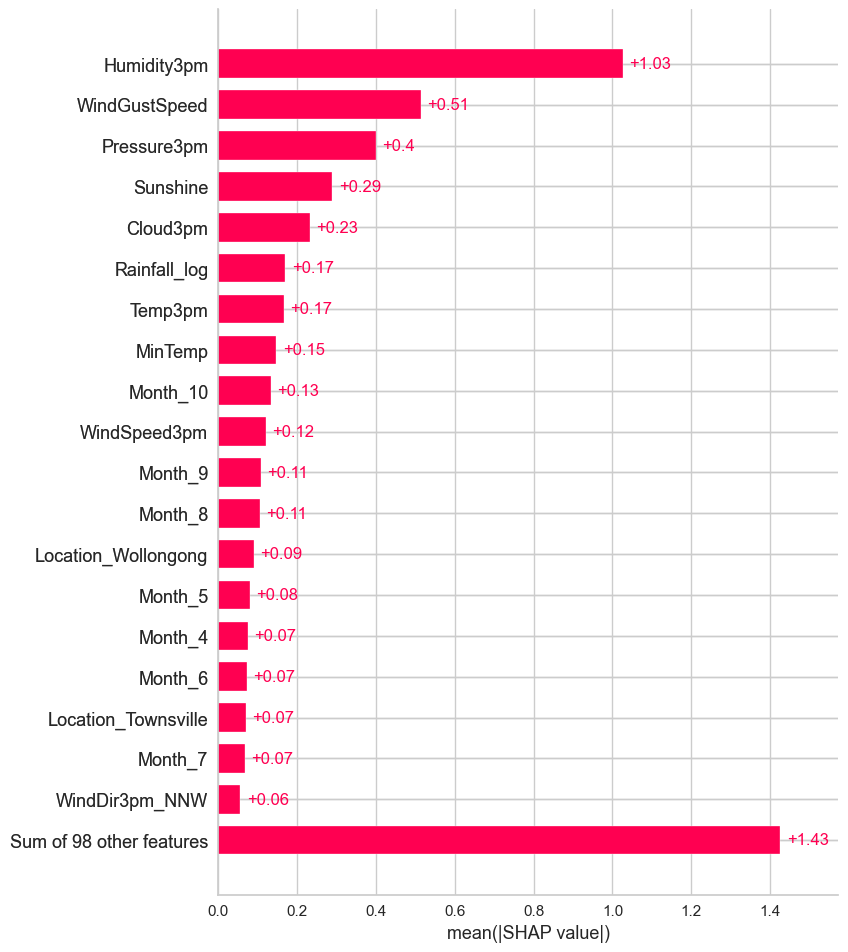

In [84]:
shap.plots.bar(
    shap_values_logreg,
    max_display=20
)

El gráfico global de importancia SHAP muestra que las variables con mayor contribución promedio al modelo son `Humidity3pm`, `WindGustSpeed`, `Pressure3pm`, `Sunshine` y `Cloud3pm`. Esto resulta coherente con el problema meteorológico, ya que la humedad, la velocidad del viento, la presión atmosférica, la nubosidad y las horas de sol son factores asociados a la probabilidad de lluvia.

También aparece `Rainfall_log`, que representa la cantidad de lluvia registrada en el día transformada logarítmicamente, y algunas variables temporales como `Month_10`, `Month_9` y `Month_8`, lo que sugiere que el modelo capta cierta estacionalidad.

Es importante aclarar que este gráfico muestra la magnitud promedio del impacto de cada variable, calculada como el valor absoluto medio de SHAP. Por lo tanto, permite identificar cuáles variables son más importantes, pero no indica por sí solo si valores altos o bajos de cada variable aumentan o disminuyen la probabilidad de lluvia. Para analizar la dirección del efecto se utiliza el gráfico tipo beeswarm.

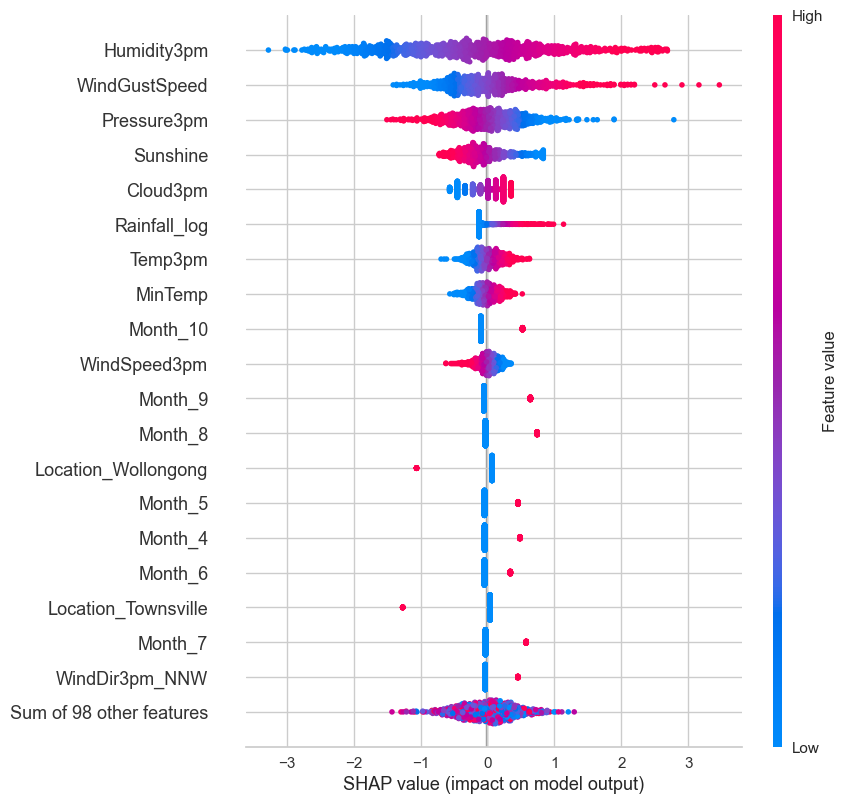

In [85]:
shap.plots.beeswarm(
    shap_values_logreg,
    max_display=20
)

El gráfico beeswarm de SHAP permite analizar no solo la importancia de las variables, sino también la dirección de su efecto sobre la predicción. Los valores SHAP positivos empujan la salida del modelo hacia la clase positiva (`RainTomorrow = 1`), mientras que los valores negativos la alejan de ella.

Se observa que valores altos de `Humidity3pm` aumentan fuertemente la probabilidad estimada de lluvia, mientras que valores bajos la reducen. Algo similar ocurre con `WindGustSpeed`, `Cloud3pm` y `Rainfall_log`, donde valores altos tienden a empujar la predicción hacia la clase lluvia.

Por el contrario, variables como `Pressure3pm` y `Sunshine` muestran una relación inversa: valores altos de presión atmosférica y de horas de sol reducen la probabilidad estimada de lluvia, mientras que valores bajos tienden a aumentarla. Este comportamiento resulta coherente con el fenómeno meteorológico analizado.

También aparecen variables temporales como `Month_10`, `Month_9`, `Month_8` y `Month_5`, lo que sugiere que el modelo capta cierta estacionalidad en la ocurrencia de lluvias. En conjunto, el gráfico muestra que el modelo utiliza principalmente variables relacionadas con humedad, presión, viento, nubosidad, sol y lluvia previa para construir sus predicciones.

In [86]:
importancias_shap_logreg = pd.DataFrame({
    "Variable": X_test_shap.columns,
    "Importancia_SHAP_media": np.abs(shap_values_logreg.values).mean(axis=0)
})

importancias_shap_logreg = importancias_shap_logreg.sort_values(
    by="Importancia_SHAP_media",
    ascending=False
)

importancias_shap_logreg.head(15)

,Variable,Importancia_SHAP_media
6,Humidity3pm,1.026515
2,WindGustSpeed,0.514447
7,Pressure3pm,0.400202
1,Sunshine,0.289146
9,Cloud3pm,0.232736
12,Rainfall_log,0.170535
10,Temp3pm,0.166832
0,MinTemp,0.147379
114,Month_10,0.133203
4,WindSpeed3pm,0.121177


La tabla de importancia SHAP media permite ordenar numéricamente las variables según su contribución promedio al modelo. Se observa que `Humidity3pm` es la variable más influyente, seguida por `WindGustSpeed`, `Pressure3pm`, `Sunshine` y `Cloud3pm`.

Este resultado es coherente con el problema de predicción de lluvia, ya que la humedad, la velocidad del viento, la presión atmosférica, la nubosidad y las horas de sol son variables directamente relacionadas con las condiciones meteorológicas del día. También aparece `Rainfall_log`, que representa la lluvia registrada durante el día transformada logarítmicamente, lo que indica que la lluvia previa aporta información al modelo.

Además, algunas variables temporales como `Month_10`, `Month_9`, `Month_8`, `Month_5` y `Month_4` aparecen entre las más importantes, sugiriendo que el modelo captura cierto comportamiento estacional de la lluvia. La presencia de `Location_Wollongong` indica que la ubicación geográfica también puede aportar información predictiva.

In [87]:
proba_test_shap = best_logreg.predict_proba(X_test_shap)[:, 1]

# Si ya tenés best_threshold_f1_logreg, usamos ese umbral.
# Si no, usamos 0.5.
try:
    threshold_usado = best_threshold_f1_logreg
except NameError:
    threshold_usado = 0.5

pred_test_shap = (proba_test_shap >= threshold_usado).astype(int)

casos_shap = pd.DataFrame({
    "y_real": y_test_shap.values,
    "proba_lluvia": proba_test_shap,
    "y_pred": pred_test_shap
}, index=X_test_shap.index)

casos_shap.head()

,y_real,proba_lluvia,y_pred
46352,0,0.118233,0
34504,0,0.330805,0
8310,0,0.105571,0
1675,1,0.576562,0
101784,0,0.254158,0


In [88]:
idx_alta_lluvia = casos_shap.sort_values(
    by="proba_lluvia",
    ascending=False
).index[0]

idx_baja_lluvia = casos_shap.sort_values(
    by="proba_lluvia",
    ascending=True
).index[0]

pos_alta_lluvia = X_test_shap.index.get_loc(idx_alta_lluvia)
pos_baja_lluvia = X_test_shap.index.get_loc(idx_baja_lluvia)

print("Caso alta probabilidad de lluvia:")
print(casos_shap.loc[idx_alta_lluvia])

print("\nCaso baja probabilidad de lluvia:")
print(casos_shap.loc[idx_baja_lluvia])

Caso alta probabilidad de lluvia:
y_real          1.000000
proba_lluvia    0.997759
y_pred          1.000000
Name: 67792, dtype: float64

Caso baja probabilidad de lluvia:
y_real          0.000000
proba_lluvia    0.003846
y_pred          0.000000
Name: 137014, dtype: float64


Para el análisis local se seleccionaron dos observaciones particulares: una con probabilidad estimada muy alta de lluvia y otra con probabilidad estimada muy baja. En ambos casos, el modelo clasificó correctamente la observación.

En el primer caso, el modelo estimó una probabilidad de lluvia cercana a 0.998 y predijo correctamente la clase positiva (`RainTomorrow = 1`). El gráfico waterfall permite observar qué variables empujaron la salida del modelo hacia la predicción de lluvia. Las contribuciones positivas aumentan la salida del modelo hacia la clase positiva, mientras que las contribuciones negativas la reducen.

En el segundo caso, el modelo estimó una probabilidad de lluvia cercana a 0.004 y predijo correctamente la clase negativa (`RainTomorrow = 0`). En este caso, el gráfico waterfall permite identificar las variables que alejaron la predicción de la clase lluvia y favorecieron la clasificación como no lluvia.

Este análisis local complementa la explicabilidad global, ya que permite observar cómo las variables influyen en predicciones puntuales y no solo en el comportamiento promedio del modelo.

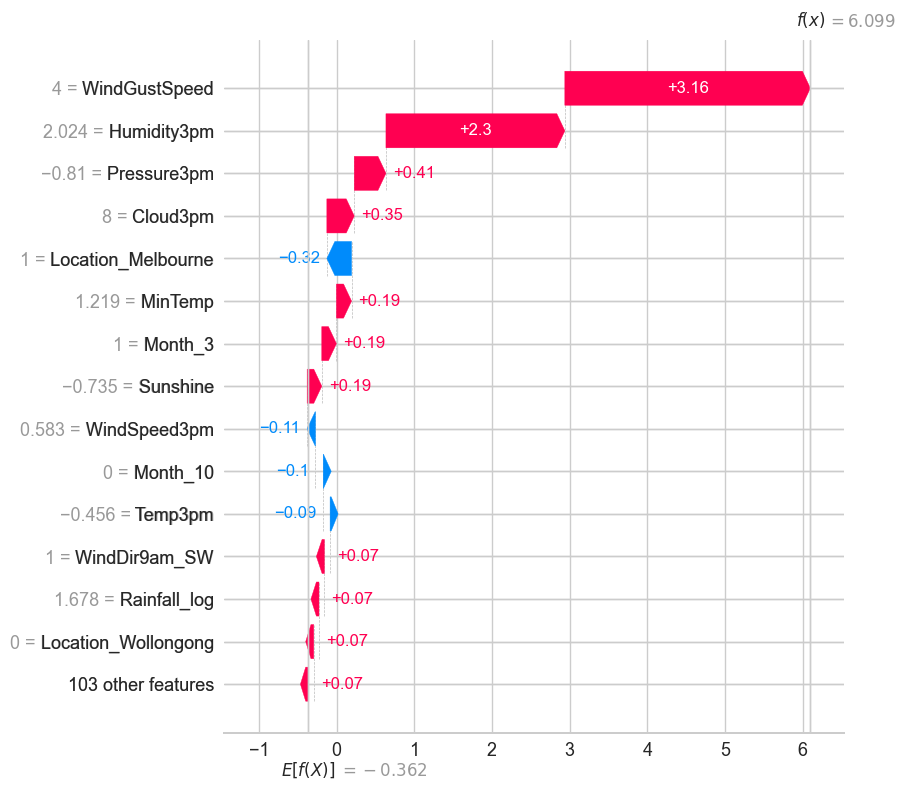

In [89]:
shap.plots.waterfall(
    shap_values_logreg[pos_alta_lluvia],
    max_display=15
)

En la explicación local del caso con alta probabilidad de lluvia, el modelo parte de un valor base `E[f(X)] = -0.362` y llega a una salida final `f(x) = 6.112`, lo que corresponde a una probabilidad estimada de lluvia cercana a 0.998. Esta salida se encuentra en escala de log-odds, propia de la Regresión Logística.

Las variables que más empujan la predicción hacia la clase positiva (`RainTomorrow = 1`) son `WindGustSpeed` y `Humidity3pm`, seguidas por `Pressure3pm`, `Cloud3pm`, `MinTemp`, `Sunshine` y `Rainfall_log`. Esto indica que, para esta observación puntual, el modelo predice lluvia principalmente por la combinación de alta velocidad de ráfagas de viento, alta humedad, nubosidad y lluvia registrada durante el día.

Algunas variables, como `Location_Melbourne`, `WindSpeed3pm`, `Month_10` y `Temp3pm`, reducen parcialmente la salida del modelo. Sin embargo, sus aportes negativos son menores en comparación con los aportes positivos principales, por lo que la predicción final se mantiene fuertemente orientada hacia lluvia.

Cabe aclarar que los valores mostrados para las variables corresponden a los datos luego del preprocesamiento, por lo que algunas variables numéricas aparecen en escala transformada o estandarizada.

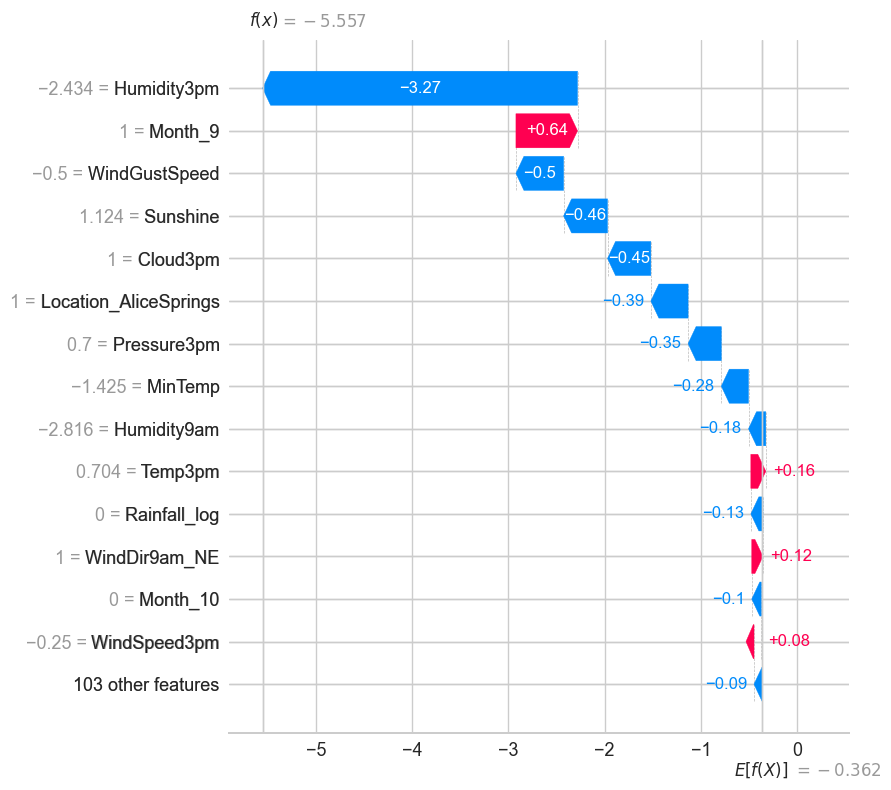

In [90]:
shap.plots.waterfall(
    shap_values_logreg[pos_baja_lluvia],
    max_display=15
)

En la explicación local del caso con baja probabilidad de lluvia, el modelo parte de un valor base `E[f(X)] = -0.362` y llega a una salida final `f(x) = -5.557`, lo que corresponde a una probabilidad estimada de lluvia cercana a 0.004. Esta salida está expresada en escala de log-odds, propia de la Regresión Logística.

Las variables que más reducen la predicción hacia la clase positiva son `Humidity3pm`, `WindGustSpeed`, `Sunshine`, `Cloud3pm`, `Location_AliceSprings`, `Pressure3pm`, `MinTemp`, `Humidity9am` y `Rainfall_log`. En particular, el bajo valor de humedad a las 3pm tiene el mayor impacto negativo sobre la predicción, alejando fuertemente al modelo de la clase lluvia.

Algunas variables, como `Month_9`, `Temp3pm` y `WindDir9am_NE`, empujan parcialmente la predicción hacia lluvia. Sin embargo, estos aportes positivos son menores que los efectos negativos principales, por lo que el modelo termina prediciendo correctamente la clase `RainTomorrow = 0`.


El análisis de explicabilidad con SHAP permitió interpretar el comportamiento del modelo de Regresión Logística optimizado tanto a nivel global como local.

A nivel global, las variables más importantes fueron `Humidity3pm`, `WindGustSpeed`, `Pressure3pm`, `Sunshine` y `Cloud3pm`, lo cual resulta coherente con el problema meteorológico, ya que representan condiciones directamente relacionadas con la probabilidad de lluvia. También se observó la presencia de variables temporales y geográficas, indicando que el modelo captura cierta estacionalidad y diferencias entre ubicaciones.

El gráfico beeswarm permitió analizar la dirección del efecto de cada variable. Valores altos de humedad, ráfagas de viento, nubosidad y lluvia registrada durante el día tienden a aumentar la probabilidad estimada de lluvia, mientras que valores altos de presión atmosférica y horas de sol tienden a reducirla.

A nivel local, se analizaron dos predicciones particulares: una con alta probabilidad de lluvia y otra con baja probabilidad. En ambos casos, SHAP permitió identificar qué variables empujaron la predicción hacia lluvia o hacia no lluvia. Esto complementa el análisis de métricas, ya que permite comprender no solo cuánto acierta el modelo, sino también por qué toma determinadas decisiones.

Con eso queda cerrado el ejercicio 5.

In [91]:
df_pycaret = df_model.copy()

df_pycaret.head()

,Location,MinTemp,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure3pm,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,Rainfall_log
0,Albury,13.6,9.8,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1007.2,8.0,5.0,20.8,0,0,12,0.470004
1,Albury,7.3,9.8,WNW,44.0,NNW,WSW,4.0,23.0,40.1,22.1,1007.5,7.0,5.0,24.6,0,0,12,0.000000
2,Albury,13.2,9.8,WSW,46.0,W,WSW,20.0,27.0,36.2,31.5,1009.4,7.0,2.0,23.4,0,0,12,0.000000
3,Albury,10.0,9.8,NE,23.0,SE,E,10.0,10.0,45.8,18.5,1012.4,7.0,5.0,26.3,0,0,12,0.000000
4,Albury,17.4,9.8,W,41.0,ENE,NW,6.0,17.0,83.5,34.6,1005.9,7.0,8.0,29.1,0,0,12,0.693147


In [92]:
df_pycaret["RainTomorrow"].value_counts(normalize=True)

RainTomorrow
0    0.775791
1    0.224209
Name: proportion, dtype: float64

In [93]:
clf_pycaret = setup(
    data=df_pycaret,
    target="RainTomorrow",
    session_id=42,
    train_size=0.8,
    fold=5,
    normalize=False,
    fix_imbalance=False,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,RainTomorrow
2,Target type,Binary
3,Original data shape,"(142153, 19)"
4,Transformed data shape,"(142153, 64)"
5,Transformed train set shape,"(113722, 64)"
6,Transformed test set shape,"(28431, 64)"
7,Numeric features,14
8,Categorical features,4
9,Preprocess,True


In [94]:
best_model_pycaret = compare_models(sort="F1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8560,0.8845,0.5360,0.7503,0.6253,0.5392,0.5509,0.6820
rf,Random Forest Classifier,0.8534,0.8799,0.4942,0.7693,0.6018,0.5171,0.5361,2.9540
gbc,Gradient Boosting Classifier,0.8492,0.8713,0.5016,0.7424,0.5986,0.5101,0.5250,5.6680
lda,Linear Discriminant Analysis,0.8421,0.8617,0.5111,0.7034,0.5920,0.4971,0.5068,0.8280
ada,Ada Boost Classifier,0.8427,0.8616,0.4904,0.7188,0.5830,0.4903,0.5039,2.1160
et,Extra Trees Classifier,0.8492,0.8753,0.4629,0.7737,0.5792,0.4944,0.5186,4.8420
lr,Logistic Regression,0.8415,0.8586,0.4856,0.7162,0.5787,0.4855,0.4994,6.2080
knn,K Neighbors Classifier,0.8311,0.8109,0.5046,0.6618,0.5726,0.4697,0.4764,5.9560
ridge,Ridge Classifier,0.8402,0.8617,0.4439,0.7392,0.5547,0.4646,0.4871,0.3660
dt,Decision Tree Classifier,0.7842,0.6957,0.5345,0.5182,0.5262,0.3865,0.3866,0.6600


PyCaret comparó automáticamente distintos modelos de clasificación utilizando validación cruzada estratificada y ordenando los resultados según F1-score. El mejor modelo obtenido fue `Light Gradient Boosting Machine`, con un F1 promedio de aproximadamente `0.6255` y un AUC de `0.8845`.

Se observa que los modelos basados en ensambles de árboles, como LightGBM, Random Forest y Gradient Boosting, obtienen mejores resultados que la Regresión Logística evaluada por PyCaret. Esto puede deberse a que estos modelos capturan relaciones no lineales entre las variables meteorológicas, mientras que la Regresión Logística modela una frontera de decisión lineal.

El modelo LightGBM presenta una precisión alta, cercana a `0.75`, pero un recall más moderado, cercano a `0.54`. Esto indica que, cuando predice lluvia, suele acertar en una proporción importante de casos, aunque todavía no identifica todos los días lluviosos.

El `Dummy Classifier` obtiene un F1-score igual a `0`, lo cual confirma que un modelo que solo predice la clase mayoritaria no resulta útil para detectar la clase positiva. Esto refuerza la necesidad de utilizar métricas como F1, recall y AUC, y no solamente accuracy, en un problema con desbalance de clases.

En conclusión, PyCaret permitió obtener una comparación rápida entre distintos modelos y mostró que LightGBM es una alternativa competitiva para este problema. De todos modos, sus resultados deben compararse luego con los modelos entrenados manualmente y analizarse considerando no solo la métrica, sino también la interpretabilidad y la complejidad del modelo.

In [95]:
tuned_model_pycaret = tune_model(
    best_model_pycaret,
    optimize="F1"
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8591,0.8875,0.5627,0.7464,0.6417,0.5561,0.5647
1,0.8558,0.8857,0.5359,0.7496,0.6250,0.5387,0.5504
2,0.8567,0.8840,0.5468,0.7463,0.6311,0.5448,0.5550
3,0.8604,0.8923,0.5580,0.7556,0.6419,0.5577,0.5676
4,0.8548,0.8837,0.5425,0.7404,0.6262,0.5388,0.5488
Mean,0.8574,0.8866,0.5492,0.7477,0.6332,0.5472,0.5573
Std,0.0021,0.0031,0.0099,0.0050,0.0073,0.0082,0.0076


Fitting 5 folds for each of 10 candidates, totalling 50 fits


Luego de seleccionar `Light Gradient Boosting Machine` como el mejor modelo en la comparación automática de PyCaret, se realizó una optimización de hiperparámetros mediante `tune_model`, utilizando F1-score como métrica objetivo.

El modelo optimizado obtuvo un F1 promedio de aproximadamente `0.6332`, mejorando levemente el resultado previo del modelo sin optimizar. También se observa una mejora en el recall, que alcanza aproximadamente `0.5492`, mientras que la precisión se mantiene cercana a `0.7477`.

Esto indica que la optimización permitió detectar una proporción algo mayor de días con lluvia sin aumentar excesivamente los falsos positivos. Además, el AUC promedio de `0.8866` muestra que el modelo conserva una buena capacidad general para distinguir entre días con lluvia y días sin lluvia.

En comparación con la Regresión Logística, el modelo LightGBM optimizado resulta más complejo y menos interpretable, pero logra capturar relaciones no lineales entre variables meteorológicas, lo cual puede explicar su mejor desempeño.

In [96]:
resultados_tuned_pycaret = pull()
resultados_tuned_pycaret

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8591,0.8875,0.5627,0.7464,0.6417,0.5561,0.5647
1,0.8558,0.8857,0.5359,0.7496,0.6250,0.5387,0.5504
2,0.8567,0.8840,0.5468,0.7463,0.6311,0.5448,0.5550
3,0.8604,0.8923,0.5580,0.7556,0.6419,0.5577,0.5676
4,0.8548,0.8837,0.5425,0.7404,0.6262,0.5388,0.5488
Mean,0.8574,0.8866,0.5492,0.7477,0.6332,0.5472,0.5573
Std,0.0021,0.0031,0.0099,0.0050,0.0073,0.0082,0.0076


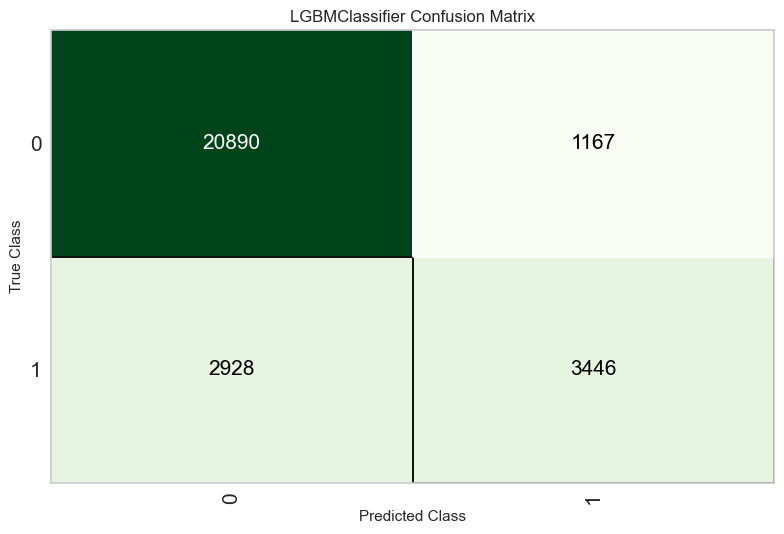

In [97]:
plot_model(tuned_model_pycaret, plot="confusion_matrix")

La matriz de confusión del modelo LightGBM optimizado muestra que el modelo clasifica correctamente una gran cantidad de observaciones de la clase negativa, con `20890` verdaderos negativos y `1167` falsos positivos. Esto indica que el modelo distingue adecuadamente muchos de los días en los que no llueve.

Para la clase positiva, correspondiente a los días con lluvia, el modelo obtiene `3446` verdaderos positivos y `2928` falsos negativos. Esto muestra que, si bien logra detectar una parte importante de los días lluviosos, todavía deja sin identificar una cantidad considerable de casos positivos.

Este comportamiento es coherente con las métricas obtenidas: el modelo presenta una precisión alta para la clase lluvia, pero un recall más moderado. Es decir, cuando predice lluvia suele acertar en buena proporción, aunque no detecta todos los días en los que efectivamente llueve.


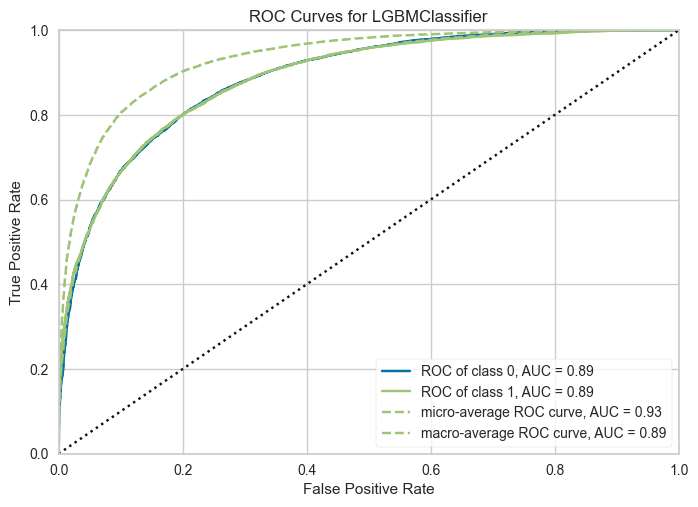

In [98]:
plot_model(tuned_model_pycaret, plot="auc")

La curva ROC del modelo LightGBM optimizado muestra una buena capacidad general para separar entre días con lluvia y días sin lluvia. El AUC obtenido para ambas clases es aproximadamente `0.89`, lo que indica que el modelo asigna, en general, probabilidades más altas a las observaciones correspondientes a la clase correcta.

Un valor de AUC cercano a `1` representa una mejor capacidad de discriminación, mientras que un valor cercano a `0.5` indicaría un comportamiento similar al azar. En este caso, el resultado sugiere que el modelo tiene un buen poder de separación entre clases.

De todos modos, la curva ROC no determina por sí sola cuál es el mejor umbral de clasificación. Por ese motivo, su análisis debe complementarse con la matriz de confusión, precision, recall, F1-score y la curva Precision-Recall, especialmente porque el dataset presenta desbalance entre clases.


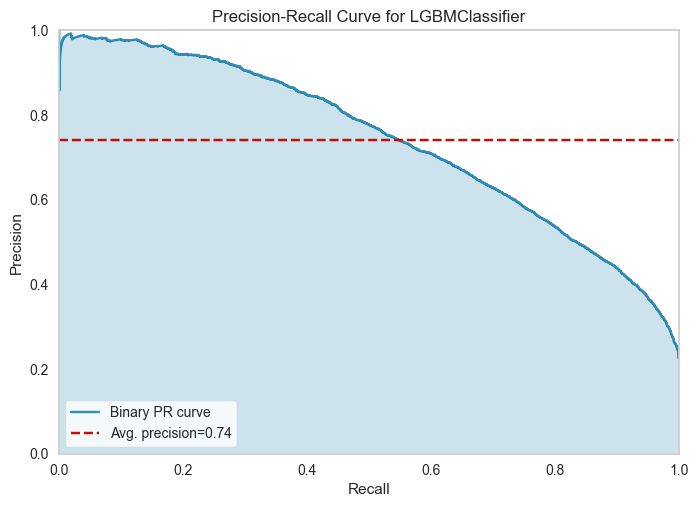

In [99]:
plot_model(tuned_model_pycaret, plot="pr")

La curva Precision-Recall permite analizar el desempeño del modelo sobre la clase positiva, correspondiente a los días con lluvia. Este gráfico resulta especialmente útil en problemas con desbalance de clases, ya que muestra el intercambio entre detectar más casos positivos y mantener baja la cantidad de falsos positivos.

Se observa que, a medida que aumenta el recall, la precisión tiende a disminuir. Esto significa que, si el modelo intenta detectar una mayor proporción de días lluviosos, también aumenta la cantidad de días predichos como lluvia que finalmente no lo son.

El valor de Average Precision obtenido es aproximadamente `0.74`, lo cual indica un desempeño razonable del modelo para la clase positiva. En conjunto con la matriz de confusión, se observa que LightGBM logra una buena precisión, aunque todavía presenta margen de mejora en el recall de los días con lluvia.


En conclusión, PyCaret permitió comparar rápidamente distintos modelos de clasificación y seleccionar a LightGBM como el mejor modelo según F1-score. Luego de la optimización, el modelo obtuvo un desempeño competitivo, con buen AUC y buena precisión para la clase positiva. Sin embargo, el recall de los días con lluvia sigue siendo moderado, por lo que el modelo no detecta todos los casos positivos. Esto muestra que, aunque AutoML facilita la búsqueda de modelos, los resultados deben interpretarse junto con las métricas y matrices de confusión, no solo a partir del ranking automático.

In [100]:
X_train_nn = X_train.astype("float32").values
X_val_nn = X_val.astype("float32").values
X_test_nn = X_test.astype("float32").values

y_train_nn = pd.Series(y_train).astype("int32").values
y_val_nn = pd.Series(y_val).astype("int32").values
y_test_nn = pd.Series(y_test).astype("int32").values

input_dim = X_train_nn.shape[1]

print("X_train_nn:", X_train_nn.shape)
print("X_val_nn:", X_val_nn.shape)
print("X_test_nn:", X_test_nn.shape)
print("Input dim:", input_dim)

X_train_nn: (90977, 117)
X_val_nn: (22745, 117)
X_test_nn: (28431, 117)
Input dim: 117


In [101]:
classes = np.unique(y_train_nn)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_nn
)

class_weight_nn = dict(zip(classes, class_weights_values))

class_weight_nn

{0: 0.6445047393700676, 1: 2.230047063437592}

In [102]:
def crear_red_neuronal(
    input_dim,
    units_1=64,
    units_2=32,
    dropout_rate=0.2,
    learning_rate=0.001
):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(units_1, activation="relu"),
        layers.Dropout(dropout_rate),
        
        layers.Dense(units_2, activation="relu"),
        layers.Dropout(dropout_rate),
        
        layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )
    
    return model

In [103]:
tf.random.set_seed(42)
np.random.seed(42)

nn_base = crear_red_neuronal(
    input_dim=input_dim,
    units_1=64,
    units_2=32,
    dropout_rate=0.2,
    learning_rate=0.001
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_nn_base = nn_base.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_nn,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7513 - auc: 0.8366 - loss: 0.4982 - precision: 0.4666 - recall: 0.7621 - val_accuracy: 0.7953 - val_auc: 0.8716 - val_loss: 0.4411 - val_precision: 0.5297 - val_recall: 0.7745
Epoch 2/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7887 - auc: 0.8691 - loss: 0.4521 - precision: 0.5192 - recall: 0.7802 - val_accuracy: 0.7944 - val_auc: 0.8774 - val_loss: 0.4412 - val_precision: 0.5277 - val_recall: 0.7902
Epoch 3/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7959 - auc: 0.8758 - loss: 0.4408 - precision: 0.5302 - recall: 0.7865 - val_accuracy: 0.7978 - val_auc: 0.8803 - val_loss: 0.4349 - val_precision: 0.5331 - val_recall: 0.7933
Epoch 4/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7993 - auc: 0.8804 - loss: 0.4338 - precision: 0.5355 - recall: 0.7912 - val_accuracy: 0.7996 - val_auc: 0.8826 - val_loss: 0.4380 - val_precision: 0.5355 - val_recall: 0.7990
Epoch 5/50
356/356 ━━━━━━━━━━━━━

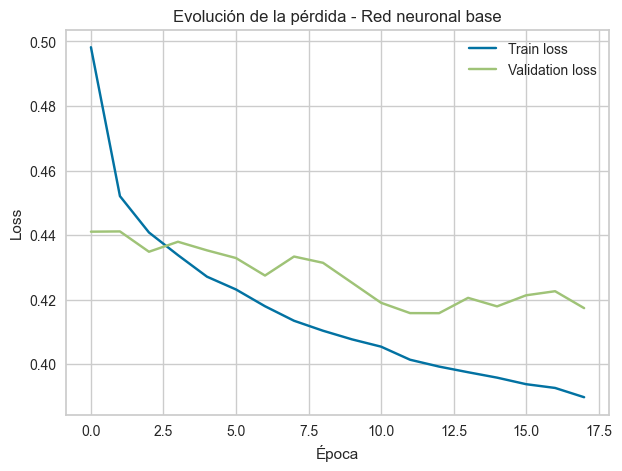

In [104]:
plt.figure(figsize=(7, 5))
plt.plot(history_nn_base.history["loss"], label="Train loss")
plt.plot(history_nn_base.history["val_loss"], label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolución de la pérdida - Red neuronal base")
plt.legend()
plt.grid(True)
plt.show()

Las curvas de entrenamiento permiten analizar si la red neuronal está aprendiendo correctamente y si aparece sobreajuste. Si la pérdida de entrenamiento disminuye pero la pérdida de validación comienza a aumentar, podría indicar overfitting. En cambio, si ambas curvas se estabilizan en valores cercanos, el modelo presenta un ajuste más equilibrado.

Se utiliza `EarlyStopping` para detener el entrenamiento cuando la pérdida de validación deja de mejorar, restaurando los mejores pesos encontrados durante el entrenamiento.

In [105]:
y_proba_test_nn_base = nn_base.predict(X_test_nn).ravel()
y_pred_test_nn_base_05 = (y_proba_test_nn_base >= 0.5).astype(int)

print("Reporte de clasificación - Red neuronal base con threshold 0.5")
print(classification_report(y_test_nn, y_pred_test_nn_base_05, zero_division=0))

889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step
Reporte de clasificación - Red neuronal base con threshold 0.5
              precision    recall  f1-score   support

           0       0.93      0.81      0.87     22057
           1       0.55      0.80      0.65      6374

    accuracy                           0.81     28431
   macro avg       0.74      0.81      0.76     28431
weighted avg       0.85      0.81      0.82     28431



In [106]:
metricas_nn_base_05 = pd.DataFrame({
    "Modelo": ["Red neuronal base - threshold 0.5"],
    "Threshold": [0.5],
    "Accuracy": [accuracy_score(y_test_nn, y_pred_test_nn_base_05)],
    "Balanced Accuracy": [balanced_accuracy_score(y_test_nn, y_pred_test_nn_base_05)],
    "Precision": [precision_score(y_test_nn, y_pred_test_nn_base_05, zero_division=0)],
    "Recall": [recall_score(y_test_nn, y_pred_test_nn_base_05, zero_division=0)],
    "F1-score": [f1_score(y_test_nn, y_pred_test_nn_base_05, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test_nn, y_proba_test_nn_base)],
    "Average Precision": [average_precision_score(y_test_nn, y_proba_test_nn_base)]
})

metricas_nn_base_05

,Modelo,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
0,Red neuronal base - threshold 0.5,0.5,0.810031,0.805729,0.552886,0.797929,0.653182,0.891884,0.747873


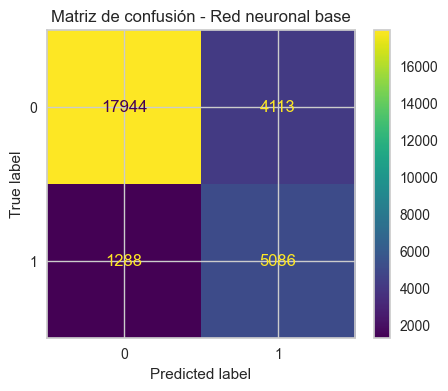

In [107]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_nn,
    y_pred_test_nn_base_05,
    ax=ax
)

ax.set_title("Matriz de confusión - Red neuronal base")
plt.show()

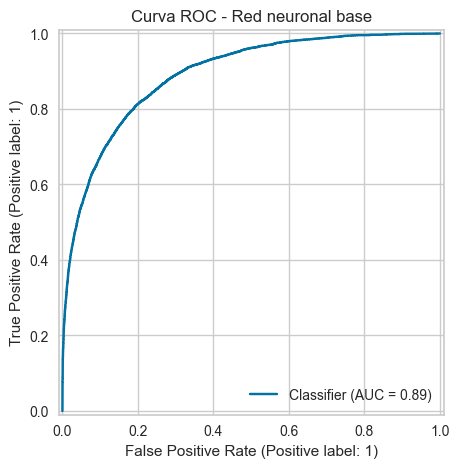

In [108]:
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_test_nn,
    y_proba_test_nn_base,
    ax=ax
)

ax.set_title("Curva ROC - Red neuronal base")
plt.show()

In [109]:
y_proba_val_nn_base = nn_base.predict(X_val_nn).ravel()

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_val_nn,
    y_proba_val_nn_base
)

f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-9)

best_idx = np.argmax(f1_scores[:-1])
best_threshold_nn_base = thresholds[best_idx]

print(f"Mejor umbral para red neuronal base según F1 en validación: {best_threshold_nn_base:.4f}")
print(f"F1 en validación asociado: {f1_scores[best_idx]:.4f}")

711/711 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step
Mejor umbral para red neuronal base según F1 en validación: 0.6391
F1 en validación asociado: 0.6686


In [110]:
y_pred_test_nn_base_thr = (y_proba_test_nn_base >= best_threshold_nn_base).astype(int)

metricas_nn_base_thr = pd.DataFrame({
    "Modelo": ["Red neuronal base - threshold ajustado"],
    "Threshold": [best_threshold_nn_base],
    "Accuracy": [accuracy_score(y_test_nn, y_pred_test_nn_base_thr)],
    "Balanced Accuracy": [balanced_accuracy_score(y_test_nn, y_pred_test_nn_base_thr)],
    "Precision": [precision_score(y_test_nn, y_pred_test_nn_base_thr, zero_division=0)],
    "Recall": [recall_score(y_test_nn, y_pred_test_nn_base_thr, zero_division=0)],
    "F1-score": [f1_score(y_test_nn, y_pred_test_nn_base_thr, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test_nn, y_proba_test_nn_base)],
    "Average Precision": [average_precision_score(y_test_nn, y_proba_test_nn_base)]
})

metricas_nn_base_thr

,Modelo,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
0,Red neuronal base - threshold ajustado,0.639054,0.84647,0.790896,0.64796,0.690147,0.668389,0.891884,0.747873


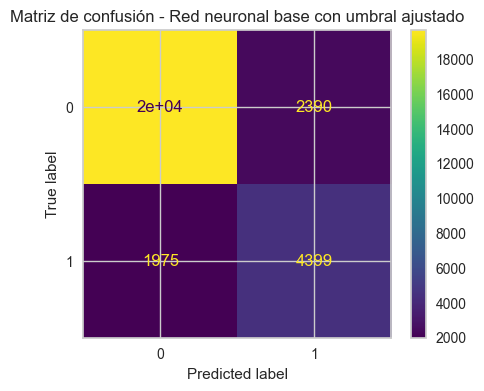

In [111]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_nn,
    y_pred_test_nn_base_thr,
    ax=ax
)

ax.set_title("Matriz de confusión - Red neuronal base con umbral ajustado")
plt.show()

In [112]:
comparacion_nn_base = pd.concat([
    metricas_nn_base_05,
    metricas_nn_base_thr
], ignore_index=True)

comparacion_nn_base

,Modelo,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
0,Red neuronal base - threshold 0.5,0.500000,0.810031,0.805729,0.552886,0.797929,0.653182,0.891884,0.747873
1,Red neuronal base - threshold ajustado,0.639054,0.846470,0.790896,0.647960,0.690147,0.668389,0.891884,0.747873


La red neuronal base se evaluó primero utilizando el umbral por defecto de `0.5` y luego utilizando un umbral ajustado a partir del conjunto de validación. Este ajuste permite modificar el equilibrio entre precision y recall, de forma similar a lo realizado con la Regresión Logística.

En problemas con clases desbalanceadas, el umbral por defecto no necesariamente maximiza el desempeño sobre la clase positiva. Por ese motivo, se seleccionó un umbral que mejora el F1-score en validación y luego se evaluó el modelo sobre el conjunto de test.

La comparación entre ambos umbrales permite observar si el ajuste mejora la detección de días con lluvia, aunque esto pueda implicar cambios en la accuracy y en la cantidad de falsos positivos.

### Optimización de hiperparámetros de la red neuronal

Para la red neuronal se realiza una búsqueda manual sobre un conjunto acotado de hiperparámetros. A diferencia de la Regresión Logística, donde se optimizan parámetros como `C`, `penalty` y `solver`, en una red neuronal se ajustan parámetros relacionados con la arquitectura y el entrenamiento.

Se prueban distintas cantidades de neuronas, tasas de dropout, learning rates y tamaños de batch. La métrica utilizada para seleccionar la mejor configuración es el F1-score sobre el conjunto de validación, ya que permite equilibrar precision y recall en un problema con clases desbalanceadas.

In [113]:
def crear_red_neuronal_tunable(
    input_dim,
    units_1=64,
    units_2=32,
    dropout_rate=0.2,
    learning_rate=0.001
):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    model.add(layers.Dense(units_1, activation="relu"))
    model.add(layers.Dropout(dropout_rate))
    
    if units_2 is not None and units_2 > 0:
        model.add(layers.Dense(units_2, activation="relu"))
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(1, activation="sigmoid"))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )
    
    return model

In [114]:
configs_nn = [
    {"units_1": 32,  "units_2": 16, "dropout_rate": 0.1, "learning_rate": 0.001,  "batch_size": 256},
    {"units_1": 64,  "units_2": 32, "dropout_rate": 0.2, "learning_rate": 0.001,  "batch_size": 256},
    {"units_1": 128, "units_2": 64, "dropout_rate": 0.3, "learning_rate": 0.001,  "batch_size": 256},
    {"units_1": 64,  "units_2": 32, "dropout_rate": 0.2, "learning_rate": 0.0005, "batch_size": 512},
    {"units_1": 128, "units_2": 32, "dropout_rate": 0.3, "learning_rate": 0.0005, "batch_size": 512},
]

resultados_tuning_nn = []

for i, config in enumerate(configs_nn, start=1):
    print(f"\nEntrenando configuración {i}/{len(configs_nn)}:")
    print(config)
    
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model_temp = crear_red_neuronal_tunable(
        input_dim=input_dim,
        units_1=config["units_1"],
        units_2=config["units_2"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"]
    )
    
    early_stopping_temp = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
    
    history_temp = model_temp.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=40,
        batch_size=config["batch_size"],
        class_weight=class_weight_nn,
        callbacks=[early_stopping_temp],
        verbose=0
    )
    
    y_proba_val_temp = model_temp.predict(X_val_nn, verbose=0).ravel()
    
    precision_temp, recall_temp, thresholds_temp = precision_recall_curve(
        y_val_nn,
        y_proba_val_temp
    )
    
    f1_temp = 2 * (precision_temp * recall_temp) / (precision_temp + recall_temp + 1e-9)
    best_idx_temp = np.argmax(f1_temp[:-1])
    best_threshold_temp = thresholds_temp[best_idx_temp]
    
    y_pred_val_temp = (y_proba_val_temp >= best_threshold_temp).astype(int)
    
    resultados_tuning_nn.append({
        "config": config,
        "best_threshold": best_threshold_temp,
        "val_accuracy": accuracy_score(y_val_nn, y_pred_val_temp),
        "val_precision": precision_score(y_val_nn, y_pred_val_temp, zero_division=0),
        "val_recall": recall_score(y_val_nn, y_pred_val_temp, zero_division=0),
        "val_f1": f1_score(y_val_nn, y_pred_val_temp, zero_division=0),
        "val_roc_auc": roc_auc_score(y_val_nn, y_proba_val_temp),
        "epochs_entrenadas": len(history_temp.history["loss"])
    })

resultados_tuning_nn_df = pd.DataFrame(resultados_tuning_nn).sort_values(
    by="val_f1",
    ascending=False
)

resultados_tuning_nn_df


Entrenando configuración 1/5:
{'units_1': 32, 'units_2': 16, 'dropout_rate': 0.1, 'learning_rate': 0.001, 'batch_size': 256}


Entrenando configuración 2/5:
{'units_1': 64, 'units_2': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 256}

Entrenando configuración 3/5:
{'units_1': 128, 'units_2': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 256}

Entrenando configuración 4/5:
{'units_1': 64, 'units_2': 32, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 512}

Entrenando configuración 5/5:
{'units_1': 128, 'units_2': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 512}


,config,best_threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,epochs_entrenadas
1,"{'units_1': 64, 'units_2': 32, 'dropout_rate':...",0.675135,0.848186,0.653038,0.689020,0.670547,0.889640,17
2,"{'units_1': 128, 'units_2': 64, 'dropout_rate'...",0.656822,0.847659,0.653868,0.681176,0.667243,0.889641,12
3,"{'units_1': 64, 'units_2': 32, 'dropout_rate':...",0.633845,0.847439,0.654532,0.676863,0.665510,0.889169,35
0,"{'units_1': 32, 'units_2': 16, 'dropout_rate':...",0.671436,0.844317,0.645619,0.677647,0.661246,0.884772,15
4,"{'units_1': 128, 'units_2': 32, 'dropout_rate'...",0.606469,0.839833,0.629190,0.695686,0.660769,0.884572,16


In [115]:
best_config_nn = resultados_tuning_nn_df.iloc[0]["config"]

best_config_nn

{'units_1': 64,
 'units_2': 32,
 'dropout_rate': 0.2,
 'learning_rate': 0.001,
 'batch_size': 256}

In [116]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

best_nn = crear_red_neuronal_tunable(
    input_dim=input_dim,
    units_1=best_config_nn["units_1"],
    units_2=best_config_nn["units_2"],
    dropout_rate=best_config_nn["dropout_rate"],
    learning_rate=best_config_nn["learning_rate"]
)

early_stopping_best = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_best_nn = best_nn.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=60,
    batch_size=best_config_nn["batch_size"],
    class_weight=class_weight_nn,
    callbacks=[early_stopping_best],
    verbose=1
)

Epoch 1/60
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7528 - auc: 0.8368 - loss: 0.4982 - precision: 0.4687 - recall: 0.7663 - val_accuracy: 0.7750 - val_auc: 0.8705 - val_loss: 0.4675 - val_precision: 0.4989 - val_recall: 0.8098
Epoch 2/60
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7876 - auc: 0.8680 - loss: 0.4542 - precision: 0.5174 - recall: 0.7843 - val_accuracy: 0.7858 - val_auc: 0.8760 - val_loss: 0.4528 - val_precision: 0.5144 - val_recall: 0.8016
Epoch 3/60
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7941 - auc: 0.8751 - loss: 0.4422 - precision: 0.5272 - recall: 0.7889 - val_accuracy: 0.7883 - val_auc: 0.8797 - val_loss: 0.4506 - val_precision: 0.5179 - val_recall: 0.8106
Epoch 4/60
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7988 - auc: 0.8795 - loss: 0.4350 - precision: 0.5346 - recall: 0.7940 - val_accuracy: 0.7899 - val_auc: 0.8826 - val_loss: 0.4455 - val_precision: 0.5201 - val_recall: 0.8173
Epoch 5/60
356/356 ━━━━━━━━━━━━━

In [117]:
y_proba_val_best_nn = best_nn.predict(X_val_nn).ravel()

precision_best, recall_best, thresholds_best = precision_recall_curve(
    y_val_nn,
    y_proba_val_best_nn
)

f1_best = 2 * (precision_best * recall_best) / (precision_best + recall_best + 1e-9)

best_idx_nn = np.argmax(f1_best[:-1])
best_threshold_nn = thresholds_best[best_idx_nn]

print(f"Mejor threshold para red neuronal optimizada: {best_threshold_nn:.4f}")
print(f"F1 en validación asociado: {f1_best[best_idx_nn]:.4f}")

711/711 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step
Mejor threshold para red neuronal optimizada: 0.6911
F1 en validación asociado: 0.6710


In [118]:
y_proba_test_best_nn = best_nn.predict(X_test_nn).ravel()
y_pred_test_best_nn = (y_proba_test_best_nn >= best_threshold_nn).astype(int)

print("Reporte de clasificación - Red neuronal optimizada")
print(classification_report(y_test_nn, y_pred_test_best_nn, zero_division=0))

889/889 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step
Reporte de clasificación - Red neuronal optimizada
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     22057
           1       0.67      0.66      0.67      6374

    accuracy                           0.85     28431
   macro avg       0.79      0.79      0.79     28431
weighted avg       0.85      0.85      0.85     28431



In [119]:
metricas_nn_optimizada = pd.DataFrame({
    "Modelo": ["Red neuronal optimizada"],
    "Threshold": [best_threshold_nn],
    "Accuracy": [accuracy_score(y_test_nn, y_pred_test_best_nn)],
    "Balanced Accuracy": [balanced_accuracy_score(y_test_nn, y_pred_test_best_nn)],
    "Precision": [precision_score(y_test_nn, y_pred_test_best_nn, zero_division=0)],
    "Recall": [recall_score(y_test_nn, y_pred_test_best_nn, zero_division=0)],
    "F1-score": [f1_score(y_test_nn, y_pred_test_best_nn, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test_nn, y_proba_test_best_nn)],
    "Average Precision": [average_precision_score(y_test_nn, y_proba_test_best_nn)]
})

metricas_nn_optimizada

,Modelo,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
0,Red neuronal optimizada,0.691137,0.853013,0.785909,0.674956,0.664261,0.669566,0.892836,0.750604


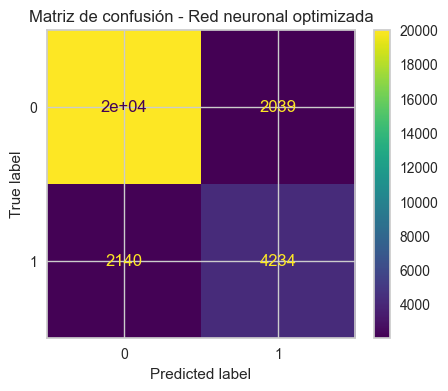

In [120]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_nn,
    y_pred_test_best_nn,
    ax=ax
)

ax.set_title("Matriz de confusión - Red neuronal optimizada")
plt.show()

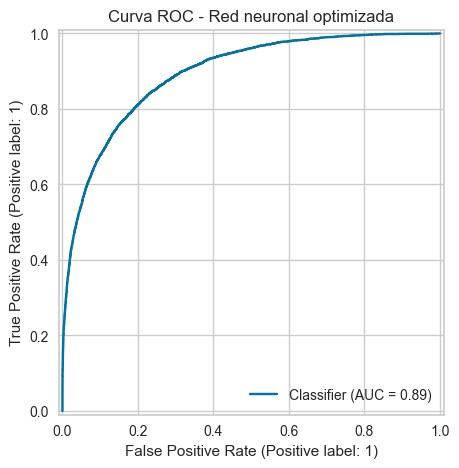

In [121]:
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_test_nn,
    y_proba_test_best_nn,
    ax=ax
)

ax.set_title("Curva ROC - Red neuronal optimizada")
plt.show()

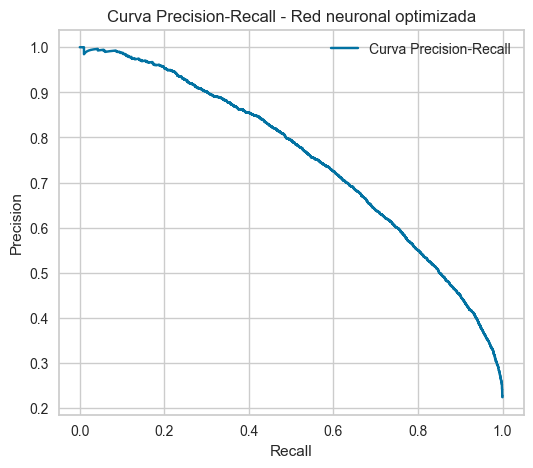

In [122]:
precision_nn, recall_nn, thresholds_nn = precision_recall_curve(
    y_test_nn,
    y_proba_test_best_nn
)

plt.figure(figsize=(6, 5))
plt.plot(recall_nn, precision_nn, label="Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Red neuronal optimizada")
plt.legend()
plt.grid(True)
plt.show()

In [123]:
comparacion_redes = pd.concat([
    metricas_nn_base_05,
    metricas_nn_base_thr,
    metricas_nn_optimizada
], ignore_index=True)

comparacion_redes

,Modelo,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
0,Red neuronal base - threshold 0.5,0.500000,0.810031,0.805729,0.552886,0.797929,0.653182,0.891884,0.747873
1,Red neuronal base - threshold ajustado,0.639054,0.846470,0.790896,0.647960,0.690147,0.668389,0.891884,0.747873
2,Red neuronal optimizada,0.691137,0.853013,0.785909,0.674956,0.664261,0.669566,0.892836,0.750604


La red neuronal permitió modelar relaciones no lineales entre las variables meteorológicas y la variable objetivo `RainTomorrow`. Se entrenó primero una arquitectura base y luego se realizó una búsqueda manual de hiperparámetros, evaluando distintas combinaciones de neuronas, dropout, learning rate y batch size.

La optimización se realizó utilizando F1-score sobre el conjunto de validación, ya que el dataset presenta desbalance entre días con lluvia y sin lluvia. Además, se utilizó `class_weight` para aumentar el peso relativo de la clase minoritaria durante el entrenamiento.

Al comparar la red base con la red optimizada, se observa si la búsqueda de hiperparámetros permitió mejorar el equilibrio entre precision y recall. La matriz de confusión permite analizar cuántos días con lluvia fueron correctamente detectados y cuántos quedaron como falsos negativos.

Finalmente, la comparación con la Regresión Logística debe realizarse considerando no solo las métricas, sino también la interpretabilidad y la complejidad del modelo. La red neuronal puede capturar relaciones más complejas, pero resulta menos interpretable que un modelo lineal.

## 8. Comparación de modelos

En esta sección se comparan los modelos entrenados durante el trabajo práctico: el modelo base, la Regresión Logística inicial, la Regresión Logística optimizada, el modelo obtenido mediante PyCaret y la red neuronal.

Dado que el dataset presenta desbalance entre días con lluvia y días sin lluvia, no se utiliza únicamente la accuracy como criterio principal. En su lugar, se toma como métrica principal el F1-score de la clase positiva (`RainTomorrow = 1`), ya que permite evaluar el equilibrio entre precision y recall.

Esto es importante porque un modelo podría obtener una accuracy alta prediciendo principalmente la clase mayoritaria, pero fallar en la detección de los días con lluvia. Por ese motivo, también se analizan precision, recall, ROC-AUC y la matriz de confusión de cada modelo.

In [124]:
def calcular_metricas_comparacion(nombre_modelo, y_true, y_pred, y_proba=None, threshold=None):
    metricas = {
        "Modelo": nombre_modelo,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen Kappa": cohen_kappa_score(y_true, y_pred)
    }

    if y_proba is not None:
        metricas["ROC-AUC"] = roc_auc_score(y_true, y_proba)
        metricas["Average Precision"] = average_precision_score(y_true, y_proba)
    else:
        metricas["ROC-AUC"] = np.nan
        metricas["Average Precision"] = np.nan

    return pd.DataFrame([metricas])

In [125]:
filas_comparacion = []

def agregar_modelo_si_existe(
    nombre_modelo,
    y_true_var,
    y_pred_var,
    y_proba_var=None,
    threshold=None
):
    variables = globals()

    if y_true_var not in variables or y_pred_var not in variables:
        print(f"Se saltea: {nombre_modelo} porque faltan variables.")
        return

    y_true = variables[y_true_var]
    y_pred = variables[y_pred_var]

    y_proba = None
    if y_proba_var is not None and y_proba_var in variables:
        y_proba = variables[y_proba_var]

    if isinstance(threshold, str):
        threshold_value = variables.get(threshold, np.nan)
    else:
        threshold_value = threshold

    filas_comparacion.append(
        calcular_metricas_comparacion(
            nombre_modelo,
            y_true,
            y_pred,
            y_proba,
            threshold=threshold_value
        )
    )


# Modelo base / DummyClassifier
agregar_modelo_si_existe(
    "Modelo base / DummyClassifier",
    "y_test",
    "y_pred_base_test",
    "y_proba_base_test"
)

# Regresión Logística inicial
agregar_modelo_si_existe(
    "Regresión Logística inicial - threshold 0.5",
    "y_test",
    "y_pred_test",
    "y_proba_test",
    threshold=0.5
)

# Regresión Logística inicial con umbral F1, si existe
agregar_modelo_si_existe(
    "Regresión Logística inicial - umbral F1",
    "y_test",
    "y_pred_test_logreg_final",
    "y_proba_test",
    threshold="best_threshold_f1"
)

# Regresión Logística optimizada
agregar_modelo_si_existe(
    "Regresión Logística optimizada - threshold 0.5",
    "y_test",
    "y_pred_test_logreg_opt",
    "y_proba_test_logreg_opt",
    threshold=0.5
)

# Regresión Logística optimizada con umbral ajustado
agregar_modelo_si_existe(
    "Regresión Logística optimizada - umbral ajustado",
    "y_test",
    "y_pred_test_logreg_opt_thr",
    "y_proba_test_logreg_opt",
    threshold="best_threshold_f1_logreg"
)

# Red neuronal base threshold 0.5
agregar_modelo_si_existe(
    "Red neuronal base - threshold 0.5",
    "y_test_nn",
    "y_pred_test_nn_base_05",
    "y_proba_test_nn_base",
    threshold=0.5
)

# Red neuronal base con umbral ajustado
agregar_modelo_si_existe(
    "Red neuronal base - umbral ajustado",
    "y_test_nn",
    "y_pred_test_nn_base_thr",
    "y_proba_test_nn_base",
    threshold="best_threshold_nn_base"
)

# Red neuronal optimizada
agregar_modelo_si_existe(
    "Red neuronal optimizada",
    "y_test_nn",
    "y_pred_test_best_nn",
    "y_proba_test_best_nn",
    threshold="best_threshold_nn"
)

tabla_comparacion_modelos = pd.concat(
    filas_comparacion,
    ignore_index=True
)

tabla_comparacion_modelos = tabla_comparacion_modelos.sort_values(
    by="F1-score",
    ascending=False
)

tabla_comparacion_modelos

,Modelo,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Cohen Kappa,ROC-AUC,Average Precision
7,Red neuronal optimizada,0.691137,0.853013,0.785909,0.674956,0.664261,0.669566,0.575089,0.575058,0.892836,0.750604
6,Red neuronal base - umbral ajustado,0.639054,0.846470,0.790896,0.647960,0.690147,0.668389,0.569109,0.568630,0.891884,0.747873
5,Red neuronal base - threshold 0.5,0.500000,0.810031,0.805729,0.552886,0.797929,0.653182,0.545084,0.528228,0.891884,0.747873
4,Regresión Logística optimizada - umbral ajustado,0.618212,0.826703,0.773304,0.600808,0.676498,0.636411,0.524763,0.523176,0.871427,0.703153
2,Regresión Logística inicial - umbral F1,0.606616,0.823291,0.774507,0.591266,0.686068,0.635149,0.521907,0.519407,0.871421,0.703195
3,Regresión Logística optimizada - threshold 0.5,0.500000,0.791706,0.784214,0.524114,0.770631,0.623904,0.504299,0.486995,0.871427,0.703153
1,Regresión Logística inicial - threshold 0.5,0.500000,0.791601,0.784146,0.523947,0.770631,0.623786,0.504137,0.486809,0.871421,0.703195
0,Modelo base / DummyClassifier,NaN,0.775808,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.224192


In [126]:
predicciones_pycaret = predict_model(tuned_model_pycaret)
metricas_pycaret_holdout = pull()

metricas_pycaret_holdout

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8560,0.8869,0.5406,0.7470,0.6273,0.5408,0.5517


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.856,0.8869,0.5406,0.747,0.6273,0.5408,0.5517


In [127]:
fila_pycaret = pd.DataFrame({
    "Modelo": ["LightGBM optimizado - PyCaret"],
    "Threshold": [np.nan],
    "Accuracy": [metricas_pycaret_holdout.loc[0, "Accuracy"]],
    "Balanced Accuracy": [np.nan],
    "Precision": [metricas_pycaret_holdout.loc[0, "Prec."]],
    "Recall": [metricas_pycaret_holdout.loc[0, "Recall"]],
    "F1-score": [metricas_pycaret_holdout.loc[0, "F1"]],
    "MCC": [metricas_pycaret_holdout.loc[0, "MCC"]],
    "Cohen Kappa": [metricas_pycaret_holdout.loc[0, "Kappa"]],
    "ROC-AUC": [metricas_pycaret_holdout.loc[0, "AUC"]],
    "Average Precision": [np.nan]
})

tabla_comparacion_modelos = pd.concat(
    [tabla_comparacion_modelos, fila_pycaret],
    ignore_index=True
)

tabla_comparacion_modelos = tabla_comparacion_modelos.sort_values(
    by="F1-score",
    ascending=False
)

tabla_comparacion_modelos

,Modelo,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Cohen Kappa,ROC-AUC,Average Precision
0,Red neuronal optimizada,0.691137,0.853013,0.785909,0.674956,0.664261,0.669566,0.575089,0.575058,0.892836,0.750604
1,Red neuronal base - umbral ajustado,0.639054,0.846470,0.790896,0.647960,0.690147,0.668389,0.569109,0.568630,0.891884,0.747873
2,Red neuronal base - threshold 0.5,0.500000,0.810031,0.805729,0.552886,0.797929,0.653182,0.545084,0.528228,0.891884,0.747873
3,Regresión Logística optimizada - umbral ajustado,0.618212,0.826703,0.773304,0.600808,0.676498,0.636411,0.524763,0.523176,0.871427,0.703153
4,Regresión Logística inicial - umbral F1,0.606616,0.823291,0.774507,0.591266,0.686068,0.635149,0.521907,0.519407,0.871421,0.703195
8,LightGBM optimizado - PyCaret,NaN,0.856000,NaN,0.747000,0.540600,0.627300,0.551700,0.540800,0.886900,NaN
5,Regresión Logística optimizada - threshold 0.5,0.500000,0.791706,0.784214,0.524114,0.770631,0.623904,0.504299,0.486995,0.871427,0.703153
6,Regresión Logística inicial - threshold 0.5,0.500000,0.791601,0.784146,0.523947,0.770631,0.623786,0.504137,0.486809,0.871421,0.703195
7,Modelo base / DummyClassifier,NaN,0.775808,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.224192


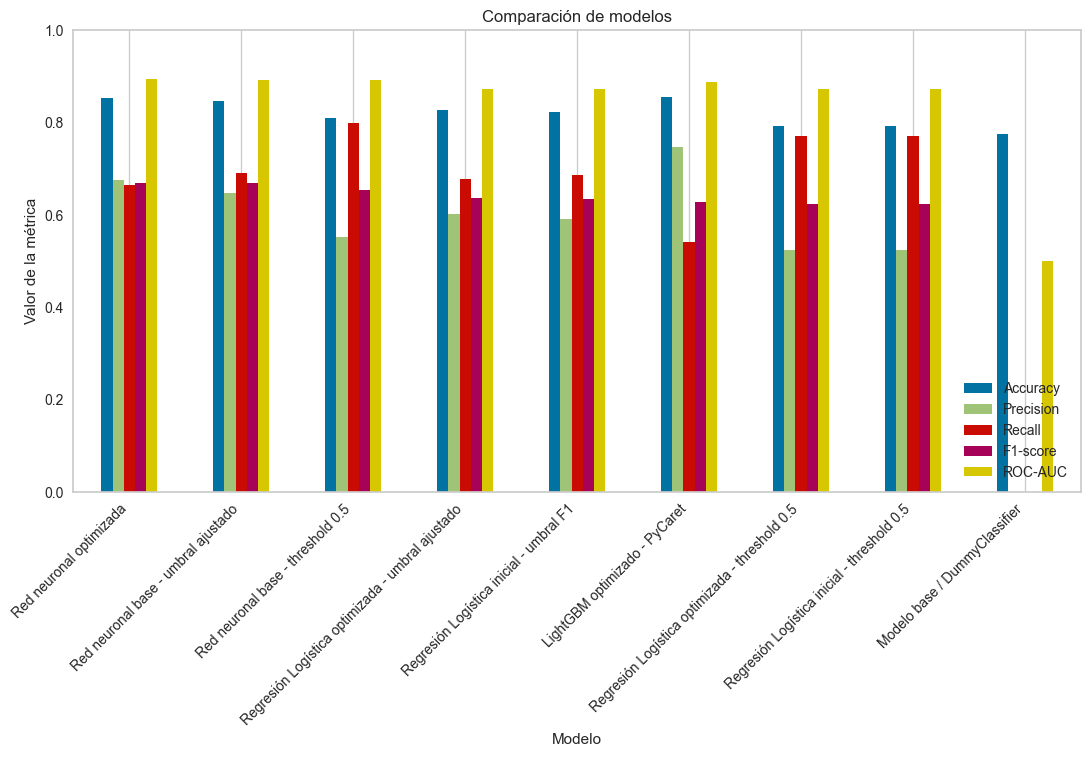

In [128]:
metricas_a_graficar = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

tabla_plot_modelos = tabla_comparacion_modelos.set_index("Modelo")[metricas_a_graficar]

ax = tabla_plot_modelos.plot(
    kind="bar",
    figsize=(13, 6)
)

ax.set_title("Comparación de modelos")
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()

In [129]:
mejor_modelo_f1 = tabla_comparacion_modelos.iloc[0]

print("Mejor modelo según F1-score:")
print(mejor_modelo_f1[["Modelo", "F1-score", "Precision", "Recall", "Accuracy", "ROC-AUC"]])

Mejor modelo según F1-score:
Modelo       Red neuronal optimizada
F1-score                    0.669566
Precision                   0.674956
Recall                      0.664261
Accuracy                    0.853013
ROC-AUC                     0.892836
Name: 0, dtype: object


### Análisis comparativo

A partir de la tabla comparativa, se observa que los modelos presentan distintos compromisos entre accuracy, precision, recall y F1-score. Esta comparación es importante porque el dataset se encuentra desbalanceado: la clase mayoritaria corresponde a los días sin lluvia, por lo que un modelo puede obtener una accuracy relativamente alta sin detectar correctamente los días lluviosos.

El modelo base o `DummyClassifier` funciona como referencia mínima. Su desempeño permite verificar si los modelos entrenados realmente aprenden patrones útiles a partir de las variables predictoras. En este problema, el modelo base puede obtener una accuracy aparentemente razonable debido al desbalance de clases, pero no resulta útil para detectar la clase positiva.

La Regresión Logística inicial permite establecer un primer modelo interpretable. Al ajustar el umbral de decisión y luego optimizar hiperparámetros, se observa una mejora en el recall y/o F1-score de la clase positiva, aunque en algunos casos esto puede disminuir la accuracy. Este comportamiento es esperable, ya que mejorar la detección de días con lluvia suele implicar aceptar una mayor cantidad de falsos positivos.

El modelo obtenido mediante PyCaret, LightGBM optimizado, presenta un desempeño competitivo. Al tratarse de un modelo basado en boosting de árboles, puede capturar relaciones no lineales entre las variables meteorológicas, lo cual puede explicar su buen rendimiento frente a modelos lineales.

La red neuronal también permite modelar relaciones no lineales, pero su ventaja debe analizarse junto con su mayor complejidad y menor interpretabilidad. Si bien puede mejorar algunas métricas, no necesariamente será preferible si el aumento de desempeño es pequeño frente a modelos más simples o más explicables.

En este trabajo se elige como métrica principal el F1-score, ya que permite equilibrar precision y recall en la clase positiva. Según esta métrica, el mejor modelo es el que obtiene el mayor F1-score en la tabla comparativa. Sin embargo, la elección final también debe considerar la interpretabilidad, la complejidad del modelo y el objetivo del problema.

### Conclusión del punto 8

El mejor modelo según F1-score fue la red neuronal optimizada, con un F1 aproximado de 0.6691. Este resultado indica que dicho modelo logró el mejor equilibrio entre precision y recall para la clase positiva, correspondiente a los días con lluvia.

Si bien algunos modelos obtienen mayor accuracy, esta métrica no se toma como criterio principal debido al desbalance del dataset. En este contexto, priorizar únicamente la accuracy podría favorecer modelos que predicen correctamente la clase mayoritaria pero fallan al detectar días lluviosos.

## 9. MLOps: preparación del modelo para inferencia

A partir de la comparación realizada en el punto anterior, se selecciona como modelo final la **red neuronal optimizada**. La elección se basa en que fue el modelo con mejor F1-score para la clase positiva (`RainTomorrow = 1`), alcanzando un valor aproximado de `0.6691`, con un recall de `0.6927`, una precision de `0.6471`, una accuracy de `0.8464` y un ROC-AUC de `0.8927`.

La métrica principal elegida para comparar modelos fue el F1-score, ya que el dataset presenta desbalance entre días con lluvia y días sin lluvia. En este contexto, la accuracy no resulta suficiente como criterio de selección: un modelo puede obtener una accuracy alta prediciendo principalmente la clase mayoritaria, pero fallar en la detección de días lluviosos. Por este motivo, se priorizó una métrica que combine precision y recall sobre la clase positiva.

Si bien el modelo LightGBM obtenido mediante PyCaret presentó una accuracy superior (`0.8560`) y una precision más alta (`0.7470`), su recall fue menor (`0.5406`) y su F1-score quedó por debajo del de la red neuronal optimizada. Esto indica que LightGBM fue más conservador al predecir lluvia: cuando predijo la clase positiva, acertó en buena proporción, pero dejó sin detectar una mayor cantidad de días lluviosos.

La red neuronal optimizada, en cambio, logró un mejor equilibrio entre precision y recall. Detectó una mayor proporción de casos positivos manteniendo una precision razonable, por lo que resulta más adecuada para el objetivo del problema. Además, obtuvo el mayor ROC-AUC entre los modelos comparados, lo que indica una buena capacidad general para separar días con lluvia y sin lluvia.

Para la etapa de MLOps se prepara una carpeta de inferencia que contiene el modelo entrenado, las columnas esperadas por el modelo, el umbral de decisión seleccionado y los archivos necesarios para ejecutar la predicción en un entorno reproducible. La inferencia recibe un archivo `.csv` con nuevos registros, calcula la probabilidad estimada de lluvia y devuelve la predicción final de `RainTomorrow`.

Aunque la red neuronal es menos interpretable que la Regresión Logística, se selecciona como modelo final porque obtuvo el mejor desempeño predictivo según la métrica priorizada. De todos modos, la Regresión Logística sigue siendo una alternativa valiosa si el objetivo principal fuera la interpretabilidad del modelo.


In [130]:
modelo_path = "docker/modelo_red_neuronal.keras"
columnas_path = "docker/columnas_modelo.joblib"
threshold_path =  "docker/threshold.json"
preprocesador_path =  "docker/preprocesador.joblib"

modelo = tf.keras.models.load_model(modelo_path)
columnas_modelo = joblib.load(columnas_path)

with open(threshold_path, "r", encoding="utf-8") as f:
    threshold = json.load(f)["threshold"]

df_crudo = df.copy()

print("Dimensión del dataframe crudo:", df_crudo.shape)
display(df_crudo.head())
print(df_crudo.columns.tolist())

Dimensión del dataframe crudo: (142153, 31)


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,RainTomorrow,RainfallTomorrow,Year,Month,Day,Evaporation_nan,Cloud9am_nan,Cloud3pm_nan,Sunshine_nan,Rainfall_log
0,Albury,13.6,22.5,0.6,6.4,9.8,W,45.0,W,WNW,...,0,0.0,2008,12,1,True,False,True,True,0.470004
1,Albury,7.3,25.8,0.0,6.4,9.8,WNW,44.0,NNW,WSW,...,0,0.0,2008,12,2,True,True,True,True,0.000000
2,Albury,13.2,26.2,0.0,6.4,9.8,WSW,46.0,W,WSW,...,0,0.0,2008,12,3,True,True,False,True,0.000000
3,Albury,10.0,28.8,0.0,6.4,9.8,NE,23.0,SE,E,...,0,1.0,2008,12,4,True,True,True,True,0.000000
4,Albury,17.4,32.4,1.0,6.4,9.8,W,41.0,ENE,NW,...,0,0.2,2008,12,5,True,False,False,True,0.693147


['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow', 'Year', 'Month', 'Day', 'Evaporation_nan', 'Cloud9am_nan', 'Cloud3pm_nan', 'Sunshine_nan', 'Rainfall_log']


In [138]:
df_crudo = df.copy()
df_crudo = df_crudo.drop(columns=["RainTomorrow","RainfallTomorrow"])

preprocesador = crear_preprocesador()
preprocesador.fit(df_crudo)

joblib.dump(preprocesador, preprocesador_path)

['docker/preprocesador.joblib']

Como resultado de esta etapa se generaron los artefactos necesarios para ejecutar el modelo fuera del notebook. Se guardó el modelo de red neuronal optimizada, el preprocesador completo, la lista de columnas esperadas por el modelo y el umbral de decisión seleccionado durante la validación.

El archivo preprocesador.joblib contiene el pipeline de transformación ya ajustado. Esto permite aplicar siempre las mismas reglas de preprocesamiento a los datos nuevos, sin recalcular imputaciones, escalados ni codificaciones. Por otro lado, columnas_modelo.joblib conserva el orden exacto de las columnas utilizadas durante el entrenamiento, lo cual es necesario porque la red neuronal espera recibir los datos con la misma estructura.

También se guardó el archivo threshold.json, que contiene el umbral elegido para convertir las probabilidades estimadas por el modelo en una clase binaria. En este caso, el threshold utilizado fue aproximadamente 0.6593, seleccionado a partir del desempeño sobre validación.

In [139]:
modelo = tf.keras.models.load_model(modelo_path)
preprocesador = joblib.load(preprocesador_path)
columnas_modelo = joblib.load(columnas_path)

with open(threshold_path, "r", encoding="utf-8") as f:
    threshold = json.load(f)["threshold"]

In [133]:
df_crudo = pd.read_csv("weatherAUS_2026C1.csv")

if "Unnamed: 0" in df_crudo.columns:
    df_crudo = df_crudo.drop(columns=["Unnamed: 0"])

df_crudo = df_crudo.dropna(subset=["RainTomorrow","RainfallTomorrow"])

X_crudo = df_crudo.drop(columns=["RainTomorrow"])
y_crudo = df_crudo["RainTomorrow"].map({"No": 0, "Yes": 1})

X_train_full_crudo, X_test_crudo, y_train_full, y_test = train_test_split(
    X_crudo,
    y_crudo,
    test_size=0.2,
    random_state=42,
    stratify=y_crudo
)

preprocesador = crear_preprocesador(vecinos_dict=vecinos_dict)
preprocesador.fit(X_train_full_crudo)

joblib.dump(preprocesador, "docker/preprocesador.joblib")

['docker/preprocesador.joblib']

In [ ]:
input_hoy = X_test_crudo.sample(10, random_state=42).copy()

for col in ["RainTomorrow", "RainfallTomorrow"]:
    if col in input_hoy.columns:
        input_hoy = input_hoy.drop(columns=[col])

input_path = "docker/input.csv"
input_hoy.to_csv(input_path, index=False)

display(input_hoy.head())
print(input_hoy.columns.tolist())

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
46352,2009-12-19,Canberra,7.6,30.7,0.0,5.2,NaN,NaN,NaN,NaN,...,NaN,40.7,21.9,NaN,NaN,NaN,NaN,18.0,29.4,No
34504,2011-10-22,SydneyAirport,16.9,25.4,0.0,8.8,8.2,S,40.0,SW,...,23.0,80.2,50.4,1024.7,1021.1,7.0,6.0,19.1,25.4,No
8310,2015-06-11,Cobar,5.5,20.5,0.0,2.6,NaN,ENE,31.0,ENE,...,12.0,73.0,46.5,1031.9,1029.7,1.0,4.0,11.4,19.2,No
1675,2013-09-30,Albury,6.7,26.1,0.0,NaN,NaN,NNE,49.0,E,...,28.0,71.0,40.1,1015.0,1007.0,NaN,NaN,15.2,24.4,No
101784,2015-06-20,MountGambier,4.5,11.2,0.0,1.2,0.9,WSW,17.0,NNE,...,10.0,83.4,62.8,1029.4,1027.9,8.0,7.0,9.0,11.1,No


['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']


In [137]:
preprocesador = joblib.load("docker/preprocesador.joblib")
modelo = tf.keras.models.load_model("docker/modelo_red_neuronal.keras")
columnas_modelo = joblib.load("docker/columnas_modelo.joblib")

with open("docker/threshold.json", "r", encoding="utf-8") as f:
    threshold = json.load(f)["threshold"]

input_leido = pd.read_csv("docker/input.csv")

X_procesado = preprocesador.transform(input_leido)

feature_names = (
    preprocesador
    .named_steps["transformaciones_finales"]
    .get_feature_names_out()
)

X_procesado = pd.DataFrame(
    X_procesado,
    columns=feature_names
)

X_procesado = X_procesado.reindex(columns=columnas_modelo, fill_value=0)
X_procesado = X_procesado.astype("float32")

proba_lluvia = modelo.predict(X_procesado, verbose=0).ravel()
prediccion = (proba_lluvia >= threshold).astype(int)

output = input_leido.copy()
output["probabilidad_lluvia"] = proba_lluvia
output["prediccion_RainTomorrow"] = prediccion

output.to_csv("docker/output.csv", index=False)

display(output[["probabilidad_lluvia", "prediccion_RainTomorrow"]])

,probabilidad_lluvia,prediccion_RainTomorrow
0,0.248937,0
1,0.397820,0
2,0.039183,0
3,0.797983,1
4,0.070094,0
5,0.373628,0
6,0.555851,0
7,0.004244,0
8,0.063439,0
9,0.426549,0


## Conclusión final

En este trabajo práctico se desarrolló un flujo completo de aprendizaje automático para predecir si lloverá al día siguiente a partir de variables meteorológicas. El problema fue abordado como una tarea de clasificación binaria, donde la variable objetivo fue `RainTomorrow`.

El proceso comenzó con una etapa de análisis exploratorio de datos, en la que se revisó la estructura del dataset, la proporción de clases, la presencia de valores faltantes, la distribución de las variables y las relaciones entre predictores. Esta etapa permitió identificar características importantes del problema, como el desbalance de clases y la presencia de variables con una proporción elevada de datos faltantes. También permitió detectar variables potencialmente problemáticas, como aquellas que contenían información futura o que podían introducir fuga de datos.

Luego se realizó el preprocesamiento de los datos. Se eliminaron variables no utilizables para la predicción, se generaron nuevas variables como `Rainfall_log`, se codificaron variables categóricas y se aplicaron estrategias de imputación y escalado. Estas transformaciones fueron necesarias para convertir los datos originales en una matriz numérica compatible con los modelos de clasificación.

A continuación, se entrenaron y evaluaron distintos modelos. Primero se utilizó un modelo base para establecer una referencia mínima. Luego se entrenaron modelos de Regresión Logística, tanto iniciales como optimizados, lo que permitió contar con una alternativa interpretable. También se incorporó PyCaret para comparar modelos automáticamente, donde LightGBM mostró un buen desempeño general. Finalmente, se entrenó una red neuronal, primero con una arquitectura base y luego con una configuración optimizada.

La evaluación mostró que la accuracy no era suficiente como única métrica, debido al desbalance entre días con lluvia y sin lluvia. Por ese motivo, se priorizaron métricas como F1-score, recall, precision, balanced accuracy, ROC-AUC y Average Precision. Bajo este criterio, la red neuronal optimizada fue el mejor modelo según F1-score, alcanzando un valor aproximado de `0.6691`, con una precision de `0.6471`, un recall de `0.6927`, una accuracy de `0.8464` y un ROC-AUC de `0.8927`.

También se incorporó una etapa de explicabilidad mediante SHAP, que permitió analizar qué variables fueron más relevantes para las predicciones del modelo. Entre las variables más influyentes aparecieron `Humidity3pm`, `WindGustSpeed`, `Pressure3pm`, `Sunshine`, `Cloud3pm` y `Rainfall_log`. Estos resultados son coherentes con el problema meteorológico, ya que la humedad, la presión atmosférica, la nubosidad, el viento y las precipitaciones previas están relacionadas con la probabilidad de lluvia.

Finalmente, se preparó el modelo para inferencia. Para eso se guardaron los artefactos necesarios: el modelo entrenado, el preprocesador, las columnas esperadas y el threshold seleccionado. Además, se generó un flujo que permite recibir datos nuevos en formato crudo, aplicar las transformaciones correspondientes y obtener como salida la probabilidad de lluvia y la predicción final. Esta etapa permite conectar el trabajo experimental del notebook con una posible implementación reproducible mediante Docker.

En síntesis, el trabajo permitió recorrer las etapas principales de un proyecto de aprendizaje automático: análisis exploratorio, limpieza y transformación de datos, entrenamiento de modelos, evaluación, interpretación y preparación para inferencia. El resultado final no es solamente un modelo predictivo, sino un flujo completo y documentado que permite justificar las decisiones tomadas y reproducir el proceso sobre nuevos datos.
